# Loan Dataset Exploration with PySpark

This notebook is set up for the large `data/loan.csv` file using a local Spark session.

Prerequisites:
- Activate the virtual environment in the project root.
- Install the packages from `requirements.txt`.
- Install a Java runtime, since PySpark needs Java to start.


In [48]:
import os
from pathlib import Path

import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

JAVA_HOME = Path('/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home')
os.environ.setdefault('JAVA_HOME', str(JAVA_HOME))
os.environ['PATH'] = f"{JAVA_HOME / 'bin'}:{os.environ['PATH']}"
os.environ.setdefault('SPARK_LOCAL_IP', '127.0.0.1')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
CSV_PATH = DATA_DIR / 'loan.csv'
DICT_PATH = DATA_DIR / 'LCDataDictionary.xlsx'

spark = (
    SparkSession.builder
    .appName('loan-exploration')
    .master('local[*]')
    .config('spark.sql.repl.eagerEval.enabled', 'true')
    .config('spark.sql.execution.arrow.pyspark.enabled', 'true')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')
print(f'CSV exists: {CSV_PATH.exists()} | size: {CSV_PATH.stat().st_size / (1024 ** 3):.2f} GB')
print(f'Data dictionary exists: {DICT_PATH.exists()}')


Spark version: 4.1.1
CSV exists: True | size: 1.11 GB
Data dictionary exists: True


In [49]:
dictionary_preview = pd.read_excel(DICT_PATH).head(10)
dictionary_preview

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...
5,annual_inc_joint,The combined self-reported annual income provi...
6,application_type,Indicates whether the loan is an individual ap...
7,avg_cur_bal,Average current balance of all accounts
8,bc_open_to_buy,Total open to buy on revolving bankcards.
9,bc_util,Ratio of total current balance to high credit/...


In [50]:
df = (
    spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(str(CSV_PATH))
)

df.cache()
row_count = df.count()
column_count = len(df.columns)
print(f'Rows: {row_count:,}')
print(f'Columns: {column_count}')


26/06/10 23:03:31 WARN CacheManager: Asked to cache already cached data.        
[Stage 10900:>                                                    (0 + 10) / 10]

Rows: 2,260,668
Columns: 145


## Step 1: Initial Standardization

These cells keep `df` as the raw dataset and build `df_step1` as the first cleaned working frame.


In [51]:
string_columns = [name for name, dtype in df.dtypes if dtype == 'string']

df_trimmed = df.select([
    F.trim(F.col(c)).alias(c) if c in string_columns else F.col(c)
    for c in df.columns
])

df.filter(F.col('term') != F.trim(F.col('term'))).select('term').distinct().show(truncate=False)

+----------+
|term      |
+----------+
| 36 months|
| 60 months|
+----------+



In [52]:
placeholder_strings = ['', 'NULL', 'null', 'N/A', 'n/a']

df_nulls = df_trimmed.select([
    F.when(F.col(c).isin(placeholder_strings), None).otherwise(F.col(c)).alias(c)
    if c in string_columns else F.col(c)
    for c in df_trimmed.columns
])

df_nulls.select([
    F.sum(F.col(c).isNull().cast('int')).alias(c)
    for c in ['id', 'member_id', 'url', 'desc']
]).show()

+-------+---------+-------+-------+
|     id|member_id|    url|   desc|
+-------+---------+-------+-------+
|2260668|  2260668|2260667|2134855|
+-------+---------+-------+-------+



In [53]:
term_digits = F.regexp_extract(F.col('term'), r'(\d+)', 1)

df_term = df_nulls.withColumn(
    'term',
    F.when(F.col('term').isNull(), None)
    .when(term_digits == '', None)
    .otherwise(term_digits.cast('int'))
)

df_term.groupBy('term').count().orderBy('term').show()

+----+-------+
|term|  count|
+----+-------+
|  36|1609754|
|  60| 650914|
+----+-------+



In [54]:
emp_length_digits = F.regexp_extract(F.col('emp_length'), r'(\d+)', 1)

df_emp_length = df_term.withColumn(
    'emp_length',
    F.when(F.col('emp_length').isNull(), None)
    .when(F.col('emp_length') == '< 1 year', F.lit(0))
    .when(F.col('emp_length') == '10+ years', F.lit(10))
    .when(emp_length_digits == '', None)
    .otherwise(emp_length_digits.cast('int'))
)

df_emp_length.groupBy('emp_length').count().orderBy('emp_length').show(15)

+----------+------+
|emp_length| count|
+----------+------+
|      NULL|146908|
|         0|189988|
|         1|148403|
|         2|203676|
|         3|180753|
|         4|136605|
|         5|139698|
|         6|102628|
|         7| 92695|
|         8| 91914|
|         9| 79395|
|        10|748005|
+----------+------+



In [55]:
zip_prefix = F.regexp_extract(F.col('zip_code'), r'^(\d{3})', 1)

df_step1 = df_emp_length.withColumn(
    'zip_code',
    F.when(F.col('zip_code').isNull(), None)
    .when(zip_prefix == '', None)
    .otherwise(zip_prefix)
)

df_step1.select('zip_code').show(15, truncate=False)

+--------+
|zip_code|
+--------+
|109     |
|713     |
|490     |
|985     |
|212     |
|461     |
|606     |
|460     |
|327     |
|068     |
|711     |
|300     |
|840     |
|278     |
|413     |
+--------+
only showing top 15 rows


## Step 2: Parse Month-Year Fields To Dates

These columns use the `MMM-YYYY` pattern and will be normalized to the first day of the month.


In [56]:
date_columns = [
    'issue_d',
    'earliest_cr_line',
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d',
]

date_pattern = r'^[A-Za-z]{3}-\d{4}$'

df_step2 = df_step1

for c in date_columns:
    df_step2 = (
        df_step2
        .withColumn(f'{c}_invalid_raw', F.col(c).isNotNull() & (~F.col(c).rlike(date_pattern)))
        .withColumn(
            c,
            F.when(F.col(c).rlike(date_pattern), F.to_date(F.col(c), 'MMM-yyyy'))
             .otherwise(None)
        )
    )

In [57]:
df_step2.select(
    'issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d'
).printSchema()

df_step2.select(
    'issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d'
).show(10, truncate=False)

root
 |-- issue_d: date (nullable = true)
 |-- earliest_cr_line: date (nullable = true)
 |-- last_pymnt_d: date (nullable = true)
 |-- next_pymnt_d: date (nullable = true)
 |-- last_credit_pull_d: date (nullable = true)

+----------+----------------+------------+------------+------------------+
|issue_d   |earliest_cr_line|last_pymnt_d|next_pymnt_d|last_credit_pull_d|
+----------+----------------+------------+------------+------------------+
|2018-12-01|2001-04-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|1987-06-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2011-04-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2006-02-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2000-12-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2002-09-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|2004-11-01      |2019-02-01  |2019-03-01  |2019-02-01        |
|2018-12-01|1997-11-01      |

# Step 3: Remove Unusable Or Low-Value Columns
# Drop id, member_id, and url and then review and drop desc and title.

In [58]:
df_step3 = df_step2.drop('id', 'member_id', 'url')

print('Columns after immediate drop:', len(df_step3.columns))
print('Dropped columns present?', [c for c in ['id', 'member_id', 'url'] if c in df_step3.columns])

Columns after immediate drop: 147
Dropped columns present? []


In [59]:
desc_title_review = df_step3.select(
    F.sum(F.col('desc').isNull().cast('int')).alias('desc_missing_rows'),
    F.sum(F.col('title').isNull().cast('int')).alias('title_missing_rows'),
    F.count('desc').alias('desc_non_null_rows'),
    F.count('title').alias('title_non_null_rows'),
    F.approx_count_distinct('title').alias('title_approx_distinct')
)

# desc_title_review.show(truncate=False)

df_step3.groupBy('title').count().orderBy(F.desc('count')).show(160, truncate=False)

+------------------------------+-------+
|title                         |count  |
+------------------------------+-------+
|Debt consolidation            |1153643|
|Credit card refinancing       |469701 |
|Home improvement              |137495 |
|Other                         |127713 |
|Major purchase                |44840  |
|Medical expenses              |25389  |
|NULL                          |23325  |
|Business                      |20822  |
|Car financing                 |20526  |
|Debt Consolidation            |16414  |
|Vacation                      |14456  |
|Moving and relocation         |13800  |
|Home buying                   |12715  |
|Consolidation                 |5679   |
|debt consolidation            |5085   |
|Debt Consolidation Loan       |3866   |
|Credit Card Consolidation     |2448   |
|consolidation                 |2268   |
|Personal Loan                 |2188   |
|Home Improvement              |1864   |
|Consolidation Loan            |1828   |
|Credit Card Ref

In [60]:
title_normalized = F.lower(
    F.trim(
        F.regexp_replace(
            F.regexp_replace(F.col('title'), '_', ' '),
            r'\\s+',
            ' '
        )
    )
)

title_grouped = (
    F.when(F.col('title_normalized').isNull(), F.lit(None).cast('string'))
    .when(
        F.col('title_normalized').rlike(r'consol|consolidat|consolodat'),
        F.lit('debt_consolidation')
    )
    .when(
        F.col('title_normalized').rlike(r'^debt cons$|^debt con$|^debt cons\.$|^debt con\.$|^debtcon$|^debtcons$|^dc$|^dc loan$|^debt cons loan$|^debt conso$|^conso$|consilidation|debt considation|debt consilidation|debt consildation|debt conslidation|debt consalidation|debt consoildation|debt consoidation|debt concolidation|debt cosolidation|consalidation|cosolidation'),
        F.lit('debt_consolidation')
    )
    .when(
        F.col('title_normalized').rlike(
            r'(credit|card|cards|cc).*(refi|refinanc)|(refi|refinanc).*(credit|card|cards|cc)|^refi$|^refinance$|^credit refinance$|^cc refi$|^cc refinance$'
        ),
        F.lit('credit_card_refinancing')
    )
    .when(
        F.col('title_normalized').rlike(r'^refinancing$|^refinance loan$|^refi loan$|loan refinance|refinancing loan|refinance debt|debt refinance|debt refi|debt refinancing|better rate|lower interest rate|lower interest|lower rate|ccr|credit card re-fi'),
        F.lit('credit_card_refinancing')
    )
    .when(
        F.col('title_normalized').rlike(
            r'(credit|card|cards|cc).*(pay ?off|payoff|pay-off|payment|payments|repayment|reduction|elimination|debt|loan|help|gone|killer|debit)|(pay ?off|payoff|paying off|pay|get rid of).*(credit|card|cards|cc)|^credit$|^credit card$|^credit cards$|^creditcard$|^creditcards$|^cards?$|^cc$|^ccc$|^cc payoff$|^cc loan$|^credit payoff$|no more credit cards|no more cards|bye bye credit cards|goodbye credit cards|get rid of credit cards|credit cards gone|^discover$|^amex$|^american express$|^capital one$|^chase$|amex payoff|discover payoff|chase payoff'
        ),
        F.lit('credit_card_related')
    )
    .when(
        F.col('title_normalized').rlike(r'home improvement|home improvements|homeimprovement|home improvment|home inprovement|home improve|home improv|home project|^improvement$|^improvements$|^improvement loan$|home repair|home repairs|^repairs$|^house$|^roof$|^new roof$|^roof loan$|roof repair|roof replacement|kitchen remodel|^new kitchen$|^kitchen$|^pool$|^pool loan$|pool remodel|swimming pool|hot tub|^remodel$|home remodel|basement remodel|bathroom remodel|^new bathroom$|^bathroom$|^garage$|^basement$|home renovation|^renovation$|home addition|^addition$|^backyard$|^deck$|^windows$|^fence$|landscaping|home sweet home'),
        F.lit('home_improvement')
    )
    .when(F.col('title_normalized').rlike(r'^home$|^home loan$|^homeloan$|^new home$'), F.lit('home_related'))
    .when(F.col('title_normalized').rlike(r'home buying|home down payment|home purchase|house loan|land purchase|investment property'), F.lit('home_buying'))
    .when(F.col('title_normalized').rlike(r'major purchase'), F.lit('major_purchase'))
    .when(F.col('title_normalized').rlike(r'boat|engagement ring|^ring$|^purchase$|christmas'), F.lit('major_purchase'))
    .when(F.col('title_normalized').rlike(r'green loan'), F.lit('green_loan'))
    .when(F.col('title_normalized').rlike(r'personal'), F.lit('personal_loan'))
    .when(F.col('title_normalized').rlike(r'business|working capital'), F.lit('business'))
    .when(F.col('title_normalized').rlike(r'medical|surgery|dental|dental work'), F.lit('medical_expenses'))
    .when(F.col('title_normalized').rlike(r'wedding'), F.lit('wedding'))
    .when(F.col('title_normalized').rlike(r'moving|relocation'), F.lit('moving_and_relocation'))
    .when(F.col('title_normalized').rlike(r'vacation'), F.lit('vacation'))
    .when(F.col('title_normalized').rlike(r'\b(car|auto|vehicle|motorcycle|truck|bike|jeep|harley|camper|atv)\b|bike loan|rv loan'), F.lit('car_financing'))
    .when(F.col('title_normalized').rlike(r'bills?|pay off bills|unexpected expenses|expenses|emergency|emergency loan|legal fees'), F.lit('bill_payoff'))
    .when(
        F.col('title_normalized').rlike(r'debt free|debtfree|get out of debt|get outta debt|getting out of debt|getoutofdebt|out of debt|outofdebt|fresh start|freshstart|new start|newstart|new beginning|new begining|new life|relief|freedom|free at last|free|back on track|starting over|starting fresh|start over|clean slate|clean up|cleanup|breathing room|lifesaver|life saver|debt reduction|reduce debt|debt help|debt buster|debt be gone|debt gone|debt away|debt elimination|debt eliminator|no more debt|piece of mind|peace of mind|light at the end of the tunnel|future|getting ahead|get ahead|get rid of debt|catch up|catching up|helping hand|second chance|2nd chance|hope|blessing|recovery|restart|regroup|getting it together|get it together|save money|saving money|saving|savings|bail out|bailout|need help|help loan|help me|help me out|my help|debt control|debt management|debt restructure|debt restructuring|debt solution|debt fix|debt reducer|better life|happiness|happy days|happiness|salvation|rebuild|progress|success|out from under|money saver|saver|save'),
        F.lit('debt_relief')
    )
    .when(F.col('title_normalized').rlike(r'debt payoff|debt pay off|debt pay|pay off debt|pay off loans|paying off debt|paying it off|paid off|payoff debt|debt repayment|debt payment|repayment|payment|the payoff|payback|repay|pay-off|pay down|paydown|pay debt|paydebt|payoffdebt|debtpayoff|clear debt|debt down|lower debt|my debt|^debit$|^debtloan$|^debt loan$|^debts$|^dept$|^debt1$|^debt$|^payoff$|^pay off$|^pay offs$|^payoffs$|^payoff loan$|^payoffloan$|^pay off loan$|^loan payoff$|pay it off|payitoff|pay it down|one payment|snowball'), F.lit('debt_payoff'))
    .when(F.col('title_normalized').rlike(r'^loan ?[0-9]*$|^[0-9]{4} loan$|^[0-9]{4}$|^loan #[0-9]+$|^loan one$|^2nd loan$|^second loan$|^my first loan$|^my loan$|^myloan$|^other loan$|^small loan$|^quick loan$|^bridge loan$|^loan for me$|^loan request$|^one loan$|^my money$|^my lending club loan$|^lending club loan$|^lendingclub loan$|^club loan$|^lcloan$|^lending club$|^lendingclub$|^lendingclubloan$|^lending$|^lending loan$|^lc loan$|^new loan$|^first loan$|^first$|^second$|^short term loan$|^short loan$|^short term$|^the loan$|^smart loan$|^main$|^one$|^mine$|^me$|^money$|^new$'), F.lit('generic_loan'))
    .when(F.col('title_normalized').rlike(r'^taxes$|^tax loan$|^irs$'), F.lit('taxes'))
    .when(F.col('title_normalized').rlike(r'^student loan$'), F.lit('student_loan'))
    .when(F.col('title_normalized').rlike(r'^school$|^education$'), F.lit('education'))
    .when(F.col('title_normalized').rlike(r'^help$|^investment$|^finance$|^family$|^family loan$|^cash$|^happy$|^thank you$|^thanks$|^life$'), F.lit('other'))
    .otherwise(F.col('title_normalized'))
)

df_step3 = (
    df_step3
    .withColumn('title_normalized', title_normalized)
    .withColumn('title_grouped', title_grouped)
)

df_step3.groupBy('title_grouped').count().orderBy(F.desc('count')).show(200, truncate=False)

df_step3_pruned = df_step3.drop('desc')

print('Columns after candidate drop:', len(df_step3_pruned.columns))
print('Dropped columns present?', [c for c in ['desc'] if c in df_step3_pruned.columns])

[Stage 10920:================================================>     (9 + 1) / 10]

+--------------------------+-------+
|title_grouped             |count  |
+--------------------------+-------+
|debt_consolidation        |1218168|
|credit_card_refinancing   |478518 |
|home_improvement          |145176 |
|other                     |128323 |
|major_purchase            |46133  |
|medical_expenses          |27057  |
|car_financing             |24031  |
|NULL                      |23325  |
|business                  |23239  |
|credit_card_related       |19407  |
|vacation                  |15136  |
|moving_and_relocation     |15090  |
|debt_relief               |15053  |
|home_buying               |13085  |
|debt_payoff               |10303  |
|personal_loan             |6684   |
|generic_loan              |6483   |
|bill_payoff               |3067   |
|wedding                   |2397   |
|green_loan                |1254   |
|home_related              |822    |
|taxes                     |188    |
|education                 |69     |
|all in one                |56     |
|

In [61]:
# df.printSchema()

In [62]:
# df.select(df.columns[87:94]).show(15, truncate=False)

In [63]:
missing_summary = (
    df.select([
        F.sum(F.col(c).isNull().cast('int')).alias(c)
        for c in df.columns
    ])
    .toPandas()
    .T
    .reset_index()
)

missing_summary.columns = ['column', 'missing_rows']
missing_summary['missing_pct'] = missing_summary['missing_rows'] / row_count
missing_summary.sort_values('missing_pct', ascending=False).head(20)

,column,missing_rows,missing_pct
0,id,2260668,1.000000
1,member_id,2260668,1.000000
18,url,2260667,1.000000
134,orig_projected_additional_accrued_interest,2252240,0.996272
136,hardship_last_payment_amount,2250054,0.995305
135,hardship_payoff_balance_amount,2250054,0.995305
133,hardship_loan_status,2250048,0.995302
132,hardship_dpd,2250048,0.995302
131,hardship_length,2250044,0.995301
128,hardship_start_date,2250044,0.995301


In [64]:
candidate_targets = [c for c in ['loan_status', 'grade', 'sub_grade', 'purpose', 'home_ownership'] if c in df.columns]
candidate_targets

['loan_status', 'grade', 'sub_grade', 'purpose', 'home_ownership']

In [65]:
if 'loan_status' in df.columns:
    (
        df.groupBy('loan_status')
        .count()
        .orderBy(F.desc('count'))
        .show(20, truncate=False)
    )
else:
    print('`loan_status` is not present in the dataset.')


+---------------------------------------------------+-------+
|loan_status                                        |count  |
+---------------------------------------------------+-------+
|Fully Paid                                         |1041952|
|Current                                            |919695 |
|Charged Off                                        |261654 |
|Late (31-120 days)                                 |21897  |
|In Grace Period                                    |8952   |
|Late (16-30 days)                                  |3737   |
|Does not meet the credit policy. Status:Fully Paid |1988   |
|Does not meet the credit policy. Status:Charged Off|761    |
|Default                                            |31     |
|Oct-2015                                           |1      |
+---------------------------------------------------+-------+



In [66]:
numeric_candidates = [
    c for c, t in df.dtypes
    if t in {'int', 'bigint', 'float', 'double', 'decimal'}
]

df.select(numeric_candidates[:15]).summary().show(truncate=False)

[Stage 10929:===========================================>          (8 + 2) / 10]

+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------------------+------------------------+------------------+------------------+--------------------+---------------------+-----------------+------------------+--------------------+
|summary|loan_amnt         |funded_amnt       |funded_amnt_inv   |int_rate          |installment       |acc_open_past_24mths|bc_open_to_buy    |chargeoff_within_12_mths|delinq_amnt       |mo_sin_old_il_acct|mo_sin_old_rev_tl_op|mo_sin_rcnt_rev_tl_op|mo_sin_rcnt_tl   |mort_acc          |mths_since_recent_bc|
+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------------------+------------------------+------------------+------------------+--------------------+---------------------+-----------------+------------------+--------------------+
|count  |2260668           |2260668           |2260668           |2260668

## Step 4: Persist A Faster Working Snapshot

If the schema looks reasonable, persist the cleaned working frame to Parquet so future analysis does not need to re-read the raw CSV each time.


In [67]:
parquet_path = DATA_DIR / 'loan.parquet'
clean_snapshot = df_step3_pruned if 'df_step3_pruned' in globals() else df

(
    clean_snapshot.write
    .mode('overwrite')
    .parquet(str(parquet_path))
)

print(f'Wrote cleaned Parquet dataset to {parquet_path}')


[Stage 10932:=====================================>                (7 + 3) / 10]

Wrote cleaned Parquet dataset to /Users/tendani/Desktop/Loaning/data/loan.parquet


In [68]:
parquet_path = '/Users/tendani/Desktop/Loaning/data/loan.parquet'

In [69]:
df_parquet = spark.read.parquet(str(parquet_path))
parquet_row_count = df_parquet.count()

print(f'Parquet row count: {parquet_row_count:,}')
print(f'Parquet column count: {len(df_parquet.columns):,}')
print(f'Row count matches source: {parquet_row_count == row_count}')

df_parquet.select('loan_status', 'grade', 'purpose').show(5, truncate=False)

Parquet row count: 2,260,668
Parquet column count: 148
Row count matches source: True
+-----------+-----+------------------+
|loan_status|grade|purpose           |
+-----------+-----+------------------+
|Charged Off|D    |debt_consolidation|
|Current    |D    |debt_consolidation|
|Charged Off|C    |debt_consolidation|
|Fully Paid |D    |credit_card       |
|Fully Paid |C    |other             |
+-----------+-----+------------------+
only showing top 5 rows


## Step 5: Numeric Correlations And Distributions

This section profiles the numeric fields in the Parquet snapshot. To keep the notebook responsive on a 2.26M-row dataset, the visual summaries below use a reproducible sample for plotting while still reading from the Parquet dataset.


## Start by reading in parquet file

In [70]:
parquet_path = '/Users/tendani/Desktop/Loaning/data/loan.parquet'

df_parquet = spark.read.parquet(str(parquet_path))
parquet_row_count = df_parquet.count()

print(f'Parquet row count: {parquet_row_count:,}')
print(f'Parquet column count: {len(df_parquet.columns):,}')
print(f'Row count matches source: {parquet_row_count == row_count}')

df_parquet.select('loan_status', 'grade', 'purpose').show(5, truncate=False)

Parquet row count: 2,260,668
Parquet column count: 148
Row count matches source: True
+-----------+-----+------------------+
|loan_status|grade|purpose           |
+-----------+-----+------------------+
|Charged Off|D    |debt_consolidation|
|Current    |D    |debt_consolidation|
|Charged Off|C    |debt_consolidation|
|Fully Paid |D    |credit_card       |
|Fully Paid |C    |other             |
+-----------+-----+------------------+
only showing top 5 rows


In [71]:
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')

# Keep only Spark columns whose dtype is numeric, because correlations and
# numeric distributions do not make sense for string/categorical fields.
numeric_types = {'int', 'bigint', 'float', 'double', 'decimal'}
numeric_columns = [c for c, t in df_parquet.dtypes if t in numeric_types]

# For each numeric column, compute the fraction of rows that are null.
# F.mean(boolean_as_double) works because True -> 1.0 and False -> 0.0.
numeric_missing = (
    df_parquet
    .select([
        F.mean(F.col(c).isNull().cast('double')).alias(c)
        for c in numeric_columns
    ])
    .toPandas()
    .T
    .reset_index()
)

# The result comes back as one row with many columns, so transpose it into
# a two-column table: numeric field name and its missing percentage.
numeric_missing.columns = ['column', 'missing_pct']
numeric_missing['missing_pct'] = numeric_missing['missing_pct'].fillna(1.0)
numeric_missing = numeric_missing.sort_values(['missing_pct', 'column']).reset_index(drop=True)
numeric_missing_display = numeric_missing.assign(
    missing_pct_percent=lambda frame: (frame['missing_pct'] * 100).round(2)
)

# Use a sample instead of the full 2.26M rows so correlation and plotting
# stay responsive inside the notebook.
corr_sample_target = 100_000
corr_fraction = min(1.0, corr_sample_target / parquet_row_count)

# Pull only numeric columns, sample rows reproducibly, convert to pandas,
# and coerce values to numeric in case any edge-case type conversion remains.
numeric_pd_sample = (
    df_parquet
    .select(numeric_columns)
    .sample(False, corr_fraction, seed=42)
    .limit(corr_sample_target)
    .toPandas()
    .apply(pd.to_numeric, errors='coerce')
)

print(f'Numeric columns in final Parquet snapshot: {len(numeric_columns)}')
print(f'Sampled rows used for correlation and distribution profiling: {len(numeric_pd_sample):,}')

# Show the most complete and most sparse numeric columns before plotting.
display(numeric_missing_display[['column', 'missing_pct_percent']].head(20))
display(numeric_missing_display[['column', 'missing_pct_percent']].sort_values('missing_pct_percent', ascending=False).head(20))

Numeric columns in final Parquet snapshot: 52
Sampled rows used for correlation and distribution profiling: 99,707


,column,missing_pct_percent
0,funded_amnt,0.00
1,funded_amnt_inv,0.00
2,installment,0.00
3,int_rate,0.00
4,loan_amnt,0.00
5,term,0.00
6,delinq_amnt,0.01
7,tax_liens,0.01
8,chargeoff_within_12_mths,0.02
9,pub_rec_bankruptcies,0.07


,column,missing_pct_percent
51,sec_app_mths_since_last_major_derog,98.41
50,sec_app_revol_util,95.30
49,sec_app_collections_12_mths_ex_med,95.22
48,sec_app_chargeoff_within_12_mths,95.22
47,sec_app_num_rev_accts,95.22
46,sec_app_open_act_il,95.22
45,sec_app_open_acc,95.22
44,sec_app_mort_acc,95.22
43,sec_app_inq_last_6mths,95.22
42,revol_bal_joint,95.22


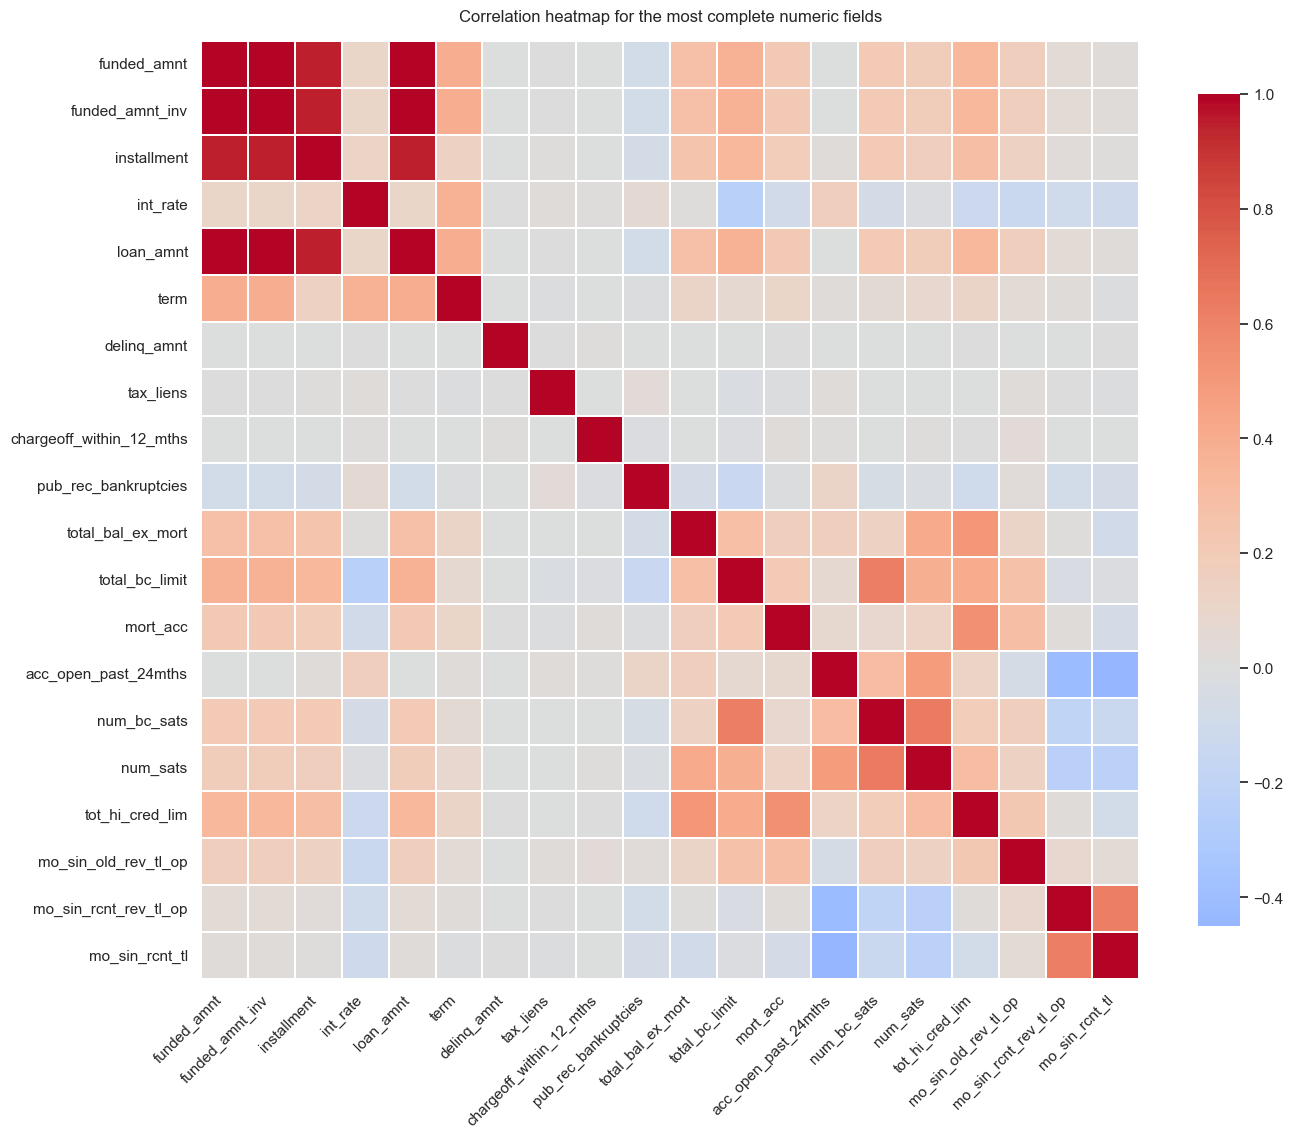

,metric_1,metric_2,correlation,abs_correlation
0,loan_amnt,funded_amnt,0.999763,0.999763
1,funded_amnt,funded_amnt_inv,0.999356,0.999356
2,loan_amnt,funded_amnt_inv,0.999064,0.999064
3,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.983188,0.983188
4,funded_amnt,installment,0.945316,0.945316
5,loan_amnt,installment,0.944996,0.944996
6,funded_amnt_inv,installment,0.944478,0.944478
7,mths_since_recent_bc_dlq,mths_since_recent_revol_delinq,0.890266,0.890266
8,total_bal_ex_mort,total_il_high_credit_limit,0.886245,0.886245
9,bc_open_to_buy,total_bc_limit,0.849676,0.849676


Wrote correlation workbook to /Users/tendani/Desktop/Loaning/data/numeric_correlations.xlsx


In [72]:
corr_matrix = numeric_pd_sample.corr(numeric_only=True)

corr_heatmap_columns = numeric_missing.loc[numeric_missing['missing_pct'] <= 0.25, 'column'].tolist()
corr_heatmap_columns = corr_heatmap_columns[:20] if corr_heatmap_columns else numeric_columns[:20]
corr_heatmap = corr_matrix.loc[corr_heatmap_columns, corr_heatmap_columns]

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_heatmap,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation heatmap for the most complete numeric fields', pad=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_pairs = (
    corr_matrix
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'metric_1', 'level_1': 'metric_2', 0: 'correlation'})
)

corr_pairs = corr_pairs[corr_pairs['metric_1'] != corr_pairs['metric_2']].copy()
corr_pairs['pair_key'] = corr_pairs.apply(
    lambda row: tuple(sorted((row['metric_1'], row['metric_2']))),
    axis=1
)
corr_pairs = corr_pairs.drop_duplicates('pair_key').drop(columns='pair_key')
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()

display(
    corr_pairs
    .sort_values('abs_correlation', ascending=False)
    .head(60)
    .reset_index(drop=True)
)

corr_export_path = DATA_DIR / 'numeric_correlations.xlsx'
corr_pairs_export = corr_pairs.sort_values('abs_correlation', ascending=False).reset_index(drop=True)

with pd.ExcelWriter(corr_export_path, engine='openpyxl') as writer:
    corr_pairs_export.to_excel(writer, sheet_name='correlation_pairs', index=False)
    corr_matrix.to_excel(writer, sheet_name='correlation_matrix')
    corr_heatmap.to_excel(writer, sheet_name='heatmap_subset')

print(f'Wrote correlation workbook to {corr_export_path}')


,column,missing_pct,mean,std,min,p25,median,p75,p95,max
0,acc_open_past_24mths,2.21,4.522671,3.151786,0.00,2.000,4.00,6.00,10.00,49.00
1,bc_open_to_buy,3.31,11352.848205,16739.047292,0.00,1703.000,5421.00,14018.50,42459.10,357467.00
2,chargeoff_within_12_mths,0.02,0.007924,0.097809,0.00,0.000,0.00,0.00,0.00,4.00
3,delinq_amnt,0.01,12.932919,631.058515,0.00,0.000,0.00,0.00,0.00,65000.00
4,emp_length,6.50,5.935764,3.715272,0.00,2.000,6.00,10.00,10.00,10.00
5,funded_amnt,0.00,15005.805259,9165.001126,500.00,8000.000,12800.00,20000.00,35000.00,40000.00
6,funded_amnt_inv,0.00,14987.954669,9169.665362,0.00,8000.000,12800.00,20000.00,35000.00,40000.00
7,installment,0.00,444.557380,266.411043,16.73,251.335,376.59,590.68,982.02,1715.42
8,int_rate,0.00,13.095239,4.822783,5.31,9.490,12.62,15.99,22.15,30.99
9,loan_amnt,0.00,15011.177249,9166.160622,500.00,8000.000,12800.00,20000.00,35000.00,40000.00


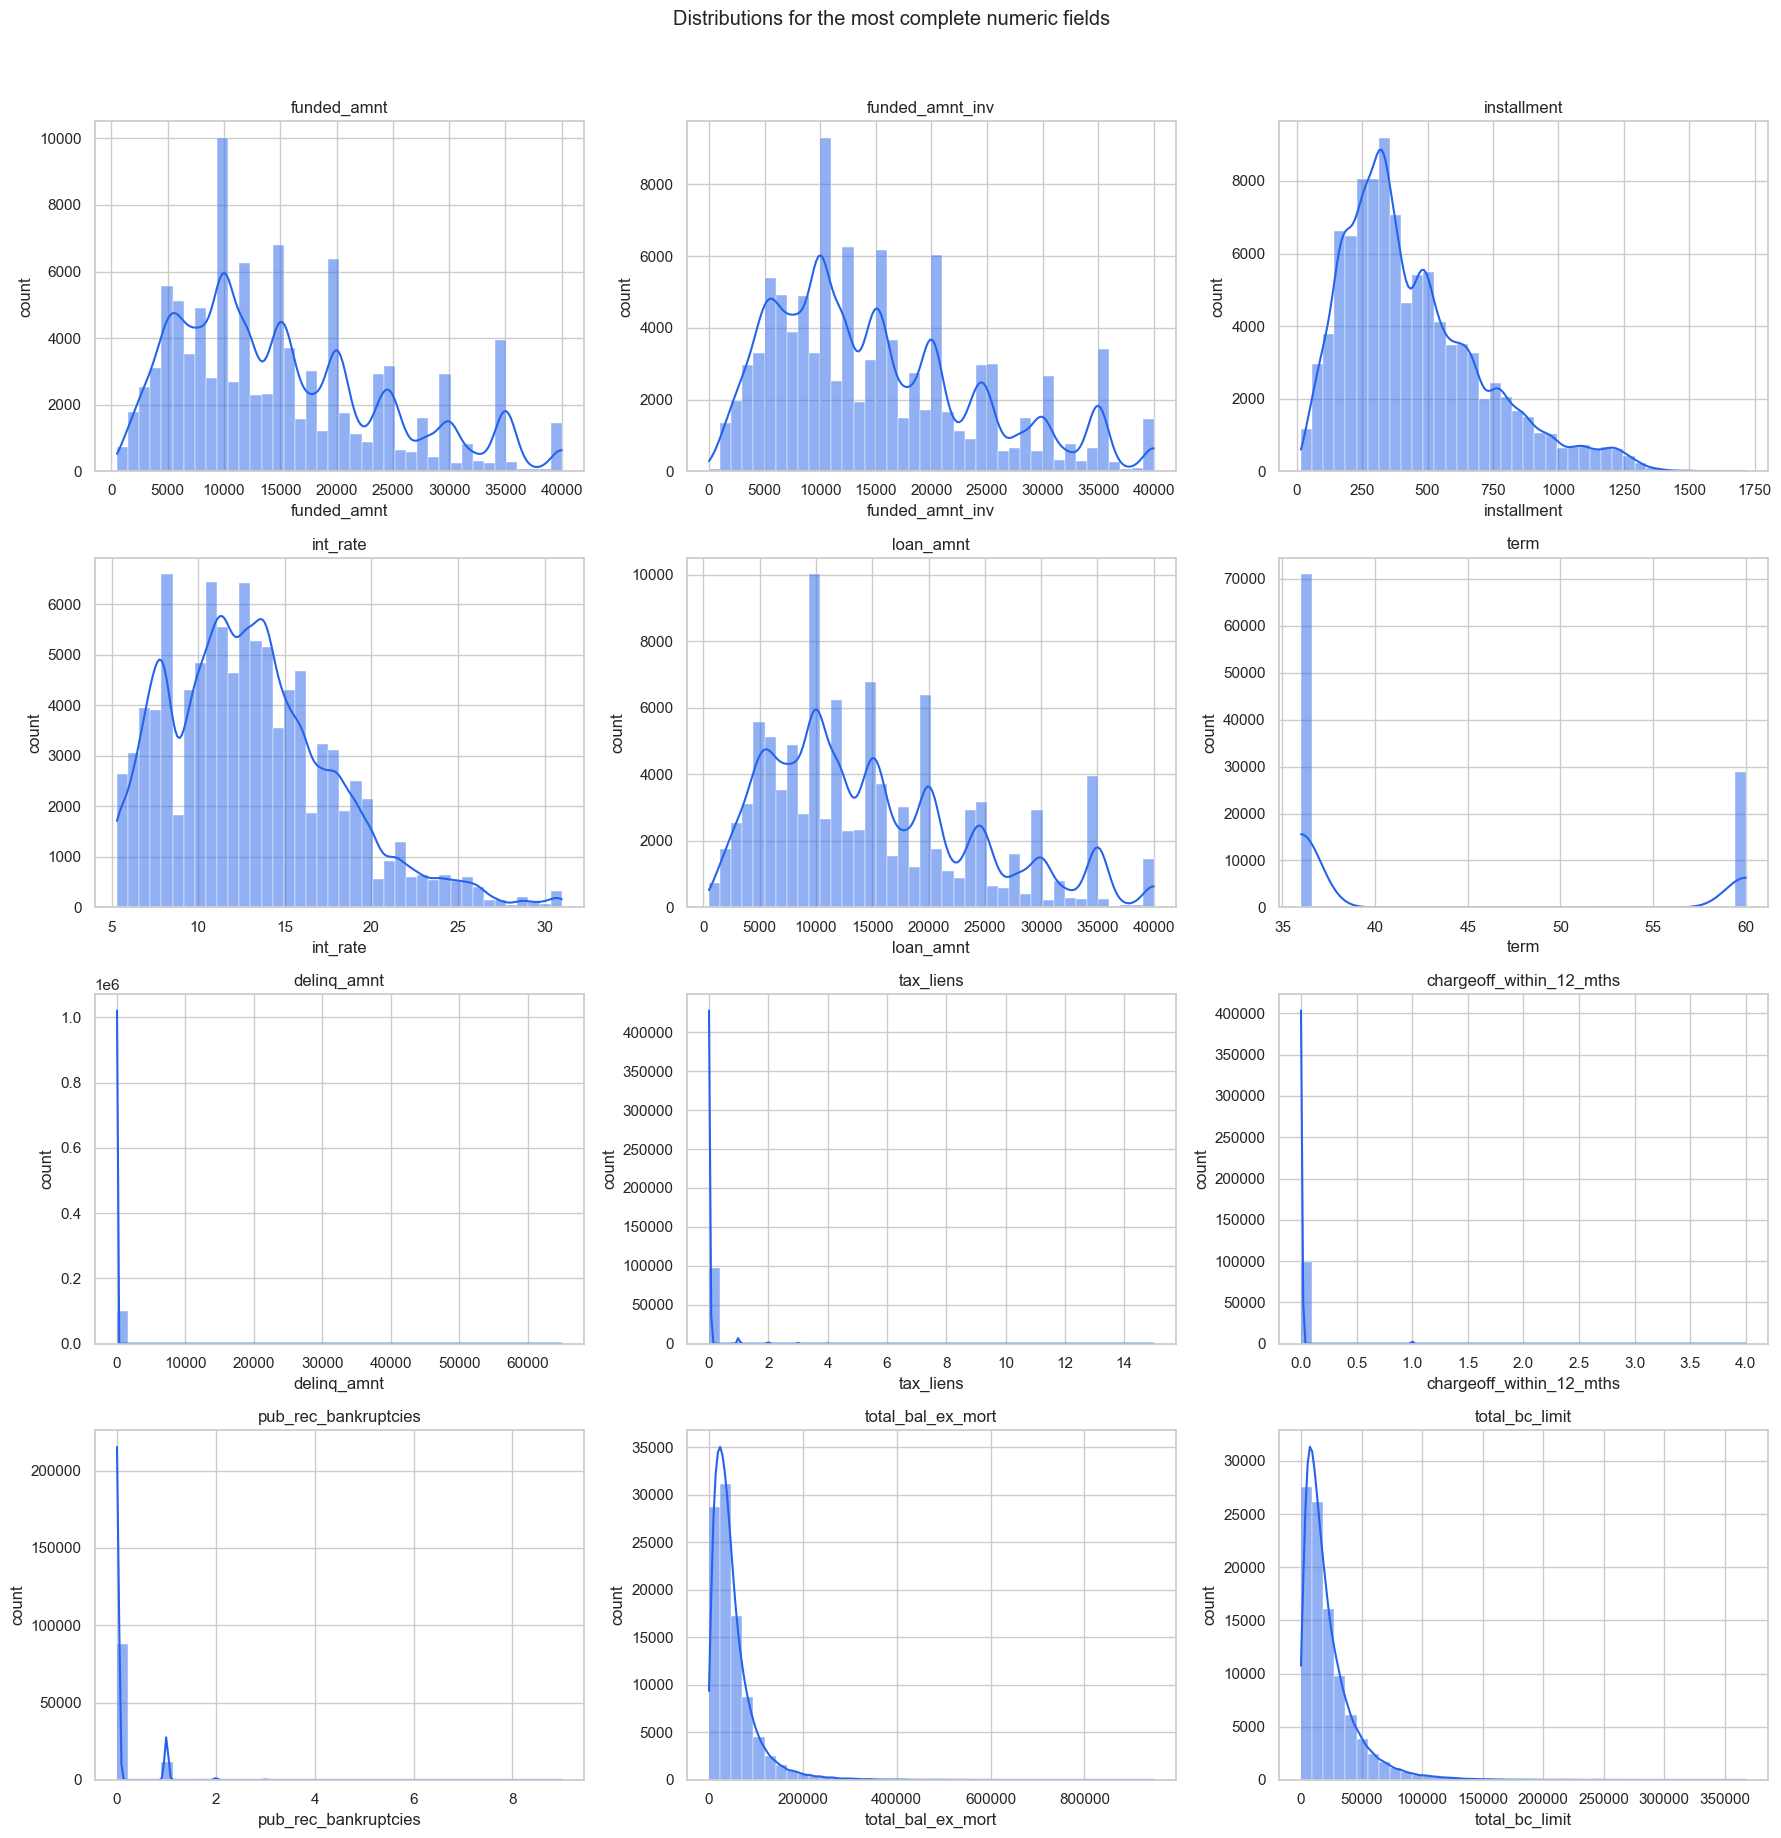

In [73]:
distribution_profile = pd.DataFrame({
    'column': numeric_pd_sample.columns,
    'mean': numeric_pd_sample.mean().values,
    'std': numeric_pd_sample.std().values,
    'min': numeric_pd_sample.min().values,
    'p25': numeric_pd_sample.quantile(0.25).values,
    'median': numeric_pd_sample.quantile(0.50).values,
    'p75': numeric_pd_sample.quantile(0.75).values,
    'p95': numeric_pd_sample.quantile(0.95).values,
    'max': numeric_pd_sample.max().values,
})

distribution_profile = distribution_profile.merge(numeric_missing, on='column', how='left')
distribution_profile['missing_pct'] = (distribution_profile['missing_pct'] * 100).round(2)
distribution_profile = distribution_profile[
    ['column', 'missing_pct', 'mean', 'std', 'min', 'p25', 'median', 'p75', 'p95', 'max']
].sort_values('column').reset_index(drop=True)

display(distribution_profile)

distribution_plot_columns = numeric_missing.loc[numeric_missing['missing_pct'] <= 0.10, 'column'].tolist()
distribution_plot_columns = distribution_plot_columns[:12] if distribution_plot_columns else numeric_columns[:12]

ncols = 3
nrows = math.ceil(len(distribution_plot_columns) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, column in zip(axes, distribution_plot_columns):
    series = numeric_pd_sample[column].dropna()
    sns.histplot(series, bins=40, kde=True, ax=ax, color='#2563eb', edgecolor='white', linewidth=0.3)
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel('count')

for ax in axes[len(distribution_plot_columns):]:
    ax.axis('off')

fig.suptitle('Distributions for the most complete numeric fields', y=1.02)
plt.tight_layout()
plt.show()


## Step 6: Define A Clean Modeling Target

The covariance and correlation work shows which numeric fields move together. The next modeling question is different: which fields separate resolved good loans from resolved bad loans? Start by converting `loan_status` into a binary `default_flag` and excluding unresolved outcomes such as `Current`, `Late`, and `In Grace Period`.


In [74]:
good_statuses = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid',
]

bad_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
]

unresolved_statuses = [
    'Current',
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)',
]

# Prefer the cleaned in-memory frame when the notebook has been run from the top.
# Fall back to the Parquet frame if this section is being run independently.
df_model_source = df_step3_pruned if 'df_step3_pruned' in globals() else df_parquet

df_targeted = (
    df_model_source
    .withColumn(
        'default_flag',
        F.when(F.col('loan_status').isin(bad_statuses), F.lit(1.0))
         .when(F.col('loan_status').isin(good_statuses), F.lit(0.0))
         .otherwise(F.lit(None).cast('double'))
    )
    .filter(F.col('default_flag').isNotNull())
    .cache()
)

target_status_summary = (
    df_targeted
    .groupBy('loan_status', 'default_flag')
    .count()
    .orderBy('default_flag', 'loan_status')
)

target_status_summary.show(50, truncate=False)

resolved_row_count = df_targeted.count()
default_rate = df_targeted.agg(F.mean('default_flag').alias('default_rate')).first()['default_rate']

print(f'Resolved modeling rows: {resolved_row_count:,}')
print(f'Default rate among resolved loans: {default_rate:.2%}')
print(f'Excluded unresolved statuses: {unresolved_statuses}')


26/06/10 23:04:30 WARN CacheManager: Asked to cache already cached data.
                                                                                

+---------------------------------------------------+------------+-------+
|loan_status                                        |default_flag|count  |
+---------------------------------------------------+------------+-------+
|Does not meet the credit policy. Status:Fully Paid |0.0         |1988   |
|Fully Paid                                         |0.0         |1041952|
|Charged Off                                        |1.0         |261654 |
|Default                                            |1.0         |31     |
|Does not meet the credit policy. Status:Charged Off|1.0         |761    |
+---------------------------------------------------+------------+-------+

Resolved modeling rows: 1,306,386
Default rate among resolved loans: 20.09%
Excluded unresolved statuses: ['Current', 'In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)']


## Step 7: Exclude Leakage And Build Candidate Features

For an application-time underwriting model, do not train on columns that are only known after the loan is issued, such as payment history, recoveries, settlement fields, hardship outcomes, and last-payment dates. Also keep `grade`, `sub_grade`, `int_rate`, and `installment` out of the first independent baseline because they already encode Lending Club's own risk/pricing decision.


In [75]:
df_features = df_targeted
feature_dtypes = dict(df_features.dtypes)

# Make this section robust whether it receives the cleaned frame or the raw Parquet frame.
if feature_dtypes.get('term') == 'string':
    term_digits = F.regexp_extract(F.col('term'), r'(\d+)', 1)
    df_features = df_features.withColumn(
        'term',
        F.when(F.col('term').isNull(), None)
         .when(term_digits == '', None)
         .otherwise(term_digits.cast('int'))
    )

if feature_dtypes.get('emp_length') == 'string':
    emp_length_digits = F.regexp_extract(F.col('emp_length'), r'(\d+)', 1)
    df_features = df_features.withColumn(
        'emp_length',
        F.when(F.col('emp_length').isNull(), None)
         .when(F.col('emp_length') == '< 1 year', F.lit(0))
         .when(F.col('emp_length') == '10+ years', F.lit(10))
         .when(emp_length_digits == '', None)
         .otherwise(emp_length_digits.cast('int'))
    )

for c in ['issue_d', 'earliest_cr_line']:
    if c in df_features.columns and dict(df_features.dtypes).get(c) == 'string':
        df_features = df_features.withColumn(
            c,
            F.when(F.col(c).rlike(r'^[A-Za-z]{3}-\d{4}$'), F.to_date(F.col(c), 'MMM-yyyy'))
             .otherwise(None)
        )

if {'issue_d', 'earliest_cr_line'}.issubset(set(df_features.columns)):
    df_features = df_features.withColumn(
        'credit_history_months',
        F.when(
            F.col('issue_d').isNotNull() & F.col('earliest_cr_line').isNotNull(),
            F.months_between(F.col('issue_d'), F.col('earliest_cr_line'))
        )
    )

missing_flag_source_columns = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
]

for c in missing_flag_source_columns:
    if c in df_features.columns:
        df_features = df_features.withColumn(f'{c}_missing', F.col(c).isNull().cast('double'))

outcome_or_servicing_columns = {
    'loan_status',
    'default_flag',
    'funded_amnt',
    'funded_amnt_inv',
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'last_credit_pull_d',
    'last_fico_range_high',
    'last_fico_range_low',
    'pymnt_plan',
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term',
}

outcome_or_servicing_prefixes = (
    'hardship_',
    'settlement_',
)

pricing_or_lender_decision_columns = {
    'grade',
    'sub_grade',
    'int_rate',
    'installment',
}

identifier_or_raw_text_columns = {
    'id',
    'member_id',
    'url',
    'desc',
    'title',
    'title_normalized',
}

raw_date_or_audit_columns = {
    'issue_d',
    'earliest_cr_line',
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d',
}

excluded_columns = (
    outcome_or_servicing_columns
    | pricing_or_lender_decision_columns
    | identifier_or_raw_text_columns
    | raw_date_or_audit_columns
    | {c for c in df_features.columns if c.endswith('_invalid_raw')}
    | {c for c in df_features.columns if c.startswith(outcome_or_servicing_prefixes)}
)

numeric_feature_candidates = [
    'loan_amnt',
    'term',
    'emp_length',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'collections_12_mths_ex_med',
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'mths_since_last_delinq_missing',
    'mths_since_last_record_missing',
    'mths_since_last_major_derog_missing',
    'acc_open_past_24mths',
    'mort_acc',
    'pub_rec_bankruptcies',
    'fico_range_low',
    'fico_range_high',
    'credit_history_months',
    'tot_coll_amt',
    'tot_cur_bal',
    'total_rev_hi_lim',
    'bc_util',
    'percent_bc_gt_75',
    'num_actv_bc_tl',
    'num_rev_tl_bal_gt_0',
    'num_tl_90g_dpd_24m',
    'pct_tl_nvr_dlq',
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'open_il_12m',
    'open_il_24m',
    'open_rv_12m',
    'open_rv_24m',
    'inq_fi',
    'all_util',
]

categorical_feature_candidates = [
    'home_ownership',
    'verification_status',
    'purpose',
    'application_type',
    'initial_list_status',
    'disbursement_method',
    'title_grouped',
]


spark_numeric_types = {
    'byte',
    'short',
    'int',
    'bigint',
    'long',
    'float',
    'double',
}

for c in numeric_feature_candidates:
    if c in df_features.columns:
        current_type = dict(df_features.dtypes).get(c, '')
        is_decimal = current_type.startswith('decimal')
        if current_type not in spark_numeric_types and not is_decimal:
            escaped_column = c.replace('`', '``')
            df_features = df_features.withColumn(
                c,
                F.expr(
                    f"try_cast(regexp_replace(cast(`{escaped_column}` as string), '[%$,]', '') as double)"
                )
            )

numeric_feature_cols = [
    c for c in numeric_feature_candidates
    if c in df_features.columns and c not in excluded_columns
]

categorical_feature_cols = [
    c for c in categorical_feature_candidates
    if c in df_features.columns and c not in excluded_columns
]

feature_inventory = pd.DataFrame(
    [{'column': c, 'role': 'numeric'} for c in numeric_feature_cols]
    + [{'column': c, 'role': 'categorical'} for c in categorical_feature_cols]
)

display(feature_inventory)

print(f'Numeric baseline candidates: {len(numeric_feature_cols)}')
print(f'Categorical baseline candidates: {len(categorical_feature_cols)}')
print(f'Excluded leakage/pricing/raw columns present: {len([c for c in excluded_columns if c in df_features.columns])}')


,column,role
0,loan_amnt,numeric
1,term,numeric
2,emp_length,numeric
3,annual_inc,numeric
4,dti,numeric
5,delinq_2yrs,numeric
6,inq_last_6mths,numeric
7,open_acc,numeric
8,pub_rec,numeric
9,revol_bal,numeric


Numeric baseline candidates: 41
Categorical baseline candidates: 7
Excluded leakage/pricing/raw columns present: 50


## Step 8: Rank Numeric Features Against The Target

This is a better next screen than the covariance matrix for modeling. It estimates each numeric feature's simple correlation with `default_flag`, while still treating the result as a first-pass signal rather than final feature importance.


26/06/10 23:04:48 WARN CacheManager: Asked to cache already cached data.
                                                                                

,column,correlation_with_default,abs_correlation,sample_missing_pct
0,term,0.178829,0.178829,0.000000
1,acc_open_past_24mths,0.098476,0.098476,0.039201
2,all_util,0.092176,0.092176,0.618004
3,dti,0.086359,0.086359,0.000500
4,open_rv_24m,0.078482,0.078482,0.617944
5,mort_acc,-0.077537,0.077537,0.039201
6,tot_cur_bal,-0.073499,0.073499,0.054239
7,open_rv_12m,0.071078,0.071078,0.617954
8,inq_last_6mths,0.067593,0.067593,0.000160
9,num_rev_tl_bal_gt_0,0.067524,0.067524,0.054289


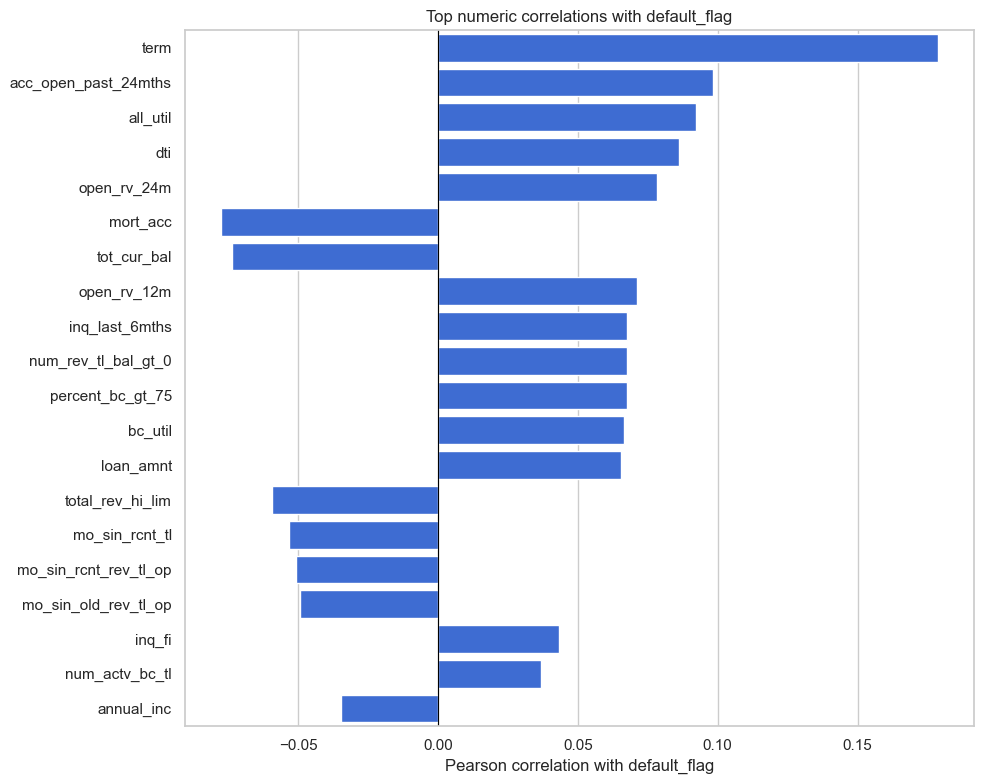

In [76]:
df_features = df_features.cache()
feature_row_count = df_features.count()

feature_sample_target = 100_000
feature_sample_fraction = min(1.0, feature_sample_target / feature_row_count)

feature_corr_pd = (
    df_features
    .select(['default_flag'] + numeric_feature_cols)
    .sample(False, feature_sample_fraction, seed=42)
    .limit(feature_sample_target)
    .toPandas()
    .apply(pd.to_numeric, errors='coerce')
)

target_correlations = (
    feature_corr_pd
    .corr(numeric_only=True)['default_flag']
    .drop(labels=['default_flag'])
    .reset_index()
    .rename(columns={'index': 'column', 'default_flag': 'correlation_with_default'})
)

target_correlations['abs_correlation'] = target_correlations['correlation_with_default'].abs()

feature_missing_pd = (
    feature_corr_pd[numeric_feature_cols]
    .isna()
    .mean()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'sample_missing_pct'})
)

target_feature_screen = (
    target_correlations
    .merge(feature_missing_pd, on='column', how='left')
    .sort_values('abs_correlation', ascending=False)
    .reset_index(drop=True)
)

display(target_feature_screen.head(40))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=target_feature_screen.head(20),
    y='column',
    x='correlation_with_default',
    color='#2563eb'
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top numeric correlations with default_flag')
plt.xlabel('Pearson correlation with default_flag')
plt.ylabel('')
plt.tight_layout()
plt.show()


## Step 9: Train A First Baseline Model

Use this model as a sanity check, not as the final underwriting model. The point is to test whether the cleaned, leakage-controlled feature set can predict resolved defaults better than chance and to produce an initial model-based feature ranking.


In [77]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import Imputer, OneHotEncoder, StringIndexer, VectorAssembler

model_sample_target = 250_000
model_sample_fraction = min(1.0, model_sample_target / feature_row_count)

model_input = (
    df_features
    .select(['default_flag'] + numeric_feature_cols + categorical_feature_cols)
    .sample(False, model_sample_fraction, seed=7)
    .limit(model_sample_target)
    .cache()
)

model_input_count = model_input.count()
print(f'Modeling sample rows: {model_input_count:,}')

numeric_non_null_counts = model_input.select([
    F.count(F.col(c)).alias(c)
    for c in numeric_feature_cols
]).first().asDict() if numeric_feature_cols else {}

categorical_non_null_counts = model_input.select([
    F.count(F.col(c)).alias(c)
    for c in categorical_feature_cols
]).first().asDict() if categorical_feature_cols else {}

model_numeric_cols = [c for c in numeric_feature_cols if numeric_non_null_counts.get(c, 0) > 0]
model_categorical_cols = [c for c in categorical_feature_cols if categorical_non_null_counts.get(c, 0) > 0]

numeric_imputed_cols = [f'{c}_imputed' for c in model_numeric_cols]
categorical_indexed_cols = [f'{c}_idx' for c in model_categorical_cols]
categorical_encoded_cols = [f'{c}_encoded' for c in model_categorical_cols]

stages = []

if model_numeric_cols:
    stages.append(Imputer(
        inputCols=model_numeric_cols,
        outputCols=numeric_imputed_cols,
        strategy='median'
    ))

if model_categorical_cols:
    stages.extend([
        StringIndexer(
            inputCols=model_categorical_cols,
            outputCols=categorical_indexed_cols,
            handleInvalid='keep'
        ),
        OneHotEncoder(
            inputCols=categorical_indexed_cols,
            outputCols=categorical_encoded_cols
        )
    ])

assembler_inputs = numeric_imputed_cols + categorical_encoded_cols

stages.extend([
    VectorAssembler(
        inputCols=assembler_inputs,
        outputCol='features',
        handleInvalid='keep'
    ),
    LogisticRegression(
        featuresCol='features',
        labelCol='default_flag',
        maxIter=50,
        regParam=0.01,
        elasticNetParam=0.0
    )
])

train_df, test_df = model_input.randomSplit([0.8, 0.2], seed=42)

baseline_pipeline = Pipeline(stages=stages)
baseline_model = baseline_pipeline.fit(train_df)
baseline_predictions = baseline_model.transform(test_df).cache()

roc_auc = BinaryClassificationEvaluator(
    labelCol='default_flag',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
).evaluate(baseline_predictions)

pr_auc = BinaryClassificationEvaluator(
    labelCol='default_flag',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderPR'
).evaluate(baseline_predictions)

print(f'Baseline ROC AUC: {roc_auc:.4f}')
print(f'Baseline PR AUC: {pr_auc:.4f}')

prediction_summary = (
    baseline_predictions
    .groupBy('default_flag', 'prediction')
    .count()
    .orderBy('default_flag', 'prediction')
    .toPandas()
)

display(prediction_summary)


26/06/10 23:04:51 WARN CacheManager: Asked to cache already cached data.


Modeling sample rows: 249,955


26/06/10 23:05:00 WARN DAGScheduler: Broadcasting large task binary with size 1157.0 KiB
26/06/10 23:05:01 WARN DAGScheduler: Broadcasting large task binary with size 1157.0 KiB


Baseline ROC AUC: 0.6987
Baseline PR AUC: 0.3668


26/06/10 23:05:01 WARN DAGScheduler: Broadcasting large task binary with size 1170.4 KiB


,default_flag,prediction,count
0,0.0,0.0,39691
1,0.0,1.0,466
2,1.0,0.0,9472
3,1.0,1.0,548


In [78]:
lr_model = baseline_model.stages[-1]
feature_metadata = baseline_predictions.schema['features'].metadata.get('ml_attr', {}).get('attrs', {})

feature_attrs = []
for attrs in feature_metadata.values():
    feature_attrs.extend(attrs)

feature_names = [
    attr['name']
    for attr in sorted(feature_attrs, key=lambda attr: attr['idx'])
]

coef_values = lr_model.coefficients.toArray()

if len(feature_names) == len(coef_values):
    coefficient_ranking = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coef_values,
    })
else:
    coefficient_ranking = pd.DataFrame({
        'feature': [f'feature_{i}' for i in range(len(coef_values))],
        'coefficient': coef_values,
    })

coefficient_ranking['abs_coefficient'] = coefficient_ranking['coefficient'].abs()
coefficient_ranking = coefficient_ranking.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

display(coefficient_ranking.head(40))

print('Positive coefficients push predicted default risk up; negative coefficients push it down.')
print('Because this is logistic regression on mixed scales, treat this as a baseline diagnostic, not final feature importance.')


,feature,coefficient,abs_coefficient
0,purpose_encoded_and always kept the best inter...,13.657364,13.657364
1,initial_list_status_encoded_59.1,13.657364,13.657364
2,title_grouped_encoded_fixed loan,5.734597,5.734597
3,title_grouped_encoded_giving the 99% a chance ...,5.475725,5.475725
4,title_grouped_encoded_second loan with lending...,5.365299,5.365299
5,title_grouped_encoded_consloan,5.336378,5.336378
6,title_grouped_encoded_timeshare payoff,5.329275,5.329275
7,title_grouped_encoded_kill the card,5.320887,5.320887
8,purpose_encoded_and transparent relationship b...,-5.304045,5.304045
9,title_grouped_encoded_lc funds,5.294706,5.294706


Positive coefficients push predicted default risk up; negative coefficients push it down.
Because this is logistic regression on mixed scales, treat this as a baseline diagnostic, not final feature importance.


## Step 10: Statistical Feature Relationship Analysis

Correlation is only one view. This section adds credit-risk style feature screening with numeric effect sizes, Information Value, categorical risk separation, and simple two-feature risk cells. These tests are still exploratory, but they are a stronger bridge between EDA and model feature selection.


In [79]:
import itertools
import numpy as np

if 'feature_row_count' not in globals():
    feature_row_count = df_features.count()

stats_sample_target = 150_000
stats_sample_fraction = min(1.0, stats_sample_target / feature_row_count)
stat_feature_cols = numeric_feature_cols + categorical_feature_cols

analysis_pd = (
    df_features
    .select(['default_flag'] + stat_feature_cols)
    .sample(False, stats_sample_fraction, seed=101)
    .limit(stats_sample_target)
    .toPandas()
)

analysis_pd['default_flag'] = pd.to_numeric(analysis_pd['default_flag'], errors='coerce').astype('int')

for c in numeric_feature_cols:
    analysis_pd[c] = pd.to_numeric(analysis_pd[c], errors='coerce')

for c in categorical_feature_cols:
    analysis_pd[c] = analysis_pd[c].astype('string').fillna('__missing__')

overall_default_rate = analysis_pd['default_flag'].mean()

print(f'Statistical analysis sample rows: {len(analysis_pd):,}')
print(f'Sample default rate: {overall_default_rate:.2%}')
print(f'Numeric fields analyzed: {len(numeric_feature_cols)}')
print(f'Categorical fields analyzed: {len(categorical_feature_cols)}')


Statistical analysis sample rows: 150,000
Sample default rate: 20.00%
Numeric fields analyzed: 41
Categorical fields analyzed: 7


### Numeric Features

For numeric features, compare defaulted and non-defaulted loans using mean/median separation, standardized mean difference, KS statistic, point-biserial correlation, and Information Value. In credit-risk work, IV is especially useful as a screening metric, but it should not be treated as final model importance.


,column,non_default_mean,default_mean,mean_difference,non_default_median,default_median,standardized_mean_diff,ks_statistic,target_correlation,information_value,non_default_missing_pct,default_missing_pct,abs_standardized_mean_diff,abs_target_correlation
0,dti,17.773222,20.126924,2.353701,17.12,19.77,0.252745,0.113570,0.099461,0.075836,0.000342,0.000667,0.252745,0.099461
1,acc_open_past_24mths,4.531257,5.326183,0.794926,4.00,5.00,0.243511,0.102158,0.100502,0.062048,0.040451,0.030429,0.243511,0.100502
2,all_util,57.048275,61.761110,4.712835,58.00,63.00,0.229283,0.101775,0.094278,0.056387,0.630404,0.568658,0.229283,0.094278
3,tot_cur_bal,146405.221662,118068.487897,-28336.733765,87212.00,60838.00,-0.191873,0.090708,-0.072782,0.041895,0.056227,0.043561,0.191873,0.072782
4,mort_acc,1.749737,1.365465,-0.384273,1.00,1.00,-0.198062,0.091656,-0.076864,0.038968,0.040443,0.030496,0.198062,0.076864
5,open_rv_24m,2.903143,3.428568,0.525425,2.00,3.00,0.188292,0.080749,0.081184,0.037659,0.630371,0.568624,0.188292,0.081184
6,num_rev_tl_bal_gt_0,5.479836,6.075593,0.595758,5.00,5.00,0.180280,0.076301,0.074152,0.034002,0.056260,0.043694,0.180280,0.074152
7,loan_amnt,14096.468632,15523.060259,1426.591626,12000.00,14162.50,0.163558,0.081919,0.065666,0.033943,0.000000,0.000000,0.163558,0.065666
8,bc_util,59.132230,63.948247,4.816018,62.20,68.30,0.172267,0.071748,0.068333,0.031355,0.051360,0.041594,0.172267,0.068333
9,percent_bc_gt_75,44.081445,50.299975,6.218530,40.00,50.00,0.173351,0.078716,0.069262,0.031314,0.051143,0.041128,0.173351,0.069262


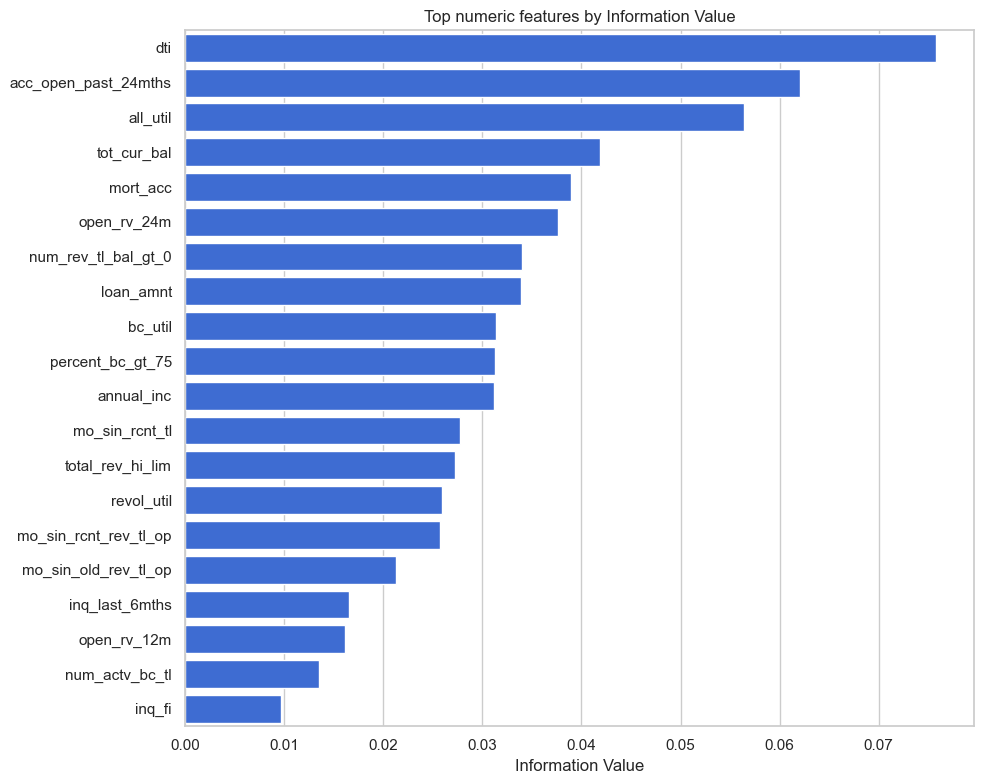

In [80]:
def ks_statistic(non_default_values, default_values):
    non_default_values = np.sort(pd.Series(non_default_values).dropna().to_numpy())
    default_values = np.sort(pd.Series(default_values).dropna().to_numpy())

    if len(non_default_values) == 0 or len(default_values) == 0:
        return np.nan

    values = np.sort(np.unique(np.concatenate([non_default_values, default_values])))
    non_default_cdf = np.searchsorted(non_default_values, values, side='right') / len(non_default_values)
    default_cdf = np.searchsorted(default_values, values, side='right') / len(default_values)
    return float(np.max(np.abs(default_cdf - non_default_cdf)))


def information_value_from_grouped(grouped, good_col='good', bad_col='bad'):
    grouped = grouped.copy()
    grouped = grouped[(grouped[good_col] + grouped[bad_col]) > 0]

    if grouped.empty:
        return np.nan

    smoothing = 0.5
    bucket_count = len(grouped)
    total_good = grouped[good_col].sum()
    total_bad = grouped[bad_col].sum()

    if total_good == 0 or total_bad == 0:
        return np.nan

    dist_good = (grouped[good_col] + smoothing) / (total_good + smoothing * bucket_count)
    dist_bad = (grouped[bad_col] + smoothing) / (total_bad + smoothing * bucket_count)
    woe = np.log(dist_bad / dist_good)
    iv = ((dist_bad - dist_good) * woe).sum()
    return float(iv)


def numeric_information_value(frame, feature, target='default_flag', bins=10):
    data = frame[[feature, target]].dropna().copy()

    if data[feature].nunique(dropna=True) < 2:
        return np.nan

    try:
        data['_bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')
    except ValueError:
        data['_bin'] = pd.cut(data[feature], bins=bins, duplicates='drop')

    grouped = data.groupby('_bin', observed=True)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'sum': 'bad'})
    grouped['good'] = grouped['count'] - grouped['bad']
    return information_value_from_grouped(grouped)


numeric_rows = []
for c in numeric_feature_cols:
    data = analysis_pd[[c, 'default_flag']].dropna()
    non_default_values = data.loc[data['default_flag'] == 0, c]
    default_values = data.loc[data['default_flag'] == 1, c]

    if len(non_default_values) == 0 or len(default_values) == 0:
        continue

    non_default_std = non_default_values.std(ddof=1)
    default_std = default_values.std(ddof=1)
    pooled_std = np.sqrt((non_default_std ** 2 + default_std ** 2) / 2)
    standardized_mean_diff = (
        (default_values.mean() - non_default_values.mean()) / pooled_std
        if pooled_std and not np.isnan(pooled_std) else np.nan
    )

    correlation_data = analysis_pd[[c, 'default_flag']].dropna()
    target_correlation = correlation_data[c].corr(correlation_data['default_flag'])

    numeric_rows.append({
        'column': c,
        'non_default_mean': non_default_values.mean(),
        'default_mean': default_values.mean(),
        'mean_difference': default_values.mean() - non_default_values.mean(),
        'non_default_median': non_default_values.median(),
        'default_median': default_values.median(),
        'standardized_mean_diff': standardized_mean_diff,
        'ks_statistic': ks_statistic(non_default_values, default_values),
        'target_correlation': target_correlation,
        'information_value': numeric_information_value(analysis_pd, c),
        'non_default_missing_pct': analysis_pd.loc[analysis_pd['default_flag'] == 0, c].isna().mean(),
        'default_missing_pct': analysis_pd.loc[analysis_pd['default_flag'] == 1, c].isna().mean(),
    })

numeric_relationships = pd.DataFrame(numeric_rows)
numeric_relationships['abs_standardized_mean_diff'] = numeric_relationships['standardized_mean_diff'].abs()
numeric_relationships['abs_target_correlation'] = numeric_relationships['target_correlation'].abs()
numeric_relationships = numeric_relationships.sort_values(
    ['information_value', 'ks_statistic', 'abs_standardized_mean_diff'],
    ascending=False
).reset_index(drop=True)

display(numeric_relationships.head(40))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=numeric_relationships.head(20),
    y='column',
    x='information_value',
    color='#2563eb'
)
plt.title('Top numeric features by Information Value')
plt.xlabel('Information Value')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Categorical Features

For categorical features, compare category-level default rates, lift versus the sample default rate, Information Value, and Cramer's V. This helps identify categories that separate risk even when correlation is not meaningful.


In [81]:
def cramers_v_from_table(table):
    observed = table.to_numpy(dtype=float)
    total = observed.sum()

    if total == 0 or min(observed.shape) < 2:
        return np.nan

    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / total

    with np.errstate(divide='ignore', invalid='ignore'):
        chi_square = np.nansum((observed - expected) ** 2 / expected)

    min_dimension = min(observed.shape[0] - 1, observed.shape[1] - 1)
    return float(np.sqrt((chi_square / total) / min_dimension)) if min_dimension > 0 else np.nan


def prepare_category_series(series, min_count=100, max_categories=30):
    series = series.astype('string').fillna('__missing__')
    counts = series.value_counts(dropna=False)
    keep = counts[counts >= min_count].head(max_categories).index
    return series.where(series.isin(keep), '__rare_or_small__')


def categorical_information_value(frame, feature, target='default_flag'):
    data = frame[[feature, target]].copy()
    grouped = data.groupby(feature, dropna=False)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'sum': 'bad'})
    grouped['good'] = grouped['count'] - grouped['bad']
    return information_value_from_grouped(grouped)


categorical_rows = []
category_level_frames = []

for c in categorical_feature_cols:
    profiled_col = f'{c}_profiled'
    profiled = prepare_category_series(analysis_pd[c])
    profiled_frame = pd.DataFrame({
        profiled_col: profiled,
        'default_flag': analysis_pd['default_flag'],
    })

    contingency = pd.crosstab(profiled_frame[profiled_col], profiled_frame['default_flag'])
    if 0 not in contingency.columns:
        contingency[0] = 0
    if 1 not in contingency.columns:
        contingency[1] = 0
    contingency = contingency[[0, 1]]

    category_summary = (
        profiled_frame
        .groupby(profiled_col, dropna=False)['default_flag']
        .agg(['count', 'mean'])
        .rename(columns={'mean': 'default_rate'})
        .reset_index()
        .rename(columns={profiled_col: 'category'})
    )
    category_summary['column'] = c
    category_summary['default_lift'] = category_summary['default_rate'] / overall_default_rate
    category_level_frames.append(category_summary)

    categorical_rows.append({
        'column': c,
        'profiled_categories': profiled.nunique(dropna=False),
        'information_value': categorical_information_value(profiled_frame, profiled_col),
        'cramers_v': cramers_v_from_table(contingency),
        'max_category_default_rate': category_summary['default_rate'].max(),
        'min_category_default_rate': category_summary['default_rate'].min(),
        'default_rate_range': category_summary['default_rate'].max() - category_summary['default_rate'].min(),
    })

categorical_relationships = (
    pd.DataFrame(categorical_rows)
    .sort_values(['information_value', 'cramers_v'], ascending=False)
    .reset_index(drop=True)
)

category_level_summary = (
    pd.concat(category_level_frames, ignore_index=True)
    .sort_values(['default_lift', 'count'], ascending=[False, False])
    .reset_index(drop=True)
)

display(categorical_relationships)
display(category_level_summary.head(50))


,column,profiled_categories,information_value,cramers_v,max_category_default_rate,min_category_default_rate,default_rate_range
0,verification_status,3,0.060106,0.095447,0.240568,0.145266,0.095302
1,home_ownership,4,0.033784,0.073694,0.278689,0.171798,0.106891
2,title_grouped,20,0.027158,0.066102,0.310458,0.113208,0.197250
3,purpose,14,0.021324,0.058347,0.393939,0.106122,0.287817
4,application_type,3,0.001836,0.017815,0.304348,0.199074,0.105274
5,initial_list_status,3,0.000680,0.010405,0.304348,0.195421,0.108927
6,disbursement_method,3,0.000076,0.003423,0.304348,0.199980,0.104368


,category,count,default_rate,column,default_lift
0,__rare_or_small__,66,0.393939,purpose,1.969434
1,renewable_energy,109,0.311927,purpose,1.559425
2,business,1530,0.310458,title_grouped,1.552081
3,__rare_or_small__,23,0.304348,application_type,1.521536
4,__rare_or_small__,23,0.304348,initial_list_status,1.521536
5,__rare_or_small__,23,0.304348,disbursement_method,1.521536
6,small_business,1689,0.302546,purpose,1.512528
7,__missing__,1817,0.290589,title_grouped,1.452751
8,__rare_or_small__,61,0.278689,home_ownership,1.393257
9,bill_payoff,380,0.252632,title_grouped,1.262989


### Two-Feature Risk Cells

Many underwriting patterns are combinations rather than one-column effects. This section bins the strongest numeric features, combines them with strong categorical features, and looks for high- and low-risk two-feature cells with enough observations to be credible.


In [82]:
def make_quantile_bin(series, bins=4):
    numeric = pd.to_numeric(series, errors='coerce')

    if numeric.nunique(dropna=True) < 2:
        return pd.Series('__missing__', index=series.index, dtype='string')

    try:
        binned = pd.qcut(numeric, q=bins, duplicates='drop')
    except ValueError:
        binned = pd.cut(numeric, bins=bins, duplicates='drop')

    return binned.astype('string').fillna('__missing__')


candidate_numeric_for_interactions = (
    numeric_relationships
    .loc[~numeric_relationships['column'].str.endswith('_missing')]
    .head(8)['column']
    .tolist()
)

candidate_categorical_for_interactions = categorical_relationships.head(4)['column'].tolist()

interaction_pd = pd.DataFrame({'default_flag': analysis_pd['default_flag']})
interaction_feature_cols = []

for c in candidate_numeric_for_interactions:
    binned_col = f'{c}_bin'
    interaction_pd[binned_col] = make_quantile_bin(analysis_pd[c])
    interaction_feature_cols.append(binned_col)

for c in candidate_categorical_for_interactions:
    profiled_col = f'{c}_profiled'
    interaction_pd[profiled_col] = prepare_category_series(analysis_pd[c], min_count=250, max_categories=12)
    interaction_feature_cols.append(profiled_col)

min_cell_count = max(100, int(len(interaction_pd) * 0.002))
interaction_rows = []

for left, right in itertools.combinations(interaction_feature_cols, 2):
    grouped = (
        interaction_pd
        .groupby([left, right], dropna=False)['default_flag']
        .agg(['count', 'mean'])
        .rename(columns={'mean': 'default_rate'})
        .reset_index()
    )
    grouped = grouped[grouped['count'] >= min_cell_count].copy()

    if grouped.empty:
        continue

    grouped['feature_pair'] = f'{left} + {right}'
    grouped['left_feature'] = left
    grouped['right_feature'] = right
    grouped['left_value'] = grouped[left].astype(str)
    grouped['right_value'] = grouped[right].astype(str)
    grouped['default_lift'] = grouped['default_rate'] / overall_default_rate
    grouped['abs_lift_from_1'] = (grouped['default_lift'] - 1).abs()

    interaction_rows.append(grouped[[
        'feature_pair',
        'left_feature',
        'right_feature',
        'left_value',
        'right_value',
        'count',
        'default_rate',
        'default_lift',
        'abs_lift_from_1',
    ]])

if interaction_rows:
    interaction_cells = pd.concat(interaction_rows, ignore_index=True)
    high_risk_cells = interaction_cells.sort_values(
        ['default_lift', 'count'],
        ascending=[False, False]
    ).reset_index(drop=True)
    low_risk_cells = interaction_cells.sort_values(
        ['default_lift', 'count'],
        ascending=[True, False]
    ).reset_index(drop=True)

    display(high_risk_cells.head(40))
    display(low_risk_cells.head(40))
else:
    interaction_cells = pd.DataFrame()
    print('No two-feature cells met the minimum sample threshold.')


,feature_pair,left_feature,right_feature,left_value,right_value,count,default_rate,default_lift,abs_lift_from_1
0,acc_open_past_24mths_bin + title_grouped_profiled,acc_open_past_24mths_bin,title_grouped_profiled,"(6.0, 50.0]",__missing__,474,0.381857,1.909028,0.909028
1,loan_amnt_bin + title_grouped_profiled,loan_amnt_bin,title_grouped_profiled,"(20000.0, 40000.0]",business,416,0.375000,1.874750,0.874750
2,dti_bin + title_grouped_profiled,dti_bin,title_grouped_profiled,"(24.06, 822.0]",__missing__,553,0.372514,1.862320,0.862320
3,loan_amnt_bin + purpose_profiled,loan_amnt_bin,purpose_profiled,"(20000.0, 40000.0]",small_business,458,0.366812,1.833817,0.833817
4,tot_cur_bal_bin + title_grouped_profiled,tot_cur_bal_bin,title_grouped_profiled,"(29341.25, 79854.0]",business,336,0.363095,1.815234,0.815234
5,all_util_bin + open_rv_24m_bin,all_util_bin,open_rv_24m_bin,"(73.0, 184.0]","(4.0, 43.0]",1919,0.360604,1.802782,0.802782
6,tot_cur_bal_bin + purpose_profiled,tot_cur_bal_bin,purpose_profiled,"(29341.25, 79854.0]",small_business,347,0.360231,1.800913,0.800913
7,tot_cur_bal_bin + title_grouped_profiled,tot_cur_bal_bin,title_grouped_profiled,"(29341.25, 79854.0]",__missing__,481,0.355509,1.777310,0.777310
8,dti_bin + open_rv_24m_bin,dti_bin,open_rv_24m_bin,"(24.06, 822.0]","(4.0, 43.0]",3636,0.352035,1.759941,0.759941
9,num_rev_tl_bal_gt_0_bin + title_grouped_profiled,num_rev_tl_bal_gt_0_bin,title_grouped_profiled,"(7.0, 39.0]",__missing__,416,0.350962,1.754574,0.754574


,feature_pair,left_feature,right_feature,left_value,right_value,count,default_rate,default_lift,abs_lift_from_1
0,home_ownership_profiled + purpose_profiled,home_ownership_profiled,purpose_profiled,MORTGAGE,car,710,0.084507,0.422479,0.577521
1,home_ownership_profiled + title_grouped_profiled,home_ownership_profiled,title_grouped_profiled,MORTGAGE,car_financing,672,0.092262,0.461248,0.538752
2,verification_status_profiled + purpose_profiled,verification_status_profiled,purpose_profiled,Not Verified,car,722,0.092798,0.463927,0.536073
3,all_util_bin + mort_acc_bin,all_util_bin,mort_acc_bin,"(-0.001, 44.0]","(3.0, 51.0]",2101,0.096621,0.483039,0.516961
4,dti_bin + purpose_profiled,dti_bin,purpose_profiled,"(-0.001, 11.81]",car,709,0.097320,0.486536,0.513464
5,num_rev_tl_bal_gt_0_bin + title_grouped_profiled,num_rev_tl_bal_gt_0_bin,title_grouped_profiled,"(-0.001, 3.0]",car_financing,632,0.098101,0.490441,0.509559
6,tot_cur_bal_bin + title_grouped_profiled,tot_cur_bal_bin,title_grouped_profiled,"(209671.5, 4447397.0]",credit_card_related,356,0.098315,0.491507,0.508493
7,verification_status_profiled + title_grouped_p...,verification_status_profiled,title_grouped_profiled,Not Verified,car_financing,715,0.100699,0.503429,0.496571
8,dti_bin + mort_acc_bin,dti_bin,mort_acc_bin,"(-0.001, 11.81]","(3.0, 51.0]",6256,0.100863,0.504249,0.495751
9,acc_open_past_24mths_bin + title_grouped_profiled,acc_open_past_24mths_bin,title_grouped_profiled,"(-0.001, 2.0]",credit_card_related,601,0.101498,0.507420,0.492580


### How To Use These Results

Look for features that are consistently strong across several views: high Information Value, high KS separation, meaningful default-rate lift, and later strong model-based importance. Features that only look strong in one table should be investigated, not blindly selected.


## Step 11: Build An Ordered Feature Shortlist

This section turns the statistical screens into a practical modeling shortlist. It creates two rankings: a raw utility ranking and a diversified ranking that keeps the strongest feature from each broad credit-risk family first. Use the diversified list for the first small model so the starting feature set covers different risk signals instead of repeating the same signal several ways.


In [83]:
required_shortlist_tables = [
    'numeric_relationships',
    'categorical_relationships',
]

missing_shortlist_tables = [name for name in required_shortlist_tables if name not in globals()]
if missing_shortlist_tables:
    raise RuntimeError(
        'Run Step 10 before this section. Missing tables: '
        + ', '.join(missing_shortlist_tables)
    )


def percentile_rank(series):
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().sum() == 0:
        return pd.Series(0.0, index=series.index)
    return numeric.rank(pct=True).fillna(0.0)


def assign_feature_family(column):
    exact_family_map = {
        'loan_amnt': 'loan_size',
        'term': 'loan_structure',
        'annual_inc': 'income',
        'dti': 'debt_burden',
        'emp_length': 'employment',
        'fico_range_low': 'fico_score',
        'fico_range_high': 'fico_score',
        'revol_util': 'credit_utilization',
        'bc_util': 'credit_utilization',
        'all_util': 'credit_utilization',
        'percent_bc_gt_75': 'credit_utilization',
        'delinq_2yrs': 'delinquency_history',
        'mths_since_last_delinq': 'delinquency_history',
        'mths_since_last_delinq_missing': 'delinquency_history',
        'mths_since_last_major_derog': 'delinquency_history',
        'mths_since_last_major_derog_missing': 'delinquency_history',
        'num_tl_90g_dpd_24m': 'delinquency_history',
        'pct_tl_nvr_dlq': 'delinquency_history',
        'pub_rec': 'public_records',
        'pub_rec_bankruptcies': 'public_records',
        'mths_since_last_record': 'public_records',
        'mths_since_last_record_missing': 'public_records',
        'open_acc': 'credit_depth_activity',
        'total_acc': 'credit_depth_activity',
        'acc_open_past_24mths': 'credit_depth_activity',
        'open_il_12m': 'credit_depth_activity',
        'open_il_24m': 'credit_depth_activity',
        'open_rv_12m': 'credit_depth_activity',
        'open_rv_24m': 'credit_depth_activity',
        'inq_last_6mths': 'credit_inquiries',
        'inq_fi': 'credit_inquiries',
        'mort_acc': 'mortgage_history',
        'credit_history_months': 'credit_age',
        'mo_sin_old_rev_tl_op': 'credit_age',
        'mo_sin_rcnt_rev_tl_op': 'credit_recency',
        'mo_sin_rcnt_tl': 'credit_recency',
        'revol_bal': 'revolving_balance',
        'total_rev_hi_lim': 'revolving_capacity',
        'tot_cur_bal': 'total_balance',
        'tot_coll_amt': 'collections',
        'collections_12_mths_ex_med': 'collections',
        'num_actv_bc_tl': 'active_accounts',
        'num_rev_tl_bal_gt_0': 'active_accounts',
        'home_ownership': 'housing',
        'verification_status': 'income_verification',
        'purpose': 'loan_purpose',
        'title_grouped': 'loan_purpose',
        'application_type': 'application_structure',
        'initial_list_status': 'platform_listing',
        'disbursement_method': 'disbursement',
    }
    return exact_family_map.get(column, column)


numeric_shortlist = numeric_relationships.copy()
numeric_shortlist['feature_type'] = 'numeric'
numeric_shortlist['iv_rank'] = percentile_rank(numeric_shortlist['information_value'])
numeric_shortlist['ks_rank'] = percentile_rank(numeric_shortlist['ks_statistic'])
numeric_shortlist['effect_rank'] = percentile_rank(numeric_shortlist['abs_standardized_mean_diff'])
numeric_shortlist['target_corr_rank'] = percentile_rank(numeric_shortlist['abs_target_correlation'])
numeric_shortlist['statistical_utility_score'] = (
    0.35 * numeric_shortlist['iv_rank']
    + 0.25 * numeric_shortlist['ks_rank']
    + 0.20 * numeric_shortlist['effect_rank']
    + 0.20 * numeric_shortlist['target_corr_rank']
)

numeric_shortlist = numeric_shortlist[[
    'column',
    'feature_type',
    'statistical_utility_score',
    'information_value',
    'ks_statistic',
    'standardized_mean_diff',
    'target_correlation',
    'default_missing_pct',
    'non_default_missing_pct',
]]

categorical_shortlist = categorical_relationships.copy()
categorical_shortlist['feature_type'] = 'categorical'
categorical_shortlist['iv_rank'] = percentile_rank(categorical_shortlist['information_value'])
categorical_shortlist['cramers_v_rank'] = percentile_rank(categorical_shortlist['cramers_v'])
categorical_shortlist['default_range_rank'] = percentile_rank(categorical_shortlist['default_rate_range'])
categorical_shortlist['statistical_utility_score'] = (
    0.45 * categorical_shortlist['iv_rank']
    + 0.35 * categorical_shortlist['cramers_v_rank']
    + 0.20 * categorical_shortlist['default_range_rank']
)

categorical_shortlist = categorical_shortlist[[
    'column',
    'feature_type',
    'statistical_utility_score',
    'information_value',
    'cramers_v',
    'default_rate_range',
    'profiled_categories',
]]

feature_shortlist = pd.concat([numeric_shortlist, categorical_shortlist], ignore_index=True, sort=False)
feature_shortlist['feature_family'] = feature_shortlist['column'].apply(assign_feature_family)
feature_shortlist['is_missing_indicator'] = feature_shortlist['column'].str.endswith('_missing')
feature_shortlist = feature_shortlist.sort_values(
    ['statistical_utility_score', 'information_value'],
    ascending=False
).reset_index(drop=True)
feature_shortlist.insert(0, 'raw_rank', range(1, len(feature_shortlist) + 1))

diversified_feature_shortlist = feature_shortlist.copy()
diversified_feature_shortlist['family_rank'] = (
    diversified_feature_shortlist
    .groupby('feature_family')
    .cumcount()
    + 1
)
diversified_feature_shortlist = (
    diversified_feature_shortlist
    .sort_values(['family_rank', 'statistical_utility_score', 'information_value'], ascending=[True, False, False])
    .reset_index(drop=True)
)
diversified_feature_shortlist.insert(0, 'diversified_rank', range(1, len(diversified_feature_shortlist) + 1))

rank_display_columns = [
    'raw_rank',
    'column',
    'feature_type',
    'feature_family',
    'statistical_utility_score',
    'information_value',
    'ks_statistic',
    'cramers_v',
    'default_rate_range',
    'standardized_mean_diff',
    'target_correlation',
    'is_missing_indicator',
]

rank_display_columns = [c for c in rank_display_columns if c in feature_shortlist.columns]

diversified_display_columns = [
    'diversified_rank',
    'raw_rank',
    'column',
    'feature_type',
    'feature_family',
    'family_rank',
    'statistical_utility_score',
    'information_value',
    'ks_statistic',
    'cramers_v',
    'default_rate_range',
    'standardized_mean_diff',
    'target_correlation',
]

diversified_display_columns = [c for c in diversified_display_columns if c in diversified_feature_shortlist.columns]

display(feature_shortlist[rank_display_columns].head(30))
display(diversified_feature_shortlist[diversified_display_columns].head(30))


,raw_rank,column,feature_type,feature_family,statistical_utility_score,information_value,ks_statistic,cramers_v,default_rate_range,standardized_mean_diff,target_correlation,is_missing_indicator
0,1,dti,numeric,debt_burden,0.979268,0.075836,0.113570,NaN,NaN,0.252745,0.099461,False
1,2,acc_open_past_24mths,numeric,credit_depth_activity,0.964634,0.062048,0.102158,NaN,NaN,0.243511,0.100502,False
2,3,all_util,numeric,credit_utilization,0.935366,0.056387,0.101775,NaN,NaN,0.229283,0.094278,False
3,4,mort_acc,numeric,mortgage_history,0.897561,0.038968,0.091656,NaN,NaN,-0.198062,-0.076864,False
4,5,tot_cur_bal,numeric,total_balance,0.885366,0.041895,0.090708,NaN,NaN,-0.191873,-0.072782,False
5,6,open_rv_24m,numeric,credit_depth_activity,0.865854,0.037659,0.080749,NaN,NaN,0.188292,0.081184,False
6,7,num_rev_tl_bal_gt_0,numeric,active_accounts,0.830488,0.034002,0.076301,NaN,NaN,0.180280,0.074152,False
7,8,verification_status,categorical,income_verification,0.828571,0.060106,NaN,0.095447,0.095302,NaN,NaN,False
8,9,loan_amnt,numeric,loan_size,0.806098,0.033943,0.081919,NaN,NaN,0.163558,0.065666,False
9,10,home_ownership,categorical,housing,0.800000,0.033784,NaN,0.073694,0.106891,NaN,NaN,False


,diversified_rank,raw_rank,column,feature_type,feature_family,family_rank,statistical_utility_score,information_value,ks_statistic,cramers_v,default_rate_range,standardized_mean_diff,target_correlation
0,1,1,dti,numeric,debt_burden,1,0.979268,0.075836,0.113570,NaN,NaN,0.252745,0.099461
1,2,2,acc_open_past_24mths,numeric,credit_depth_activity,1,0.964634,0.062048,0.102158,NaN,NaN,0.243511,0.100502
2,3,3,all_util,numeric,credit_utilization,1,0.935366,0.056387,0.101775,NaN,NaN,0.229283,0.094278
3,4,4,mort_acc,numeric,mortgage_history,1,0.897561,0.038968,0.091656,NaN,NaN,-0.198062,-0.076864
4,5,5,tot_cur_bal,numeric,total_balance,1,0.885366,0.041895,0.090708,NaN,NaN,-0.191873,-0.072782
5,6,7,num_rev_tl_bal_gt_0,numeric,active_accounts,1,0.830488,0.034002,0.076301,NaN,NaN,0.180280,0.074152
6,7,8,verification_status,categorical,income_verification,1,0.828571,0.060106,NaN,0.095447,0.095302,NaN,NaN
7,8,9,loan_amnt,numeric,loan_size,1,0.806098,0.033943,0.081919,NaN,NaN,0.163558,0.065666
8,9,10,home_ownership,categorical,housing,1,0.800000,0.033784,NaN,0.073694,0.106891,NaN,NaN
9,10,13,title_grouped,categorical,loan_purpose,1,0.742857,0.027158,NaN,0.066102,0.197250,NaN,NaN


### Recommended Starter Feature Sets

Use `top_5_primary_features` for the first deliberately small model. The companion model list adds missingness flags only when the selected primary field has a meaningful missingness indicator available.


In [84]:
pricing_numeric_features = [
    feature for feature in ['int_rate', 'installment']
    if feature in df_features.columns
]

pricing_categorical_features = [
    feature for feature in ['grade', 'sub_grade']
    if feature in df_features.columns
]

missing_indicator_companions = {
    'mths_since_last_delinq': 'mths_since_last_delinq_missing',
    'mths_since_last_record': 'mths_since_last_record_missing',
    'mths_since_last_major_derog': 'mths_since_last_major_derog_missing',
}


def add_companion_missing_flags(features):
    selected = []
    for feature in features:
        if feature not in selected:
            selected.append(feature)
        companion = missing_indicator_companions.get(feature)
        if companion in numeric_feature_cols and companion not in selected:
            selected.append(companion)
    return selected


def top_diversified_primary_features(n):
    primary_candidates = diversified_feature_shortlist[
        ~diversified_feature_shortlist['is_missing_indicator']
    ]
    return primary_candidates.head(n)['column'].tolist()


def split_feature_set(features):
    unique_features = list(dict.fromkeys(features))
    return {
        'numeric': [
            feature for feature in unique_features
            if feature in numeric_feature_cols or feature in pricing_numeric_features
        ],
        'categorical': [
            feature for feature in unique_features
            if feature in categorical_feature_cols or feature in pricing_categorical_features
        ],
    }


top_5_primary_features = top_diversified_primary_features(5)
top_10_primary_features = top_diversified_primary_features(10)
top_15_primary_features = top_diversified_primary_features(15)

top_5_model_features = add_companion_missing_flags(top_5_primary_features)
top_10_model_features = add_companion_missing_flags(top_10_primary_features)
top_15_model_features = add_companion_missing_flags(top_15_primary_features)

pricing_benchmark_features = pricing_categorical_features + pricing_numeric_features

feature_experiment_sets = {
    'top_5': split_feature_set(top_5_model_features),
    'top_10': split_feature_set(top_10_model_features),
    'top_15': split_feature_set(top_15_model_features),
    'top_5_plus_pricing_benchmark': split_feature_set(top_5_model_features + pricing_benchmark_features),
}

recommended_feature_sets = pd.DataFrame([
    {
        'feature_set': name,
        'numeric_features': ', '.join(parts['numeric']),
        'categorical_features': ', '.join(parts['categorical']),
        'numeric_count': len(parts['numeric']),
        'categorical_count': len(parts['categorical']),
        'total_count': len(parts['numeric']) + len(parts['categorical']),
    }
    for name, parts in feature_experiment_sets.items()
])

print('Top 5 primary features:')
for rank, feature in enumerate(top_5_primary_features, start=1):
    row = diversified_feature_shortlist.loc[diversified_feature_shortlist['column'] == feature].iloc[0]
    print(
        f"{rank}. {feature} "
        f"({row['feature_type']}, family={row['feature_family']}, "
        f"score={row['statistical_utility_score']:.3f})"
    )

print()
print('Top 5 model features including companion missing flags where needed:')
print(top_5_model_features)

display(recommended_feature_sets)


Top 5 primary features:
1. dti (numeric, family=debt_burden, score=0.979)
2. acc_open_past_24mths (numeric, family=credit_depth_activity, score=0.965)
3. all_util (numeric, family=credit_utilization, score=0.935)
4. mort_acc (numeric, family=mortgage_history, score=0.898)
5. tot_cur_bal (numeric, family=total_balance, score=0.885)

Top 5 model features including companion missing flags where needed:
['dti', 'acc_open_past_24mths', 'all_util', 'mort_acc', 'tot_cur_bal']


,feature_set,numeric_features,categorical_features,numeric_count,categorical_count,total_count
0,top_5,"dti, acc_open_past_24mths, all_util, mort_acc,...",,5,0,5
1,top_10,"dti, acc_open_past_24mths, all_util, mort_acc,...","verification_status, home_ownership, title_gro...",7,3,10
2,top_15,"dti, acc_open_past_24mths, all_util, mort_acc,...","verification_status, home_ownership, title_gro...",12,3,15
3,top_5_plus_pricing_benchmark,"dti, acc_open_past_24mths, all_util, mort_acc,...","grade, sub_grade",7,2,9


### Selection Guidance

Start with `top_5`, then compare it against `top_10` and `top_15`. Only add features that improve validation performance, calibration, or business interpretability. Keep the pricing benchmark separate because `grade`, `sub_grade`, `int_rate`, and `installment` are useful references but partly reflect Lending Club's existing underwriting and pricing decisions.


## Step 12: Logistic Regression Feature-Set Experiments

Logistic regression is the first production-style baseline. It is fast, interpretable, and gives us a disciplined way to compare the `top_5`, `top_10`, and `top_15` feature sets before trying more flexible models. The pricing benchmark is kept separate because `grade`, `sub_grade`, `int_rate`, and `installment` partly encode Lending Club's own risk and pricing decisions.


In [85]:
import numpy as np

from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import Imputer, OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql import Window

required_logistic_objects = [
    'df_features',
    'top_5_model_features',
    'top_10_model_features',
    'top_15_model_features',
    'pricing_benchmark_features',
]

missing_logistic_objects = [name for name in required_logistic_objects if name not in globals()]
if missing_logistic_objects:
    raise RuntimeError(
        'Run Steps 6 through 11 before this section. Missing objects: '
        + ', '.join(missing_logistic_objects)
    )

pricing_numeric_features = [
    feature for feature in ['int_rate', 'installment']
    if feature in df_features.columns
]

pricing_categorical_features = [
    feature for feature in ['grade', 'sub_grade']
    if feature in df_features.columns
]

logistic_experiment_feature_lists = {
    'top_5': top_5_model_features,
    'top_10': top_10_model_features,
    'top_15': top_15_model_features,
    'top_5_plus_pricing_benchmark': list(dict.fromkeys(top_5_model_features + pricing_benchmark_features)),
}

spark_numeric_types = {
    'byte',
    'short',
    'int',
    'bigint',
    'long',
    'float',
    'double',
}


def resolve_logistic_feature_roles(features):
    numeric_cols = []
    categorical_cols = []
    dtype_map = dict(df_features.dtypes)

    for feature in list(dict.fromkeys(features)):
        if feature not in df_features.columns:
            continue

        current_type = dtype_map.get(feature, '')
        is_numeric_type = current_type in spark_numeric_types or current_type.startswith('decimal')

        if feature in numeric_feature_cols or feature in pricing_numeric_features or is_numeric_type:
            numeric_cols.append(feature)
        elif feature in categorical_feature_cols or feature in pricing_categorical_features:
            categorical_cols.append(feature)
        else:
            categorical_cols.append(feature)

    return numeric_cols, categorical_cols


all_logistic_features = []
for features in logistic_experiment_feature_lists.values():
    all_logistic_features.extend(features)
all_logistic_features = [feature for feature in dict.fromkeys(all_logistic_features) if feature in df_features.columns]

all_logistic_numeric_cols, all_logistic_categorical_cols = resolve_logistic_feature_roles(all_logistic_features)

logistic_modeling_df = df_features

for c in all_logistic_numeric_cols:
    current_type = dict(logistic_modeling_df.dtypes).get(c, '')
    is_decimal = current_type.startswith('decimal')
    if current_type not in spark_numeric_types and not is_decimal:
        escaped_column = c.replace('`', '``')
        logistic_modeling_df = logistic_modeling_df.withColumn(
            c,
            F.expr(
                f"try_cast(regexp_replace(cast(`{escaped_column}` as string), '[%$,]', '') as double)"
            )
        )

for c in all_logistic_categorical_cols:
    logistic_modeling_df = logistic_modeling_df.withColumn(
        c,
        F.when(F.col(c).isNull(), F.lit('__missing__')).otherwise(F.col(c).cast('string'))
    )

logistic_sample_target = 350_000
logistic_sample_fraction = min(1.0, logistic_sample_target / feature_row_count)

logistic_modeling_sample = (
    logistic_modeling_df
    .select(['default_flag'] + all_logistic_features)
    .sample(False, logistic_sample_fraction, seed=202)
    .limit(logistic_sample_target)
    .cache()
)

logistic_sample_count = logistic_modeling_sample.count()
logistic_sample_default_rate = logistic_modeling_sample.agg(
    F.mean('default_flag').alias('default_rate')
).first()['default_rate']

train_df, test_df = logistic_modeling_sample.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.cache()
test_df = test_df.cache()

print(f'Logistic modeling sample rows: {logistic_sample_count:,}')
print(f'Logistic modeling sample default rate: {logistic_sample_default_rate:.2%}')
print(f'Train rows: {train_df.count():,}')
print(f'Test rows: {test_df.count():,}')


26/06/10 23:05:44 WARN CacheManager: Asked to cache already cached data.
26/06/10 23:05:44 WARN CacheManager: Asked to cache already cached data.
26/06/10 23:05:44 WARN CacheManager: Asked to cache already cached data.


Logistic modeling sample rows: 350,000
Logistic modeling sample default rate: 19.99%
Train rows: 279,890
Test rows: 70,110


### Train And Compare Logistic Models

Use ROC AUC and PR AUC for ranking, then inspect recall, precision, Brier score, and top-decile lift. PR AUC and lift are especially useful here because default is an imbalanced outcome.


In [86]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def extract_probability(predictions):
    return predictions.withColumn(
        'default_probability',
        vector_to_array(F.col('probability'))[1]
    )


def confusion_metrics(predictions):
    confusion_rows = (
        predictions
        .groupBy('default_flag', 'prediction')
        .count()
        .collect()
    )

    counts = {(float(row['default_flag']), float(row['prediction'])): row['count'] for row in confusion_rows}
    tn = counts.get((0.0, 0.0), 0)
    fp = counts.get((0.0, 1.0), 0)
    fn = counts.get((1.0, 0.0), 0)
    tp = counts.get((1.0, 1.0), 0)
    total = tn + fp + fn + tp

    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2 * precision * recall, precision + recall) if not np.isnan(precision) and not np.isnan(recall) else np.nan

    return {
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp,
        'accuracy_at_0_5': safe_divide(tp + tn, total),
        'precision_at_0_5': precision,
        'recall_at_0_5': recall,
        'f1_at_0_5': f1,
    }


def decile_lift_table(predictions, feature_set_name):
    scored = extract_probability(predictions)
    test_default_rate = scored.agg(F.mean('default_flag').alias('default_rate')).first()['default_rate']

    deciled = scored.withColumn(
        'score_decile',
        F.ntile(10).over(Window.orderBy(F.desc('default_probability')))
    )

    return (
        deciled
        .groupBy('score_decile')
        .agg(
            F.count('*').alias('row_count'),
            F.mean('default_flag').alias('default_rate'),
            F.min('default_probability').alias('min_probability'),
            F.max('default_probability').alias('max_probability'),
        )
        .withColumn('lift', F.col('default_rate') / F.lit(test_default_rate))
        .withColumn('feature_set', F.lit(feature_set_name))
        .orderBy('score_decile')
        .toPandas()
    )


def coefficient_table(fitted_pipeline_model, predictions, feature_set_name):
    lr_model = fitted_pipeline_model.stages[-1]
    feature_metadata = predictions.schema['features'].metadata.get('ml_attr', {}).get('attrs', {})

    feature_attrs = []
    for attrs in feature_metadata.values():
        feature_attrs.extend(attrs)

    feature_names = [
        attr['name']
        for attr in sorted(feature_attrs, key=lambda attr: attr['idx'])
    ]

    coef_values = lr_model.coefficients.toArray()

    if len(feature_names) != len(coef_values):
        feature_names = [f'feature_{idx}' for idx in range(len(coef_values))]

    coefficients = pd.DataFrame({
        'feature_set': feature_set_name,
        'feature': feature_names,
        'coefficient': coef_values,
    })
    coefficients['abs_coefficient'] = coefficients['coefficient'].abs()
    return coefficients.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)


def fit_logistic_experiment(feature_set_name, features):
    numeric_cols, categorical_cols = resolve_logistic_feature_roles(features)
    selected_cols = ['default_flag'] + numeric_cols + categorical_cols

    experiment_train_df = train_df.select(selected_cols)
    experiment_test_df = test_df.select(selected_cols)

    numeric_non_null_counts = experiment_train_df.select([
        F.count(F.col(c)).alias(c)
        for c in numeric_cols
    ]).first().asDict() if numeric_cols else {}

    categorical_non_null_counts = experiment_train_df.select([
        F.count(F.col(c)).alias(c)
        for c in categorical_cols
    ]).first().asDict() if categorical_cols else {}

    model_numeric_cols = [c for c in numeric_cols if numeric_non_null_counts.get(c, 0) > 0]
    model_categorical_cols = [c for c in categorical_cols if categorical_non_null_counts.get(c, 0) > 0]

    numeric_imputed_cols = [f'{c}_imputed' for c in model_numeric_cols]
    categorical_indexed_cols = [f'{c}_idx' for c in model_categorical_cols]
    categorical_encoded_cols = [f'{c}_encoded' for c in model_categorical_cols]

    stages = []

    if model_numeric_cols:
        stages.append(Imputer(
            inputCols=model_numeric_cols,
            outputCols=numeric_imputed_cols,
            strategy='median'
        ))

    if model_categorical_cols:
        stages.extend([
            StringIndexer(
                inputCols=model_categorical_cols,
                outputCols=categorical_indexed_cols,
                handleInvalid='keep'
            ),
            OneHotEncoder(
                inputCols=categorical_indexed_cols,
                outputCols=categorical_encoded_cols
            )
        ])

    assembler_inputs = numeric_imputed_cols + categorical_encoded_cols

    stages.extend([
        VectorAssembler(
            inputCols=assembler_inputs,
            outputCol='features',
            handleInvalid='keep'
        ),
        LogisticRegression(
            featuresCol='features',
            labelCol='default_flag',
            maxIter=75,
            regParam=0.01,
            elasticNetParam=0.0,
            standardization=True
        )
    ])

    pipeline = Pipeline(stages=stages)
    fitted_model = pipeline.fit(experiment_train_df)
    predictions = fitted_model.transform(experiment_test_df).cache()
    scored_predictions = extract_probability(predictions).cache()

    roc_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC'
    ).evaluate(predictions)

    pr_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderPR'
    ).evaluate(predictions)

    brier_score = scored_predictions.select(
        F.mean((F.col('default_probability') - F.col('default_flag')) ** 2).alias('brier_score')
    ).first()['brier_score']

    test_default_rate = scored_predictions.agg(F.mean('default_flag').alias('default_rate')).first()['default_rate']
    lift_table = decile_lift_table(predictions, feature_set_name)
    top_decile = lift_table.loc[lift_table['score_decile'] == 1].iloc[0]

    metrics = {
        'feature_set': feature_set_name,
        'numeric_features': ', '.join(model_numeric_cols),
        'categorical_features': ', '.join(model_categorical_cols),
        'numeric_count': len(model_numeric_cols),
        'categorical_count': len(model_categorical_cols),
        'total_feature_count': len(model_numeric_cols) + len(model_categorical_cols),
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'brier_score': brier_score,
        'test_default_rate': test_default_rate,
        'top_decile_default_rate': top_decile['default_rate'],
        'top_decile_lift': top_decile['lift'],
    }
    metrics.update(confusion_metrics(predictions))

    return {
        'feature_set': feature_set_name,
        'model': fitted_model,
        'predictions': predictions,
        'metrics': metrics,
        'lift_table': lift_table,
        'coefficients': coefficient_table(fitted_model, predictions, feature_set_name),
    }


logistic_experiment_results = []

for feature_set_name, features in logistic_experiment_feature_lists.items():
    print(f'Training logistic regression: {feature_set_name}')
    logistic_experiment_results.append(
        fit_logistic_experiment(feature_set_name, features)
    )

logistic_metrics = (
    pd.DataFrame([result['metrics'] for result in logistic_experiment_results])
    .sort_values(['roc_auc', 'pr_auc'], ascending=False)
    .reset_index(drop=True)
)

logistic_lift_tables = pd.concat(
    [result['lift_table'] for result in logistic_experiment_results],
    ignore_index=True
)

logistic_coefficients = pd.concat(
    [result['coefficients'] for result in logistic_experiment_results],
    ignore_index=True
)

best_logistic_feature_set = logistic_metrics.iloc[0]['feature_set']
best_logistic_model = next(
    result['model'] for result in logistic_experiment_results
    if result['feature_set'] == best_logistic_feature_set
)

metric_display_columns = [
    'feature_set',
    'total_feature_count',
    'numeric_count',
    'categorical_count',
    'roc_auc',
    'pr_auc',
    'brier_score',
    'top_decile_default_rate',
    'top_decile_lift',
    'accuracy_at_0_5',
    'precision_at_0_5',
    'recall_at_0_5',
    'f1_at_0_5',
]

display(logistic_metrics[metric_display_columns])
display(logistic_lift_tables.pivot(index='score_decile', columns='feature_set', values='lift').reset_index())

print(f'Best logistic feature set by ROC AUC: {best_logistic_feature_set}')


Training logistic regression: top_5


26/06/10 23:05:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:05:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:05:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:05:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Training logistic regression: top_10


26/06/10 23:05:50 WARN DAGScheduler: Broadcasting large task binary with size 1031.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WARN DAGScheduler: Broadcasting large task binary with size 1032.8 KiB
26/06/10 23:05:51 WAR

Training logistic regression: top_15


...

Training logistic regression: top_5_plus_pricing_benchmark


26/06/10 23:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,feature_set,total_feature_count,numeric_count,categorical_count,roc_auc,pr_auc,brier_score,top_decile_default_rate,top_decile_lift,accuracy_at_0_5,precision_at_0_5,recall_at_0_5,f1_at_0_5
0,top_5_plus_pricing_benchmark,9,7,2,0.696488,0.358831,0.146890,0.437028,2.190762,0.801926,0.561952,0.032104,0.060737
1,top_15,15,12,3,0.687035,0.358458,0.147661,0.445728,2.234377,0.802168,0.557087,0.040469,0.075457
2,top_10,10,7,3,0.647520,0.309053,0.152839,0.378405,1.896897,0.800086,0.450331,0.009724,0.019037
3,top_5,5,5,0,0.620177,0.286086,0.155148,0.348310,1.746032,0.800242,0.395604,0.002574,0.005115


feature_set,score_decile,top_10,top_15,top_5,top_5_plus_pricing_benchmark
0,1,1.896897,2.234377,1.746032,2.190762
1,2,1.440726,1.567997,1.430001,1.567282
2,3,1.276276,1.274131,1.184041,1.333476
3,4,1.084656,1.103961,1.036751,1.169741
4,5,0.988846,0.925926,0.950236,0.989561
5,6,0.852996,0.814386,0.887316,0.840841
6,7,0.765051,0.679966,0.822966,0.684256
7,8,0.670671,0.559846,0.699271,0.537681
8,9,0.565566,0.477620,0.672101,0.444015
9,10,0.458315,0.361790,0.571286,0.242385


Best logistic feature set by ROC AUC: top_5_plus_pricing_benchmark


### Interpret The Logistic Coefficients

The coefficient table is most useful within a single model. Positive coefficients increase predicted default risk; negative coefficients decrease it. Coefficients for one-hot categorical levels are relative to that feature's omitted reference level.


In [87]:
for feature_set_name in logistic_metrics['feature_set'].tolist():
    print(f'Largest coefficients for {feature_set_name}')
    display(
        logistic_coefficients
        .loc[logistic_coefficients['feature_set'] == feature_set_name]
        .head(20)
        .reset_index(drop=True)
    )


Largest coefficients for top_5_plus_pricing_benchmark


,feature_set,feature,coefficient,abs_coefficient
0,top_5_plus_pricing_benchmark,sub_grade_encoded_A1,-0.758733,0.758733
1,top_5_plus_pricing_benchmark,sub_grade_encoded_G5,0.702102,0.702102
2,top_5_plus_pricing_benchmark,sub_grade_encoded_G3,0.679037,0.679037
3,top_5_plus_pricing_benchmark,sub_grade_encoded_F5,0.636363,0.636363
4,top_5_plus_pricing_benchmark,sub_grade_encoded_A2,-0.615926,0.615926
5,top_5_plus_pricing_benchmark,grade_encoded_G,0.565554,0.565554
6,top_5_plus_pricing_benchmark,sub_grade_encoded_F2,0.547447,0.547447
7,top_5_plus_pricing_benchmark,sub_grade_encoded_E5,0.543406,0.543406
8,top_5_plus_pricing_benchmark,sub_grade_encoded_F4,0.527446,0.527446
9,top_5_plus_pricing_benchmark,sub_grade_encoded_F3,0.523579,0.523579


Largest coefficients for top_15


,feature_set,feature,coefficient,abs_coefficient
0,top_15,title_grouped_encoded_payoff high interest,6.003251,6.003251
1,top_15,title_grouped_encoded_discover goodbye,5.872660,5.872660
2,top_15,title_grouped_encoded_better margins!,5.454923,5.454923
3,top_15,title_grouped_encoded_consumer,5.452532,5.452532
4,top_15,title_grouped_encoded_drove the chey to the levy,5.406255,5.406255
5,top_15,title_grouped_encoded_helping each other loan,5.397717,5.397717
6,top_15,title_grouped_encoded_helping my family,5.393016,5.393016
7,top_15,title_grouped_encoded_renovate home,5.388803,5.388803
8,top_15,title_grouped_encoded_my mind,5.384028,5.384028
9,top_15,title_grouped_encoded_springforward,5.350040,5.350040


Largest coefficients for top_10


,feature_set,feature,coefficient,abs_coefficient
0,top_10,title_grouped_encoded_payoff high interest,6.001844,6.001844
1,top_10,title_grouped_encoded_discover goodbye,5.634294,5.634294
2,top_10,title_grouped_encoded_springforward,5.322595,5.322595
3,top_10,title_grouped_encoded_renovate home,5.304037,5.304037
4,top_10,title_grouped_encoded_pat,5.253814,5.253814
5,top_10,title_grouped_encoded_vechicle repaid,5.241480,5.241480
6,top_10,title_grouped_encoded_great income-good credit,5.228196,5.228196
7,top_10,title_grouped_encoded_new floor,5.222311,5.222311
8,top_10,title_grouped_encoded_upgrade my kitchen and t...,5.198222,5.198222
9,top_10,title_grouped_encoded_suzuki 1300,5.185579,5.185579


Largest coefficients for top_5


,feature_set,feature,coefficient,abs_coefficient
0,top_5,acc_open_past_24mths_imputed,0.071812,0.071812
1,top_5,mort_acc_imputed,-0.064355,0.064355
2,top_5,dti_imputed,0.017781,0.017781
3,top_5,all_util_imputed,0.011021,0.011021
4,top_5,tot_cur_bal_imputed,-0.000001,0.000001


### Logistic Regression Results Interpretation

Based on the current run, the strongest overall logistic regression version is `top_5_plus_pricing_benchmark`. It has the highest ROC AUC (`0.6965`), the highest PR AUC (`0.3588`), and the lowest Brier score (`0.1469`). That means it is the best of the tested logistic models at ranking loans by default risk and has the best probability-calibration score among the four versions.

The important caveat is that this model includes `grade`, `sub_grade`, `int_rate`, and `installment`. Those variables are very informative because they partly reflect Lending Club's own underwriting and pricing decisions. So this is the best benchmark model, but not necessarily the best independent underwriting model.

Among the models that exclude pricing/grade variables, `top_15` is the strongest. It reaches ROC AUC `0.6870`, PR AUC `0.3585`, and has the best top-decile lift (`2.2344`). Its top risk decile has a default rate of about `44.57%`, compared with the sample default rate of about `20%`. That means the model's highest-risk 10% of loans default at more than twice the average rate.

The smaller models show the expected pattern:
- `top_5`: ROC AUC `0.6202`, PR AUC `0.2861`, top-decile lift `1.7460`.
- `top_10`: ROC AUC `0.6475`, PR AUC `0.3091`, top-decile lift `1.8969`.
- `top_15`: ROC AUC `0.6870`, PR AUC `0.3585`, top-decile lift `2.2344`.

So the additional features from `top_10` to `top_15` are adding meaningful signal. The jump from `top_15` to the pricing benchmark is smaller, which suggests our non-pricing features are already capturing much of the available risk separation.

Accuracy is not very useful here because default is imbalanced. All models show about `80%` accuracy, close to what a naive model could get by mostly predicting non-default. The low recall at a `0.5` threshold also tells us that the default threshold is too conservative for credit-risk screening. For lending decisions, we should rank by predicted probability and choose approval/pricing thresholds based on expected loss, risk appetite, and business constraints rather than rely on the default `0.5` cutoff.

The coefficient interpretation also lines up with credit-risk intuition. In the pricing benchmark, low-risk subgrades such as `A1` and `A2` have large negative coefficients, while weaker grades and subgrades such as `G`, `F`, and `E` have positive coefficients. In the `top_5` model, `acc_open_past_24mths`, `dti`, and `all_util` push risk upward, while `mort_acc` and `tot_cur_bal` push risk downward in this fitted model.


### Modeling Decision

For the next modeling iteration, treat `top_15` as the leading independent logistic baseline and `top_5_plus_pricing_benchmark` as the benchmark to beat. The benchmark performs best overall, but it uses Lending Club's own pricing and grade signals. If the goal is independent underwriting, the more interesting result is that `top_15` gets close to the benchmark while relying on borrower/application features.

The next practical step is to evaluate whether a tree-based model can improve on the `top_15` logistic baseline without introducing leakage. If the tree model improves ROC AUC, PR AUC, and top-decile lift materially, then nonlinear effects and interactions are worth keeping. If not, the logistic model remains a strong, interpretable baseline.


## Step 13: Tree-Based Model Experiments

Now compare the `top_15` logistic baseline against tree-based models. The decision tree is mainly an interpretability check; the random forest is the stronger nonlinear baseline because it can capture thresholds and interactions across the selected features.

To keep the comparison fair, this section reuses the Step 12 train/test split. It also caps high-cardinality categorical values before one-hot encoding so fields such as `title_grouped` do not create an unnecessarily large tree feature space.


In [88]:
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier

required_tree_objects = [
    'train_df',
    'test_df',
    'top_15_model_features',
    'numeric_feature_cols',
    'categorical_feature_cols',
    'logistic_metrics',
]

missing_tree_objects = [name for name in required_tree_objects if name not in globals()]
if missing_tree_objects:
    raise RuntimeError(
        'Run Steps 6 through 12 before this section. Missing objects: '
        + ', '.join(missing_tree_objects)
    )

spark_numeric_types = {
    'byte',
    'short',
    'int',
    'bigint',
    'long',
    'float',
    'double',
}


def resolve_tree_feature_roles(features):
    numeric_cols = []
    categorical_cols = []
    dtype_map = dict(df_features.dtypes)

    for feature in list(dict.fromkeys(features)):
        if feature not in df_features.columns:
            continue

        current_type = dtype_map.get(feature, '')
        is_numeric_type = current_type in spark_numeric_types or current_type.startswith('decimal')

        if feature in numeric_feature_cols or is_numeric_type:
            numeric_cols.append(feature)
        elif feature in categorical_feature_cols:
            categorical_cols.append(feature)
        else:
            categorical_cols.append(feature)

    return numeric_cols, categorical_cols


def prepare_tree_frame(frame, numeric_cols, categorical_cols):
    prepared = frame.select(['default_flag'] + numeric_cols + categorical_cols)

    for c in numeric_cols:
        current_type = dict(prepared.dtypes).get(c, '')
        is_decimal = current_type.startswith('decimal')
        if current_type not in spark_numeric_types and not is_decimal:
            escaped_column = c.replace('`', '``')
            prepared = prepared.withColumn(
                c,
                F.expr(
                    f"try_cast(regexp_replace(cast(`{escaped_column}` as string), '[%$,]', '') as double)"
                )
            )

    for c in categorical_cols:
        prepared = prepared.withColumn(
            c,
            F.when(F.col(c).isNull(), F.lit('__missing__')).otherwise(F.col(c).cast('string'))
        )

    return prepared


def cap_categorical_levels(train_frame, test_frame, categorical_cols, max_levels=40, min_count=250):
    train_prepared = train_frame
    test_prepared = test_frame
    profiled_cols = []
    profile_map = {}

    for c in categorical_cols:
        profiled_col = f'{c}_tree_profiled'
        top_levels = [
            row[c]
            for row in (
                train_prepared
                .groupBy(c)
                .count()
                .filter(F.col('count') >= min_count)
                .orderBy(F.desc('count'))
                .limit(max_levels)
                .collect()
            )
        ]

        if not top_levels:
            top_levels = ['__missing__']

        train_prepared = train_prepared.withColumn(
            profiled_col,
            F.when(F.col(c).isin(top_levels), F.col(c)).otherwise(F.lit('__rare_or_small__'))
        )
        test_prepared = test_prepared.withColumn(
            profiled_col,
            F.when(F.col(c).isin(top_levels), F.col(c)).otherwise(F.lit('__rare_or_small__'))
        )
        profiled_cols.append(profiled_col)
        profile_map[profiled_col] = c

    return train_prepared, test_prepared, profiled_cols, profile_map


tree_numeric_cols, tree_categorical_cols = resolve_tree_feature_roles(top_15_model_features)

tree_train_df = prepare_tree_frame(train_df, tree_numeric_cols, tree_categorical_cols)
tree_test_df = prepare_tree_frame(test_df, tree_numeric_cols, tree_categorical_cols)

tree_train_df, tree_test_df, tree_profiled_categorical_cols, tree_profile_map = cap_categorical_levels(
    tree_train_df,
    tree_test_df,
    tree_categorical_cols,
    max_levels=40,
    min_count=250,
)

print(f'Tree numeric features: {tree_numeric_cols}')
print(f'Tree categorical features: {tree_categorical_cols}')
print(f'Tree profiled categorical features: {tree_profiled_categorical_cols}')
print(f'Tree train rows: {tree_train_df.count():,}')
print(f'Tree test rows: {tree_test_df.count():,}')


Tree numeric features: ['dti', 'acc_open_past_24mths', 'all_util', 'mort_acc', 'tot_cur_bal', 'num_rev_tl_bal_gt_0', 'loan_amnt', 'mo_sin_rcnt_tl', 'annual_inc', 'inq_last_6mths', 'term', 'total_rev_hi_lim']
Tree categorical features: ['verification_status', 'home_ownership', 'title_grouped']
Tree profiled categorical features: ['verification_status_tree_profiled', 'home_ownership_tree_profiled', 'title_grouped_tree_profiled']
Tree train rows: 279,890
Tree test rows: 70,110


### Train Decision Tree And Random Forest

The decision tree is constrained to avoid an overly deep, unstable tree. The random forest uses more trees and feature subsampling to reduce variance while still detecting nonlinear relationships.


In [89]:
def build_tree_pipeline(model_name, estimator, numeric_cols, categorical_cols):
    numeric_imputed_cols = [f'{c}_imputed' for c in numeric_cols]
    categorical_indexed_cols = [f'{c}_idx' for c in categorical_cols]
    categorical_encoded_cols = [f'{c}_encoded' for c in categorical_cols]

    stages = []

    if numeric_cols:
        stages.append(Imputer(
            inputCols=numeric_cols,
            outputCols=numeric_imputed_cols,
            strategy='median'
        ))

    if categorical_cols:
        stages.extend([
            StringIndexer(
                inputCols=categorical_cols,
                outputCols=categorical_indexed_cols,
                handleInvalid='keep'
            ),
            OneHotEncoder(
                inputCols=categorical_indexed_cols,
                outputCols=categorical_encoded_cols
            )
        ])

    stages.extend([
        VectorAssembler(
            inputCols=numeric_imputed_cols + categorical_encoded_cols,
            outputCol='features',
            handleInvalid='keep'
        ),
        estimator
    ])

    return Pipeline(stages=stages)


def extract_tree_probability(predictions):
    return predictions.withColumn(
        'default_probability',
        vector_to_array(F.col('probability'))[1]
    )


def tree_confusion_metrics(predictions):
    confusion_rows = (
        predictions
        .groupBy('default_flag', 'prediction')
        .count()
        .collect()
    )

    counts = {(float(row['default_flag']), float(row['prediction'])): row['count'] for row in confusion_rows}
    tn = counts.get((0.0, 0.0), 0)
    fp = counts.get((0.0, 1.0), 0)
    fn = counts.get((1.0, 0.0), 0)
    tp = counts.get((1.0, 1.0), 0)
    total = tn + fp + fn + tp

    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2 * precision * recall, precision + recall) if not np.isnan(precision) and not np.isnan(recall) else np.nan

    return {
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp,
        'accuracy_at_0_5': safe_divide(tp + tn, total),
        'precision_at_0_5': precision,
        'recall_at_0_5': recall,
        'f1_at_0_5': f1,
    }


def tree_decile_lift_table(predictions, model_name):
    scored = extract_tree_probability(predictions)
    test_default_rate = scored.agg(F.mean('default_flag').alias('default_rate')).first()['default_rate']

    deciled = scored.withColumn(
        'score_decile',
        F.ntile(10).over(Window.orderBy(F.desc('default_probability')))
    )

    return (
        deciled
        .groupBy('score_decile')
        .agg(
            F.count('*').alias('row_count'),
            F.mean('default_flag').alias('default_rate'),
            F.min('default_probability').alias('min_probability'),
            F.max('default_probability').alias('max_probability'),
        )
        .withColumn('lift', F.col('default_rate') / F.lit(test_default_rate))
        .withColumn('model_name', F.lit(model_name))
        .orderBy('score_decile')
        .toPandas()
    )


def model_feature_names(predictions):
    feature_metadata = predictions.schema['features'].metadata.get('ml_attr', {}).get('attrs', {})
    feature_attrs = []
    for attrs in feature_metadata.values():
        feature_attrs.extend(attrs)

    return [
        attr['name']
        for attr in sorted(feature_attrs, key=lambda attr: attr['idx'])
    ]


def base_feature_name(feature_name, numeric_cols, profile_map):
    for c in numeric_cols:
        if feature_name == f'{c}_imputed':
            return c

    for profiled_col, original_col in profile_map.items():
        if feature_name.startswith(f'{profiled_col}_encoded'):
            return original_col

    return feature_name


def tree_feature_importance_table(fitted_pipeline_model, predictions, model_name, numeric_cols, profile_map):
    tree_model = fitted_pipeline_model.stages[-1]
    importances = tree_model.featureImportances.toArray()
    names = model_feature_names(predictions)

    if len(names) != len(importances):
        names = [f'feature_{idx}' for idx in range(len(importances))]

    importance = pd.DataFrame({
        'model_name': model_name,
        'encoded_feature': names,
        'importance': importances,
    })
    importance['base_feature'] = importance['encoded_feature'].apply(
        lambda name: base_feature_name(name, numeric_cols, profile_map)
    )

    return (
        importance
        .groupby(['model_name', 'base_feature'], as_index=False)['importance']
        .sum()
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )


def fit_tree_experiment(model_name, estimator):
    pipeline = build_tree_pipeline(
        model_name=model_name,
        estimator=estimator,
        numeric_cols=tree_numeric_cols,
        categorical_cols=tree_profiled_categorical_cols,
    )

    fitted_model = pipeline.fit(tree_train_df)
    predictions = fitted_model.transform(tree_test_df).cache()
    scored_predictions = extract_tree_probability(predictions).cache()

    roc_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC'
    ).evaluate(predictions)

    pr_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderPR'
    ).evaluate(predictions)

    brier_score = scored_predictions.select(
        F.mean((F.col('default_probability') - F.col('default_flag')) ** 2).alias('brier_score')
    ).first()['brier_score']

    test_default_rate = scored_predictions.agg(F.mean('default_flag').alias('default_rate')).first()['default_rate']
    lift_table = tree_decile_lift_table(predictions, model_name)
    top_decile = lift_table.loc[lift_table['score_decile'] == 1].iloc[0]

    metrics = {
        'model_name': model_name,
        'feature_set': 'top_15',
        'model_family': 'tree_based',
        'numeric_features': ', '.join(tree_numeric_cols),
        'categorical_features': ', '.join(tree_categorical_cols),
        'numeric_count': len(tree_numeric_cols),
        'categorical_count': len(tree_categorical_cols),
        'total_feature_count': len(tree_numeric_cols) + len(tree_categorical_cols),
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'brier_score': brier_score,
        'test_default_rate': test_default_rate,
        'top_decile_default_rate': top_decile['default_rate'],
        'top_decile_lift': top_decile['lift'],
    }
    metrics.update(tree_confusion_metrics(predictions))

    return {
        'model_name': model_name,
        'model': fitted_model,
        'predictions': predictions,
        'metrics': metrics,
        'lift_table': lift_table,
        'feature_importance': tree_feature_importance_table(
            fitted_model,
            predictions,
            model_name,
            tree_numeric_cols,
            tree_profile_map,
        ),
    }


tree_experiment_specs = {
    'decision_tree_top_15': DecisionTreeClassifier(
        featuresCol='features',
        labelCol='default_flag',
        maxDepth=6,
        minInstancesPerNode=200,
        impurity='gini',
        seed=42,
    ),
    'random_forest_top_15': RandomForestClassifier(
        featuresCol='features',
        labelCol='default_flag',
        numTrees=50,
        maxDepth=7,
        minInstancesPerNode=100,
        featureSubsetStrategy='sqrt',
        subsamplingRate=0.8,
        seed=42,
    ),
}

tree_experiment_results = []

for model_name, estimator in tree_experiment_specs.items():
    print(f'Training tree model: {model_name}')
    tree_experiment_results.append(fit_tree_experiment(model_name, estimator))

tree_metrics = (
    pd.DataFrame([result['metrics'] for result in tree_experiment_results])
    .sort_values(['roc_auc', 'pr_auc'], ascending=False)
    .reset_index(drop=True)
)

tree_lift_tables = pd.concat(
    [result['lift_table'] for result in tree_experiment_results],
    ignore_index=True
)

tree_feature_importances = pd.concat(
    [result['feature_importance'] for result in tree_experiment_results],
    ignore_index=True
)

logistic_top_15_comparison = (
    logistic_metrics
    .loc[logistic_metrics['feature_set'] == 'top_15']
    .copy()
)
logistic_top_15_comparison['model_name'] = 'logistic_regression_top_15'
logistic_top_15_comparison['model_family'] = 'logistic_regression'

model_comparison_metrics = pd.concat([
    logistic_top_15_comparison,
    tree_metrics,
], ignore_index=True, sort=False)

model_comparison_metrics = model_comparison_metrics.sort_values(
    ['roc_auc', 'pr_auc'],
    ascending=False
).reset_index(drop=True)

comparison_display_columns = [
    'model_name',
    'model_family',
    'feature_set',
    'total_feature_count',
    'roc_auc',
    'pr_auc',
    'brier_score',
    'top_decile_default_rate',
    'top_decile_lift',
    'accuracy_at_0_5',
    'precision_at_0_5',
    'recall_at_0_5',
    'f1_at_0_5',
]

display(model_comparison_metrics[comparison_display_columns])
display(tree_lift_tables.pivot(index='score_decile', columns='model_name', values='lift').reset_index())
display(tree_feature_importances.groupby('model_name').head(20).reset_index(drop=True))


Training tree model: decision_tree_top_15


26/06/10 23:06:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Training tree model: random_forest_top_15


26/06/10 23:06:25 WARN DAGScheduler: Broadcasting large task binary with size 1084.7 KiB
26/06/10 23:06:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:06:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,model_name,model_family,feature_set,total_feature_count,roc_auc,pr_auc,brier_score,top_decile_default_rate,top_decile_lift,accuracy_at_0_5,precision_at_0_5,recall_at_0_5,f1_at_0_5
0,logistic_regression_top_15,logistic_regression,top_15,15,0.687035,0.358458,0.147661,0.445728,2.234377,0.802168,0.557087,0.040469,0.075457
1,random_forest_top_15,tree_based,top_15,15,0.676555,0.352308,0.152549,0.432606,2.168597,0.800513,NaN,0.000000,NaN
2,decision_tree_top_15,tree_based,top_15,15,0.398287,0.167026,0.152989,0.388818,1.949092,0.801483,0.523876,0.053339,0.096820


model_name,score_decile,decision_tree_top_15,random_forest_top_15
0,1,1.949092,2.168597
1,2,0.326040,1.562992
2,3,1.625197,1.234091
3,4,0.000000,1.089661
4,5,0.000000,0.944516
5,6,0.000000,0.787216
6,7,0.000000,0.702131
7,8,0.000000,0.622766
8,9,1.086801,0.486200
9,10,5.012870,0.401830


,model_name,base_feature,importance
0,decision_tree_top_15,term,0.725728
1,decision_tree_top_15,mort_acc,0.139940
2,decision_tree_top_15,dti,0.065208
3,decision_tree_top_15,acc_open_past_24mths,0.032842
4,decision_tree_top_15,tot_cur_bal,0.014542
5,decision_tree_top_15,total_rev_hi_lim,0.014288
6,decision_tree_top_15,num_rev_tl_bal_gt_0,0.007451
7,decision_tree_top_15,all_util,0.000000
8,decision_tree_top_15,annual_inc,0.000000
9,decision_tree_top_15,home_ownership,0.000000


### Tree And Random Forest Results Interpretation

The tree-based models were trained on the same `top_15` feature set and the same Step 12 train/test split as the logistic baseline: `279,890` training rows and `70,110` test rows. That makes this a fair comparison of model architecture rather than a comparison caused by different data or different features.

The best model in this comparison is still `logistic_regression_top_15`. It has ROC AUC `0.6870`, PR AUC `0.3585`, Brier score `0.1477`, and top-decile lift `2.2344`. The top risk decile has a default rate of about `44.57%`, which is more than twice the average test-set default rate.

The `random_forest_top_15` model is close, but it does not beat logistic regression. It reaches ROC AUC `0.6766`, PR AUC `0.3523`, Brier score `0.1525`, and top-decile lift `2.1686`. Its top risk decile default rate is about `43.26%`. This means the random forest is finding useful nonlinear signal, but not enough to justify replacing the logistic model yet. It is slightly worse at ranking risk and slightly worse calibrated than the logistic baseline.

The `decision_tree_top_15` model is not competitive. Its ROC AUC is `0.3983`, PR AUC is `0.1670`, and Brier score is `0.1530`. Even though its top-decile lift is `1.9491`, the decile table is unstable: some middle deciles have zero lift and the bottom decile has very high lift. That pattern suggests the single tree is producing coarse, poorly ordered probability buckets. A single decision tree is useful for intuition, but this version should not be treated as a serious candidate model.

The threshold metrics also need careful interpretation. The random forest has `0` recall at the default `0.5` threshold, which means it did not classify any loans as default at that cutoff. This does not mean the model is useless; it means the `0.5` threshold is not appropriate for this credit-risk problem. We should evaluate lending decisions by ranking predicted probabilities, top-decile lift, and business-selected risk thresholds rather than using the default classifier threshold.

The feature-importance results are still useful. Both tree models place heavy importance on `term`, and the random forest spreads additional importance across `dti`, `verification_status`, `acc_open_past_24mths`, `all_util`, `home_ownership`, `tot_cur_bal`, and `mort_acc`. This broadly agrees with the earlier statistical analysis and logistic model: repayment term, debt burden, credit utilization, recent credit activity, housing status, and balance/capacity variables are the main risk signals.

The main conclusion is: keep `top_15` logistic regression as the leading independent baseline for now. The random forest is a useful challenger, but the current version does not improve enough. The next nonlinear model worth trying is gradient-boosted trees, because boosting often performs better than random forests on tabular credit-risk data.


### Tree Model Interpretation Notes

The random forest is the only tree-based challenger worth carrying forward from this run. The single decision tree is too unstable and should be treated as an interpretability artifact rather than a candidate production model.

Since the random forest did not materially beat `logistic_regression_top_15`, the next modeling step should be gradient-boosted trees or calibration/threshold work on the logistic baseline. If gradient boosting does not improve ranking metrics, the logistic model remains the stronger practical choice because it is easier to explain, monitor, and calibrate.


## Step 14: Gradient-Boosted Tree Experiment

Gradient-boosted trees are the next nonlinear challenger. A boosted tree model trains trees sequentially, where each new tree focuses on correcting mistakes from the previous trees. For tabular credit-risk data, this often performs better than a single decision tree or a random forest.

This section keeps the same `top_15` feature set and the same Step 12/13 train-test split. That means any improvement should come from the model architecture rather than from changing the data or feature set.


In [90]:
from pyspark.ml.classification import GBTClassifier

required_gbt_objects = [
    'tree_train_df',
    'tree_test_df',
    'tree_numeric_cols',
    'tree_profiled_categorical_cols',
    'tree_profile_map',
    'fit_tree_experiment',
    'model_comparison_metrics',
    'tree_lift_tables',
    'tree_feature_importances',
    'logistic_lift_tables',
]

missing_gbt_objects = [name for name in required_gbt_objects if name not in globals()]
if missing_gbt_objects:
    raise RuntimeError(
        'Run Steps 6 through 13 before this section. Missing objects: '
        + ', '.join(missing_gbt_objects)
    )

gbt_estimator = GBTClassifier(
    featuresCol='features',
    labelCol='default_flag',
    maxIter=60,
    maxDepth=5,
    minInstancesPerNode=100,
    stepSize=0.05,
    subsamplingRate=0.8,
    seed=42,
)

print('Training gradient boosted tree model: gradient_boosted_trees_top_15')
gbt_experiment_result = fit_tree_experiment(
    'gradient_boosted_trees_top_15',
    gbt_estimator,
)

gbt_metrics = pd.DataFrame([gbt_experiment_result['metrics']])
gbt_metrics['model_family'] = 'gradient_boosted_trees'

gbt_model_comparison_metrics = pd.concat([
    model_comparison_metrics,
    gbt_metrics,
], ignore_index=True, sort=False)

gbt_model_comparison_metrics = gbt_model_comparison_metrics.sort_values(
    ['roc_auc', 'pr_auc'],
    ascending=False,
).reset_index(drop=True)

gbt_lift_table = gbt_experiment_result['lift_table']
gbt_feature_importance = gbt_experiment_result['feature_importance']

logistic_top_15_lift = logistic_lift_tables.loc[
    logistic_lift_tables['feature_set'] == 'top_15'
].copy()
logistic_top_15_lift['model_name'] = 'logistic_regression_top_15'

all_model_lift_tables = pd.concat([
    logistic_top_15_lift,
    tree_lift_tables,
    gbt_lift_table,
], ignore_index=True, sort=False)

all_tree_feature_importances = pd.concat([
    tree_feature_importances,
    gbt_feature_importance,
], ignore_index=True, sort=False)

best_overall_model_name = gbt_model_comparison_metrics.iloc[0]['model_name']

comparison_display_columns = [
    'model_name',
    'model_family',
    'feature_set',
    'total_feature_count',
    'roc_auc',
    'pr_auc',
    'brier_score',
    'top_decile_default_rate',
    'top_decile_lift',
    'accuracy_at_0_5',
    'precision_at_0_5',
    'recall_at_0_5',
    'f1_at_0_5',
]

display(gbt_model_comparison_metrics[comparison_display_columns])
display(all_model_lift_tables.pivot(index='score_decile', columns='model_name', values='lift').reset_index())
display(all_tree_feature_importances.groupby('model_name').head(20).reset_index(drop=True))

print(f'Best model in the top_15 architecture comparison: {best_overall_model_name}')


Training gradient boosted tree model: gradient_boosted_trees_top_15


26/06/10 23:07:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,model_name,model_family,feature_set,total_feature_count,roc_auc,pr_auc,brier_score,top_decile_default_rate,top_decile_lift,accuracy_at_0_5,precision_at_0_5,recall_at_0_5,f1_at_0_5
0,gradient_boosted_trees_top_15,gradient_boosted_trees,top_15,15,0.700935,0.371399,0.145968,0.454714,2.279422,0.803409,0.554424,0.073931,0.130465
1,logistic_regression_top_15,logistic_regression,top_15,15,0.687035,0.358458,0.147661,0.445728,2.234377,0.802168,0.557087,0.040469,0.075457
2,random_forest_top_15,tree_based,top_15,15,0.676555,0.352308,0.152549,0.432606,2.168597,0.800513,NaN,0.000000,NaN
3,decision_tree_top_15,tree_based,top_15,15,0.398287,0.167026,0.152989,0.388818,1.949092,0.801483,0.523876,0.053339,0.096820


model_name,score_decile,decision_tree_top_15,gradient_boosted_trees_top_15,logistic_regression_top_15,random_forest_top_15
0,1,1.949092,2.279422,2.234377,2.168597
1,2,0.326040,1.633062,1.567997,1.562992
2,3,1.625197,1.317031,1.274131,1.234091
3,4,0.000000,1.068926,1.103961,1.089661
4,5,0.000000,0.965251,0.925926,0.944516
5,6,0.000000,0.802231,0.814386,0.787216
6,7,0.000000,0.675676,0.679966,0.702131
7,8,0.000000,0.586301,0.559846,0.622766
8,9,1.086801,0.395395,0.477620,0.486200
9,10,5.012870,0.276705,0.361790,0.401830


,model_name,base_feature,importance
0,decision_tree_top_15,term,0.725728
1,decision_tree_top_15,mort_acc,0.139940
2,decision_tree_top_15,dti,0.065208
3,decision_tree_top_15,acc_open_past_24mths,0.032842
4,decision_tree_top_15,tot_cur_bal,0.014542
5,decision_tree_top_15,total_rev_hi_lim,0.014288
6,decision_tree_top_15,num_rev_tl_bal_gt_0,0.007451
7,decision_tree_top_15,all_util,0.000000
8,decision_tree_top_15,annual_inc,0.000000
9,decision_tree_top_15,home_ownership,0.000000


Best model in the top_15 architecture comparison: gradient_boosted_trees_top_15


### Gradient-Boosted Tree Results Interpretation

`gradient_boosted_trees_top_15` is now the strongest model in the independent top-15 feature comparison. It has the best ROC AUC (`0.7009`), PR AUC (`0.3714`), Brier score (`0.1460`), and top-decile lift (`2.2794`) among the top-15 architectures tested so far.

The improvement over `logistic_regression_top_15` is real but not massive. ROC AUC improved from `0.6870` to `0.7009`, PR AUC improved from `0.3585` to `0.3714`, and top-decile lift improved from `2.2344` to `2.2794`. This means the boosted tree is extracting extra signal from nonlinear relationships and feature interactions, but logistic regression remains a useful benchmark because it is simpler and easier to explain.

The top-decile result is especially important for credit risk ranking. The highest-risk 10% of loans under the boosted tree has a default rate of about `45.47%`, compared with the test-set average default rate of about `19.95%`. In practical terms, the model is doing a better job of concentrating risky loans at the top of the score distribution.

The `0.5` classification-threshold metrics should not drive the decision yet. The boosted tree has high precision at `0.5` (`55.44%`) but low recall (`7.39%`), which means it only labels a small portion of defaults as defaults at that threshold. This is normal in an imbalanced lending problem; the next threshold should be selected from a business objective such as approval policy, expected loss, or review capacity.

The feature importance profile is also healthier than the single decision tree. The boosted tree is not dominated by one feature; importance is spread across `total_rev_hi_lim`, `loan_amnt`, `num_rev_tl_bal_gt_0`, `dti`, `annual_inc`, `acc_open_past_24mths`, `term`, `all_util`, `inq_last_6mths`, and `verification_status`. This suggests the model is using a broader combination of borrowing size, revolving credit capacity, debt burden, income, recent credit activity, utilization, inquiries, and verification status.

Current modeling decision: treat `gradient_boosted_trees_top_15` as the best-performing independent model so far, while keeping `logistic_regression_top_15` as the interpretability benchmark. The boosted tree should be tuned and calibrated before it becomes the final candidate model.


## Step 15: Tune The Gradient-Boosted Tree

The first boosted tree improved the independent top-15 model, so the next step is hyperparameter tuning. Use an inner train/validation split from the existing training set for model selection, then retrain the best candidate on the full training split and evaluate it once on the held-out test set.

This section tunes `maxDepth`, `maxIter`, `stepSize`, `minInstancesPerNode`, and `subsamplingRate`. The grid is intentionally compact because each boosted-tree run is materially more expensive than logistic regression.


In [91]:
required_gbt_tuning_objects = [
    'tree_train_df',
    'tree_test_df',
    'tree_numeric_cols',
    'tree_profiled_categorical_cols',
    'tree_profile_map',
    'GBTClassifier',
    'BinaryClassificationEvaluator',
    'F',
    'pd',
    'build_tree_pipeline',
    'extract_tree_probability',
    'tree_confusion_metrics',
    'tree_decile_lift_table',
    'tree_feature_importance_table',
    'fit_tree_experiment',
    'gbt_model_comparison_metrics',
    'all_model_lift_tables',
    'all_tree_feature_importances',
]

missing_gbt_tuning_objects = [name for name in required_gbt_tuning_objects if name not in globals()]
if missing_gbt_tuning_objects:
    raise RuntimeError(
        'Run Steps 6 through 14 before this section. Missing objects: '
        + ', '.join(missing_gbt_tuning_objects)
    )

# Keep tuning honest: tune on an inner validation split, not on the final test set.
gbt_tuning_train_df, gbt_validation_df = tree_train_df.randomSplit([0.8, 0.2], seed=2026)
gbt_tuning_train_df = gbt_tuning_train_df.cache()
gbt_validation_df = gbt_validation_df.cache()

print(f'GBT tuning train rows: {gbt_tuning_train_df.count():,}')
print(f'GBT validation rows: {gbt_validation_df.count():,}')

# Compact candidate grid around the first boosted-tree model.
gbt_tuning_specs = [
    {
        'tuning_profile': 'shallow_slow_regularized',
        'maxDepth': 3,
        'maxIter': 100,
        'stepSize': 0.03,
        'minInstancesPerNode': 150,
        'subsamplingRate': 0.8,
    },
    {
        'tuning_profile': 'balanced_regularized',
        'maxDepth': 4,
        'maxIter': 80,
        'stepSize': 0.05,
        'minInstancesPerNode': 150,
        'subsamplingRate': 0.8,
    },
    {
        'tuning_profile': 'balanced_more_trees',
        'maxDepth': 4,
        'maxIter': 120,
        'stepSize': 0.03,
        'minInstancesPerNode': 150,
        'subsamplingRate': 0.8,
    },
    {
        'tuning_profile': 'deeper_regularized',
        'maxDepth': 5,
        'maxIter': 80,
        'stepSize': 0.05,
        'minInstancesPerNode': 250,
        'subsamplingRate': 0.8,
    },
    {
        'tuning_profile': 'deeper_subsampled',
        'maxDepth': 5,
        'maxIter': 100,
        'stepSize': 0.04,
        'minInstancesPerNode': 200,
        'subsamplingRate': 0.7,
    },
    {
        'tuning_profile': 'wider_sampling',
        'maxDepth': 4,
        'maxIter': 80,
        'stepSize': 0.05,
        'minInstancesPerNode': 100,
        'subsamplingRate': 0.9,
    },
]


def make_gbt_estimator(spec):
    return GBTClassifier(
        featuresCol='features',
        labelCol='default_flag',
        maxDepth=int(spec['maxDepth']),
        maxIter=int(spec['maxIter']),
        stepSize=float(spec['stepSize']),
        minInstancesPerNode=int(spec['minInstancesPerNode']),
        subsamplingRate=float(spec['subsamplingRate']),
        seed=42,
    )


def evaluate_gbt_predictions(predictions, model_name):
    scored_predictions = extract_tree_probability(predictions).cache()

    roc_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC'
    ).evaluate(predictions)

    pr_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderPR'
    ).evaluate(predictions)

    brier_score = scored_predictions.select(
        F.mean((F.col('default_probability') - F.col('default_flag')) ** 2).alias('brier_score')
    ).first()['brier_score']

    validation_default_rate = scored_predictions.agg(F.mean('default_flag').alias('default_rate')).first()['default_rate']
    lift_table = tree_decile_lift_table(predictions, model_name)
    top_decile = lift_table.loc[lift_table['score_decile'] == 1].iloc[0]

    metrics = {
        'model_name': model_name,
        'feature_set': 'top_15',
        'model_family': 'gradient_boosted_trees',
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'brier_score': brier_score,
        'validation_default_rate': validation_default_rate,
        'top_decile_default_rate': top_decile['default_rate'],
        'top_decile_lift': top_decile['lift'],
    }
    metrics.update(tree_confusion_metrics(predictions))

    scored_predictions.unpersist()
    return metrics, lift_table


def fit_gbt_tuning_candidate(spec):
    model_name = f"gbt_tuning_{spec['tuning_profile']}"
    estimator = make_gbt_estimator(spec)
    pipeline = build_tree_pipeline(
        model_name=model_name,
        estimator=estimator,
        numeric_cols=tree_numeric_cols,
        categorical_cols=tree_profiled_categorical_cols,
    )

    fitted_model = pipeline.fit(gbt_tuning_train_df)
    predictions = fitted_model.transform(gbt_validation_df).cache()
    metrics, lift_table = evaluate_gbt_predictions(predictions, model_name)

    for param_name in ['tuning_profile', 'maxDepth', 'maxIter', 'stepSize', 'minInstancesPerNode', 'subsamplingRate']:
        metrics[param_name] = spec[param_name]

    predictions.unpersist()
    return {
        'spec': spec,
        'model': fitted_model,
        'metrics': metrics,
        'lift_table': lift_table,
    }


gbt_tuning_results = []

for spec in gbt_tuning_specs:
    print(
        'Training GBT tuning candidate: '
        f"{spec['tuning_profile']} "
        f"(maxDepth={spec['maxDepth']}, maxIter={spec['maxIter']}, "
        f"stepSize={spec['stepSize']}, minInstancesPerNode={spec['minInstancesPerNode']}, "
        f"subsamplingRate={spec['subsamplingRate']})"
    )
    gbt_tuning_results.append(fit_gbt_tuning_candidate(spec))

selection_sort_columns = ['roc_auc', 'pr_auc', 'top_decile_lift', 'brier_score']
selection_sort_ascending = [False, False, False, True]

gbt_tuning_metrics = (
    pd.DataFrame([result['metrics'] for result in gbt_tuning_results])
    .sort_values(selection_sort_columns, ascending=selection_sort_ascending)
    .reset_index(drop=True)
)

gbt_tuning_lift_tables = pd.concat(
    [result['lift_table'] for result in gbt_tuning_results],
    ignore_index=True
)

best_gbt_tuning_profile = gbt_tuning_metrics.iloc[0]['tuning_profile']
best_gbt_tuning_spec = next(
    result['spec'] for result in gbt_tuning_results
    if result['spec']['tuning_profile'] == best_gbt_tuning_profile
)

print(f'Best GBT tuning profile on validation: {best_gbt_tuning_profile}')

tuning_display_columns = [
    'tuning_profile',
    'maxDepth',
    'maxIter',
    'stepSize',
    'minInstancesPerNode',
    'subsamplingRate',
    'roc_auc',
    'pr_auc',
    'brier_score',
    'top_decile_default_rate',
    'top_decile_lift',
    'precision_at_0_5',
    'recall_at_0_5',
    'f1_at_0_5',
]

display(gbt_tuning_metrics[tuning_display_columns])
display(gbt_tuning_lift_tables.pivot(index='score_decile', columns='model_name', values='lift').reset_index())

print('Retraining the best GBT candidate on the full training split and evaluating on the held-out test split.')

tuned_gbt_estimator = make_gbt_estimator(best_gbt_tuning_spec)
tuned_gbt_result = fit_tree_experiment(
    'tuned_gradient_boosted_trees_top_15',
    tuned_gbt_estimator,
)

tuned_gbt_metrics = pd.DataFrame([tuned_gbt_result['metrics']])
tuned_gbt_metrics['model_family'] = 'gradient_boosted_trees_tuned'
for param_name in ['tuning_profile', 'maxDepth', 'maxIter', 'stepSize', 'minInstancesPerNode', 'subsamplingRate']:
    tuned_gbt_metrics[param_name] = best_gbt_tuning_spec[param_name]

tuned_gbt_model_comparison_metrics = pd.concat([
    gbt_model_comparison_metrics,
    tuned_gbt_metrics,
], ignore_index=True, sort=False)

tuned_gbt_model_comparison_metrics = tuned_gbt_model_comparison_metrics.sort_values(
    ['roc_auc', 'pr_auc'],
    ascending=False,
).reset_index(drop=True)

tuned_gbt_lift_table = tuned_gbt_result['lift_table']
tuned_gbt_feature_importance = tuned_gbt_result['feature_importance']

tuned_gbt_all_lift_tables = pd.concat([
    all_model_lift_tables,
    tuned_gbt_lift_table,
], ignore_index=True, sort=False)

tuned_gbt_all_feature_importances = pd.concat([
    all_tree_feature_importances,
    tuned_gbt_feature_importance,
], ignore_index=True, sort=False)

comparison_display_columns = [
    'model_name',
    'model_family',
    'feature_set',
    'total_feature_count',
    'roc_auc',
    'pr_auc',
    'brier_score',
    'top_decile_default_rate',
    'top_decile_lift',
    'accuracy_at_0_5',
    'precision_at_0_5',
    'recall_at_0_5',
    'f1_at_0_5',
]

print('Held-out test comparison after tuning:')
display(tuned_gbt_model_comparison_metrics[comparison_display_columns])
display(tuned_gbt_all_lift_tables.pivot(index='score_decile', columns='model_name', values='lift').reset_index())
display(tuned_gbt_all_feature_importances.groupby('model_name').head(20).reset_index(drop=True))

best_tuned_comparison_model_name = tuned_gbt_model_comparison_metrics.iloc[0]['model_name']
print(f'Best model after GBT tuning: {best_tuned_comparison_model_name}')


26/06/10 23:07:14 WARN CacheManager: Asked to cache already cached data.
26/06/10 23:07:14 WARN CacheManager: Asked to cache already cached data.


GBT tuning train rows: 224,012
GBT validation rows: 55,878
Training GBT tuning candidate: shallow_slow_regularized (maxDepth=3, maxIter=100, stepSize=0.03, minInstancesPerNode=150, subsamplingRate=0.8)


26/06/10 23:07:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Training GBT tuning candidate: balanced_regularized (maxDepth=4, maxIter=80, stepSize=0.05, minInstancesPerNode=150, subsamplingRate=0.8)


26/06/10 23:07:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:07:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


...

26/06/10 23:10:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:10:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:10:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/10 23:10:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,model_name,model_family,feature_set,total_feature_count,roc_auc,pr_auc,brier_score,top_decile_default_rate,top_decile_lift,accuracy_at_0_5,precision_at_0_5,recall_at_0_5,f1_at_0_5
0,tuned_gradient_boosted_trees_top_15,gradient_boosted_trees_tuned,top_15,15,0.703196,0.374158,0.145569,0.463415,2.323037,0.803937,0.556872,0.084013,0.145999
1,gradient_boosted_trees_top_15,gradient_boosted_trees,top_15,15,0.700935,0.371399,0.145968,0.454714,2.279422,0.803409,0.554424,0.073931,0.130465
2,logistic_regression_top_15,logistic_regression,top_15,15,0.687035,0.358458,0.147661,0.445728,2.234377,0.802168,0.557087,0.040469,0.075457
3,random_forest_top_15,tree_based,top_15,15,0.676555,0.352308,0.152549,0.432606,2.168597,0.800513,NaN,0.000000,NaN
4,decision_tree_top_15,tree_based,top_15,15,0.398287,0.167026,0.152989,0.388818,1.949092,0.801483,0.523876,0.053339,0.096820


model_name,score_decile,decision_tree_top_15,gradient_boosted_trees_top_15,logistic_regression_top_15,random_forest_top_15,tuned_gradient_boosted_trees_top_15
0,1,1.949092,2.279422,2.234377,2.168597,2.323037
1,2,0.326040,1.633062,1.567997,1.562992,1.603747
2,3,1.625197,1.317031,1.274131,1.234091,1.298441
3,4,0.000000,1.068926,1.103961,1.089661,1.128271
4,5,0.000000,0.965251,0.925926,0.944516,0.970256
5,6,0.000000,0.802231,0.814386,0.787216,0.765766
6,7,0.000000,0.675676,0.679966,0.702131,0.655656
7,8,0.000000,0.586301,0.559846,0.622766,0.571286
8,9,1.086801,0.395395,0.477620,0.486200,0.416845
9,10,5.012870,0.276705,0.361790,0.401830,0.266695


,model_name,base_feature,importance
0,decision_tree_top_15,term,0.725728
1,decision_tree_top_15,mort_acc,0.139940
2,decision_tree_top_15,dti,0.065208
3,decision_tree_top_15,acc_open_past_24mths,0.032842
4,decision_tree_top_15,tot_cur_bal,0.014542
5,decision_tree_top_15,total_rev_hi_lim,0.014288
6,decision_tree_top_15,num_rev_tl_bal_gt_0,0.007451
7,decision_tree_top_15,all_util,0.000000
8,decision_tree_top_15,annual_inc,0.000000
9,decision_tree_top_15,home_ownership,0.000000


Best model after GBT tuning: tuned_gradient_boosted_trees_top_15


### Tuned Gradient-Boosted Tree Interpretation

The best validation profile was `deeper_subsampled`: `maxDepth=5`, `maxIter=100`, `stepSize=0.04`, `minInstancesPerNode=200`, and `subsamplingRate=0.7`. This profile had the strongest validation ROC AUC (`0.7020`), PR AUC (`0.3670`), and Brier score (`0.1450`). The `wider_sampling` profile had a slightly higher validation top-decile lift (`2.2530` versus `2.2431`), but `deeper_subsampled` was the better overall choice because it ranked best on the broader discrimination and calibration metrics.

On the held-out test set, `tuned_gradient_boosted_trees_top_15` is the best model tested so far. It has the highest ROC AUC (`0.7032`), highest PR AUC (`0.3742`), lowest Brier score (`0.1456`), and strongest top-decile lift (`2.3230`). The highest-risk decile has a default rate of about `46.34%`, which is more than twice the overall test-set default rate.

The improvement over the untuned GBT is positive but modest. ROC AUC increased from `0.7009` to `0.7032`, PR AUC increased from `0.3714` to `0.3742`, Brier score improved from `0.1460` to `0.1456`, and top-decile lift increased from `2.2794` to `2.3230`. This means tuning helped, but the project is now in the refinement stage rather than the stage where each new architecture produces a large jump.

Compared with the top-15 logistic regression benchmark, the tuned GBT is clearly stronger on performance. ROC AUC improved from `0.6870` to `0.7032`, PR AUC improved from `0.3585` to `0.3742`, Brier score improved from `0.1477` to `0.1456`, and top-decile lift improved from `2.2344` to `2.3230`. Logistic regression should still be kept as the interpretability benchmark, but the tuned GBT is now the main performance model.

The `0.5` threshold metrics are still not the final decision rule. The tuned GBT has precision of `55.69%` and recall of `8.40%` at `0.5`, so it is very conservative at that cutoff. Recall improved compared with the untuned GBT and logistic regression, but it is still too low to treat `0.5` as a business-ready threshold. The next threshold should be selected using a lending objective such as expected loss, review capacity, or an approval-rate target.

The tuned GBT feature importance profile is consistent with the untuned boosted tree. The strongest features are `total_rev_hi_lim`, `loan_amnt`, `num_rev_tl_bal_gt_0`, `dti`, `annual_inc`, `acc_open_past_24mths`, `inq_last_6mths`, `all_util`, `term`, and `verification_status`. In business terms, the model is using a broad mix of revolving credit capacity, requested loan size, active revolving accounts, debt burden, income, recent credit activity, inquiries, utilization, loan term, and income verification.

Current modeling decision: `tuned_gradient_boosted_trees_top_15` is the champion model so far, and `logistic_regression_top_15` remains the interpretability benchmark. The next modeling work should focus on calibration, threshold selection, expected-loss framing, and segment-level error analysis rather than immediately moving to a more complex architecture.


## Practical Next Moves

Move to probability calibration and threshold selection. Build calibration diagnostics for `tuned_gradient_boosted_trees_top_15`, compare calibrated versus uncalibrated probabilities, then create threshold tables that show approval/rejection share, captured defaults, precision, recall, expected loss, and top-decile performance. After that, run segment-level error analysis to check whether the model behaves differently across loan purpose, home ownership, verification status, term, and other important borrower groups.


## Step 16: Rigorous Full-Data Temporal Evaluation

The earlier experiments used a reproducible sample to compare model architectures quickly. This section moves to all resolved loans with a valid `issue_d` and uses an out-of-time split:

- oldest issue months, until at least `1,000,000` rows are reached: training
- half of the remaining issue months: validation and hyperparameter selection
- newest remaining issue months: final untouched test

Entire issue months stay within one split so loans from the same origination period do not cross boundaries. The test split must remain untouched until the final GBT configuration and working business threshold have been selected on validation data.

A remaining limitation is outcome maturity: only resolved loans are included, so the newest test period may not represent every loan originated in that period. This must be addressed with a formal performance window before production deployment.


In [92]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import GBTClassifier, LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import Imputer, OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.functions import vector_to_array

required_full_data_objects = [
    'df_features',
    'numeric_feature_cols',
    'categorical_feature_cols',
]

missing_full_data_objects = [
    name for name in required_full_data_objects
    if name not in globals()
]
if missing_full_data_objects:
    raise RuntimeError(
        'Run Steps 6 through 7 before this section. Missing objects: '
        + ', '.join(missing_full_data_objects)
    )

if 'issue_d' not in df_features.columns:
    raise RuntimeError('issue_d is required for the out-of-time split.')

full_data_with_month = (
    df_features
    .withColumn('issue_month', F.to_date(F.date_trunc('month', F.col('issue_d'))))
    .filter(F.col('issue_month').isNotNull())
    .cache()
)

issue_month_counts = (
    full_data_with_month
    .groupBy('issue_month')
    .count()
    .orderBy('issue_month')
    .toPandas()
)

issue_month_counts['cumulative_rows'] = issue_month_counts['count'].cumsum()
issue_month_counts['cumulative_share'] = (
    issue_month_counts['cumulative_rows'] / issue_month_counts['count'].sum()
)

FULL_TRAIN_TARGET_ROWS = 1_000_000

# Keep complete origination months together. The training split therefore
# includes the complete month that takes it past the requested row target.
training_end_position = (
    issue_month_counts['cumulative_rows'].ge(FULL_TRAIN_TARGET_ROWS).to_numpy().argmax()
)
validation_start_position = training_end_position + 1

training_rows_at_boundary = issue_month_counts.iloc[training_end_position]['cumulative_rows']
remaining_rows = issue_month_counts['count'].sum() - training_rows_at_boundary
validation_target_rows = remaining_rows / 2

post_training_months = issue_month_counts.iloc[validation_start_position:].copy()
post_training_months['cumulative_rows_after_training'] = post_training_months['count'].cumsum()
validation_end_relative_position = (
    post_training_months['cumulative_rows_after_training']
    .ge(validation_target_rows)
    .to_numpy()
    .argmax()
)
test_start_position = validation_start_position + validation_end_relative_position + 1

validation_start_month = issue_month_counts.iloc[validation_start_position]['issue_month']
test_start_month = issue_month_counts.iloc[test_start_position]['issue_month']

full_train_df = (
    full_data_with_month
    .filter(F.col('issue_month') < F.lit(validation_start_month))
    .cache()
)
full_validation_df = (
    full_data_with_month
    .filter(
        (F.col('issue_month') >= F.lit(validation_start_month))
        & (F.col('issue_month') < F.lit(test_start_month))
    )
    .cache()
)
full_test_df = (
    full_data_with_month
    .filter(F.col('issue_month') >= F.lit(test_start_month))
    .cache()
)

def split_summary(frame, split_name):
    summary = frame.agg(
        F.count('*').alias('rows'),
        F.mean('default_flag').alias('default_rate'),
        F.min('issue_month').alias('first_issue_month'),
        F.max('issue_month').alias('last_issue_month'),
    ).first()
    return {
        'split': split_name,
        'rows': summary['rows'],
        'default_rate': summary['default_rate'],
        'first_issue_month': summary['first_issue_month'],
        'last_issue_month': summary['last_issue_month'],
    }

full_temporal_split_summary = pd.DataFrame([
    split_summary(full_train_df, 'train'),
    split_summary(full_validation_df, 'validation'),
    split_summary(full_test_df, 'test'),
])

display(full_temporal_split_summary)
print(f'Requested minimum training rows: {FULL_TRAIN_TARGET_ROWS:,}')
print(f'Validation starts: {validation_start_month}')
print(f'Test starts: {test_start_month}')
print(f'Resolved rows with valid issue month: {full_data_with_month.count():,}')


26/06/10 23:10:34 WARN CacheManager: Asked to cache already cached data.
                                                                                

,split,rows,default_rate,first_issue_month,last_issue_month
0,train,1007621,0.194680,2007-06-01,2016-07-01
1,validation,149793,0.241273,2016-08-01,2017-04-01
2,test,148972,0.202327,2017-05-01,2018-12-01


Requested minimum training rows: 1,000,000
Validation starts: 2016-08-01
Test starts: 2017-05-01
Resolved rows with valid issue month: 1,306,386


### Select Features Using Training-Period Data Only

The earlier top-15 shortlist was useful for exploration, but it was calculated before the sampled test split. For the full-data experiment, feature usefulness is recalculated using only the training period. Validation and test outcomes therefore cannot influence the selected feature set.

The training-only ranking keeps the same statistical framework: information value, KS separation, standardized effects, correlation, Cramer's V, default-rate range, and diversification across business feature families.


In [93]:
required_training_selection_helpers = [
    'ks_statistic',
    'numeric_information_value',
    'prepare_category_series',
    'categorical_information_value',
    'cramers_v_from_table',
    'percentile_rank',
    'assign_feature_family',
]

missing_training_selection_helpers = [
    name for name in required_training_selection_helpers
    if name not in globals()
]
if missing_training_selection_helpers:
    raise RuntimeError(
        'Run Steps 10 and 11 before this section. Missing helpers: '
        + ', '.join(missing_training_selection_helpers)
    )

TRAINING_FEATURE_SELECTION_SAMPLE_TARGET = 200_000
full_train_row_count = full_train_df.count()
training_selection_fraction = min(
    1.0,
    TRAINING_FEATURE_SELECTION_SAMPLE_TARGET / full_train_row_count,
)

training_selection_pd = (
    full_train_df
    .select(['default_flag'] + numeric_feature_cols + categorical_feature_cols)
    .sample(False, training_selection_fraction, seed=1601)
    .limit(TRAINING_FEATURE_SELECTION_SAMPLE_TARGET)
    .toPandas()
)

training_selection_pd['default_flag'] = pd.to_numeric(
    training_selection_pd['default_flag'],
    errors='coerce',
).astype('int')

for column in numeric_feature_cols:
    training_selection_pd[column] = pd.to_numeric(
        training_selection_pd[column],
        errors='coerce',
    )

for column in categorical_feature_cols:
    training_selection_pd[column] = (
        training_selection_pd[column]
        .astype('string')
        .fillna('__missing__')
    )

training_numeric_rows = []
for column in numeric_feature_cols:
    data = training_selection_pd[[column, 'default_flag']].dropna()
    non_default_values = data.loc[data['default_flag'] == 0, column]
    default_values = data.loc[data['default_flag'] == 1, column]

    if len(non_default_values) == 0 or len(default_values) == 0:
        continue

    non_default_std = non_default_values.std(ddof=1)
    default_std = default_values.std(ddof=1)
    pooled_std = np.sqrt((non_default_std ** 2 + default_std ** 2) / 2)
    standardized_effect = (
        (default_values.mean() - non_default_values.mean()) / pooled_std
        if pooled_std and not np.isnan(pooled_std)
        else np.nan
    )

    training_numeric_rows.append({
        'column': column,
        'feature_type': 'numeric',
        'information_value': numeric_information_value(training_selection_pd, column),
        'ks_statistic': ks_statistic(non_default_values, default_values),
        'standardized_mean_diff': standardized_effect,
        'target_correlation': data[column].corr(data['default_flag']),
    })

training_numeric_relationships = pd.DataFrame(training_numeric_rows)
training_numeric_relationships['iv_rank'] = percentile_rank(
    training_numeric_relationships['information_value']
)
training_numeric_relationships['ks_rank'] = percentile_rank(
    training_numeric_relationships['ks_statistic']
)
training_numeric_relationships['effect_rank'] = percentile_rank(
    training_numeric_relationships['standardized_mean_diff'].abs()
)
training_numeric_relationships['correlation_rank'] = percentile_rank(
    training_numeric_relationships['target_correlation'].abs()
)
training_numeric_relationships['statistical_utility_score'] = (
    0.35 * training_numeric_relationships['iv_rank']
    + 0.25 * training_numeric_relationships['ks_rank']
    + 0.20 * training_numeric_relationships['effect_rank']
    + 0.20 * training_numeric_relationships['correlation_rank']
)

training_categorical_rows = []
for column in categorical_feature_cols:
    profiled = prepare_category_series(training_selection_pd[column])
    profiled_frame = pd.DataFrame({
        'profiled': profiled,
        'default_flag': training_selection_pd['default_flag'],
    })
    contingency = pd.crosstab(
        profiled_frame['profiled'],
        profiled_frame['default_flag'],
    )
    for target_value in [0, 1]:
        if target_value not in contingency.columns:
            contingency[target_value] = 0
    contingency = contingency[[0, 1]]

    category_rates = (
        profiled_frame
        .groupby('profiled', dropna=False)['default_flag']
        .mean()
    )
    training_categorical_rows.append({
        'column': column,
        'feature_type': 'categorical',
        'information_value': categorical_information_value(
            profiled_frame,
            'profiled',
        ),
        'cramers_v': cramers_v_from_table(contingency),
        'default_rate_range': category_rates.max() - category_rates.min(),
    })

training_categorical_relationships = pd.DataFrame(training_categorical_rows)
training_categorical_relationships['iv_rank'] = percentile_rank(
    training_categorical_relationships['information_value']
)
training_categorical_relationships['cramers_v_rank'] = percentile_rank(
    training_categorical_relationships['cramers_v']
)
training_categorical_relationships['default_range_rank'] = percentile_rank(
    training_categorical_relationships['default_rate_range']
)
training_categorical_relationships['statistical_utility_score'] = (
    0.45 * training_categorical_relationships['iv_rank']
    + 0.35 * training_categorical_relationships['cramers_v_rank']
    + 0.20 * training_categorical_relationships['default_range_rank']
)

training_feature_shortlist = pd.concat(
    [
        training_numeric_relationships,
        training_categorical_relationships,
    ],
    ignore_index=True,
    sort=False,
)
training_feature_shortlist['feature_family'] = (
    training_feature_shortlist['column'].apply(assign_feature_family)
)
training_feature_shortlist['is_missing_indicator'] = (
    training_feature_shortlist['column'].str.endswith('_missing')
)
training_feature_shortlist = training_feature_shortlist.sort_values(
    ['statistical_utility_score', 'information_value'],
    ascending=False,
).reset_index(drop=True)
training_feature_shortlist['family_rank'] = (
    training_feature_shortlist
    .groupby('feature_family')
    .cumcount()
    + 1
)

training_diversified_shortlist = training_feature_shortlist.sort_values(
    ['family_rank', 'statistical_utility_score', 'information_value'],
    ascending=[True, False, False],
).reset_index(drop=True)

training_selected_primary_features = (
    training_diversified_shortlist
    .loc[~training_diversified_shortlist['is_missing_indicator'], 'column']
    .head(15)
    .tolist()
)

training_selected_features = []
for feature in training_selected_primary_features:
    training_selected_features.append(feature)
    companion_missing_flag = f'{feature}_missing'
    if companion_missing_flag in numeric_feature_cols:
        training_selected_features.append(companion_missing_flag)

training_selected_features = list(dict.fromkeys(training_selected_features))
training_selected_numeric_features = [
    feature for feature in training_selected_features
    if feature in numeric_feature_cols
]
training_selected_categorical_features = [
    feature for feature in training_selected_features
    if feature in categorical_feature_cols
]

display(training_diversified_shortlist[[
    'column',
    'feature_type',
    'feature_family',
    'family_rank',
    'statistical_utility_score',
    'information_value',
]].head(30))

print(f'Training-only feature-selection sample: {len(training_selection_pd):,}')
print(f'Selected primary features: {training_selected_primary_features}')
print(f'Final model inputs including companion flags: {training_selected_features}')


,column,feature_type,feature_family,family_rank,statistical_utility_score,information_value
0,acc_open_past_24mths,numeric,credit_depth_activity,1,0.984146,0.088776
1,dti,numeric,debt_burden,1,0.959756,0.079526
2,all_util,numeric,credit_utilization,1,0.915854,0.057945
3,verification_status,categorical,income_verification,1,0.885714,0.051797
4,title_grouped,categorical,loan_purpose,1,0.857143,0.031852
5,tot_cur_bal,numeric,total_balance,1,0.854878,0.041822
6,mort_acc,numeric,mortgage_history,1,0.829268,0.033037
7,mo_sin_rcnt_tl,numeric,credit_recency,1,0.818293,0.041312
8,loan_amnt,numeric,loan_size,1,0.732927,0.032345
9,num_rev_tl_bal_gt_0,numeric,active_accounts,1,0.725610,0.029636


Training-only feature-selection sample: 200,000
Selected primary features: ['acc_open_past_24mths', 'dti', 'all_util', 'verification_status', 'title_grouped', 'tot_cur_bal', 'mort_acc', 'mo_sin_rcnt_tl', 'loan_amnt', 'num_rev_tl_bal_gt_0', 'home_ownership', 'annual_inc', 'term', 'total_rev_hi_lim', 'inq_fi']
Final model inputs including companion flags: ['acc_open_past_24mths', 'dti', 'all_util', 'verification_status', 'title_grouped', 'tot_cur_bal', 'mort_acc', 'mo_sin_rcnt_tl', 'loan_amnt', 'num_rev_tl_bal_gt_0', 'home_ownership', 'annual_inc', 'term', 'total_rev_hi_lim', 'inq_fi']


### Full-Data Validation Comparison

Logistic regression, random forest, and an untuned gradient-boosted tree are trained on the complete training period and compared on the validation period. The test period is not used here.

Model preprocessing is also fitted from training data only. Numeric values are median-imputed, while categorical levels are capped using frequencies observed in the training period before indexing and one-hot encoding.


In [94]:
def prepare_full_model_frame(frame, numeric_cols, categorical_cols):
    prepared = frame.select(['default_flag', 'issue_month'] + numeric_cols + categorical_cols)

    for column in numeric_cols:
        current_type = dict(prepared.dtypes).get(column, '')
        is_decimal = current_type.startswith('decimal')
        if current_type not in spark_numeric_types and not is_decimal:
            escaped_column = column.replace('`', '``')
            prepared = prepared.withColumn(
                column,
                F.expr(
                    f"try_cast(regexp_replace(cast(`{escaped_column}` as string), '[%$,]', '') as double)"
                ),
            )

    for column in categorical_cols:
        prepared = prepared.withColumn(
            column,
            F.when(F.col(column).isNull(), F.lit('__missing__'))
            .otherwise(F.col(column).cast('string')),
        )

    return prepared


def cap_categories_from_training(
    train_frame,
    validation_frame,
    test_frame,
    categorical_cols,
    max_levels=40,
    min_count=500,
):
    frames = {
        'train': train_frame,
        'validation': validation_frame,
        'test': test_frame,
    }
    profiled_cols = []
    profile_map = {}

    for column in categorical_cols:
        profiled_col = f'{column}_full_profiled'
        top_levels = [
            row[column]
            for row in (
                frames['train']
                .groupBy(column)
                .count()
                .filter(F.col('count') >= min_count)
                .orderBy(F.desc('count'))
                .limit(max_levels)
                .collect()
            )
        ]

        if not top_levels:
            top_levels = ['__missing__']

        for split_name, split_frame in frames.items():
            frames[split_name] = split_frame.withColumn(
                profiled_col,
                F.when(F.col(column).isin(top_levels), F.col(column))
                .otherwise(F.lit('__rare_or_small__')),
            )

        profiled_cols.append(profiled_col)
        profile_map[profiled_col] = column

    return (
        frames['train'],
        frames['validation'],
        frames['test'],
        profiled_cols,
        profile_map,
    )


def build_full_data_pipeline(estimator, numeric_cols, categorical_cols):
    numeric_imputed_cols = [f'{column}_imputed' for column in numeric_cols]
    categorical_indexed_cols = [f'{column}_idx' for column in categorical_cols]
    categorical_encoded_cols = [f'{column}_encoded' for column in categorical_cols]
    stages = []

    if numeric_cols:
        stages.append(Imputer(
            inputCols=numeric_cols,
            outputCols=numeric_imputed_cols,
            strategy='median',
        ))

    if categorical_cols:
        stages.extend([
            StringIndexer(
                inputCols=categorical_cols,
                outputCols=categorical_indexed_cols,
                handleInvalid='keep',
            ),
            OneHotEncoder(
                inputCols=categorical_indexed_cols,
                outputCols=categorical_encoded_cols,
            ),
        ])

    stages.extend([
        VectorAssembler(
            inputCols=numeric_imputed_cols + categorical_encoded_cols,
            outputCol='features',
            handleInvalid='keep',
        ),
        estimator,
    ])
    return Pipeline(stages=stages)


def scored_predictions_to_pandas(predictions):
    return (
        predictions
        .select(
            F.col('default_flag').cast('int').alias('default_flag'),
            vector_to_array(F.col('probability'))[1].alias('default_probability'),
        )
        .toPandas()
    )


def curve_tables_from_scores(scored_pd, model_name, curve_points=400, calibration_bins=10):
    ranked = (
        scored_pd[['default_flag', 'default_probability']]
        .sort_values('default_probability', ascending=False)
        .reset_index(drop=True)
    )
    ranked['cumulative_defaults'] = ranked['default_flag'].cumsum()
    ranked['cumulative_non_defaults'] = (
        (1 - ranked['default_flag']).cumsum()
    )

    total_rows = len(ranked)
    total_defaults = ranked['default_flag'].sum()
    total_non_defaults = total_rows - total_defaults
    sample_indexes = np.unique(
        np.linspace(
            0,
            total_rows - 1,
            min(curve_points, total_rows),
            dtype=int,
        )
    )

    curve = ranked.loc[sample_indexes, [
        'default_probability',
        'cumulative_defaults',
        'cumulative_non_defaults',
    ]].copy()
    curve['reviewed_rows'] = sample_indexes + 1
    curve['reviewed_share'] = curve['reviewed_rows'] / total_rows
    curve['tpr'] = curve['cumulative_defaults'] / total_defaults
    curve['fpr'] = curve['cumulative_non_defaults'] / total_non_defaults
    curve['recall'] = curve['tpr']
    curve['precision'] = curve['cumulative_defaults'] / curve['reviewed_rows']
    curve['cumulative_gain'] = curve['tpr']
    curve['cumulative_lift'] = curve['cumulative_gain'] / curve['reviewed_share']
    curve['model_name'] = model_name

    ranked['calibration_bin'] = pd.qcut(
        ranked['default_probability'].rank(method='first'),
        q=calibration_bins,
        labels=False,
        duplicates='drop',
    )
    calibration = (
        ranked
        .groupby('calibration_bin', as_index=False)
        .agg(
            rows=('default_flag', 'size'),
            mean_predicted_probability=('default_probability', 'mean'),
            observed_default_rate=('default_flag', 'mean'),
        )
    )
    calibration['model_name'] = model_name

    return curve, calibration


def full_data_metrics_from_predictions(predictions, model_name, evaluation_split):
    scored_pd = scored_predictions_to_pandas(predictions)
    curve, calibration = curve_tables_from_scores(scored_pd, model_name)
    ranked = scored_pd.sort_values('default_probability', ascending=False)
    top_decile_rows = max(1, int(np.ceil(len(ranked) * 0.10)))
    top_decile = ranked.head(top_decile_rows)
    overall_default_rate = scored_pd['default_flag'].mean()
    top_decile_default_rate = top_decile['default_flag'].mean()

    roc_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC',
    ).evaluate(predictions)
    pr_auc = BinaryClassificationEvaluator(
        labelCol='default_flag',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderPR',
    ).evaluate(predictions)

    metrics = {
        'model_name': model_name,
        'evaluation_split': evaluation_split,
        'rows': len(scored_pd),
        'default_rate': overall_default_rate,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'brier_score': np.mean(
            (scored_pd['default_probability'] - scored_pd['default_flag']) ** 2
        ),
        'top_decile_default_rate': top_decile_default_rate,
        'top_decile_lift': top_decile_default_rate / overall_default_rate,
    }
    return {
        'metrics': metrics,
        'scores': scored_pd,
        'curve': curve,
        'calibration': calibration,
    }


full_model_train = prepare_full_model_frame(
    full_train_df,
    training_selected_numeric_features,
    training_selected_categorical_features,
)
full_model_validation = prepare_full_model_frame(
    full_validation_df,
    training_selected_numeric_features,
    training_selected_categorical_features,
)
full_model_test = prepare_full_model_frame(
    full_test_df,
    training_selected_numeric_features,
    training_selected_categorical_features,
)

(
    full_model_train,
    full_model_validation,
    full_model_test,
    full_profiled_categorical_features,
    full_profile_map,
) = cap_categories_from_training(
    full_model_train,
    full_model_validation,
    full_model_test,
    training_selected_categorical_features,
)

full_model_train = full_model_train.cache()
full_model_validation = full_model_validation.cache()
full_model_test = full_model_test.cache()

print(f'Full model train rows: {full_model_train.count():,}')
print(f'Full model validation rows: {full_model_validation.count():,}')
print(f'Full model test rows: {full_model_test.count():,}')
print(f'Profiled categorical inputs: {full_profiled_categorical_features}')


Full model train rows: 1,007,621
Full model validation rows: 149,793
Full model test rows: 148,972
Profiled categorical inputs: ['verification_status_full_profiled', 'title_grouped_full_profiled', 'home_ownership_full_profiled']


In [95]:
full_validation_model_specs = {
    'logistic_regression_full_temporal': LogisticRegression(
        featuresCol='features',
        labelCol='default_flag',
        maxIter=100,
        regParam=0.01,
        elasticNetParam=0.0,
        standardization=True,
    ),
    'random_forest_full_temporal': RandomForestClassifier(
        featuresCol='features',
        labelCol='default_flag',
        numTrees=60,
        maxDepth=7,
        minInstancesPerNode=250,
        featureSubsetStrategy='sqrt',
        subsamplingRate=0.8,
        seed=42,
    ),
    'gradient_boosted_trees_full_temporal': GBTClassifier(
        featuresCol='features',
        labelCol='default_flag',
        maxIter=60,
        maxDepth=5,
        minInstancesPerNode=250,
        stepSize=0.05,
        subsamplingRate=0.8,
        seed=42,
    ),
}

full_validation_results = []

for model_name, estimator in full_validation_model_specs.items():
    print(f'Training full-data validation model: {model_name}')
    pipeline = build_full_data_pipeline(
        estimator,
        training_selected_numeric_features,
        full_profiled_categorical_features,
    )
    fitted_model = pipeline.fit(full_model_train)
    validation_predictions = fitted_model.transform(full_model_validation)
    evaluation = full_data_metrics_from_predictions(
        validation_predictions,
        model_name,
        'validation',
    )
    full_validation_results.append({
        'model_name': model_name,
        'model': fitted_model,
        **evaluation,
    })

full_validation_metrics = (
    pd.DataFrame([result['metrics'] for result in full_validation_results])
    .sort_values(['roc_auc', 'pr_auc'], ascending=False)
    .reset_index(drop=True)
)
full_validation_curves = pd.concat(
    [result['curve'] for result in full_validation_results],
    ignore_index=True,
)
full_validation_calibration = pd.concat(
    [result['calibration'] for result in full_validation_results],
    ignore_index=True,
)

display(full_validation_metrics)


Training full-data validation model: logistic_regression_full_temporal


Training full-data validation model: random_forest_full_temporal


26/06/10 23:11:54 WARN DAGScheduler: Broadcasting large task binary with size 1495.7 KiB
                                                                                

Training full-data validation model: gradient_boosted_trees_full_temporal


,model_name,evaluation_split,rows,default_rate,roc_auc,pr_auc,brier_score,top_decile_default_rate,top_decile_lift
0,gradient_boosted_trees_full_temporal,validation,149793,0.241273,0.674692,0.392779,0.170553,0.476101,1.973290
1,logistic_regression_full_temporal,validation,149793,0.241273,0.668669,0.383957,0.172912,0.466689,1.934278
2,random_forest_full_temporal,validation,149793,0.241273,0.637750,0.361204,0.178447,0.445194,1.845186


### Validation Visualisations

These plots compare the three model families before GBT fine-tuning:

- ROC curve: ranking quality across false-positive and true-positive trade-offs
- precision-recall curve: default-class performance under class imbalance
- cumulative lift: risk concentration as more loans are reviewed
- cumulative gains: share of all defaults captured as more loans are reviewed
- calibration curve: agreement between predicted probabilities and observed default rates


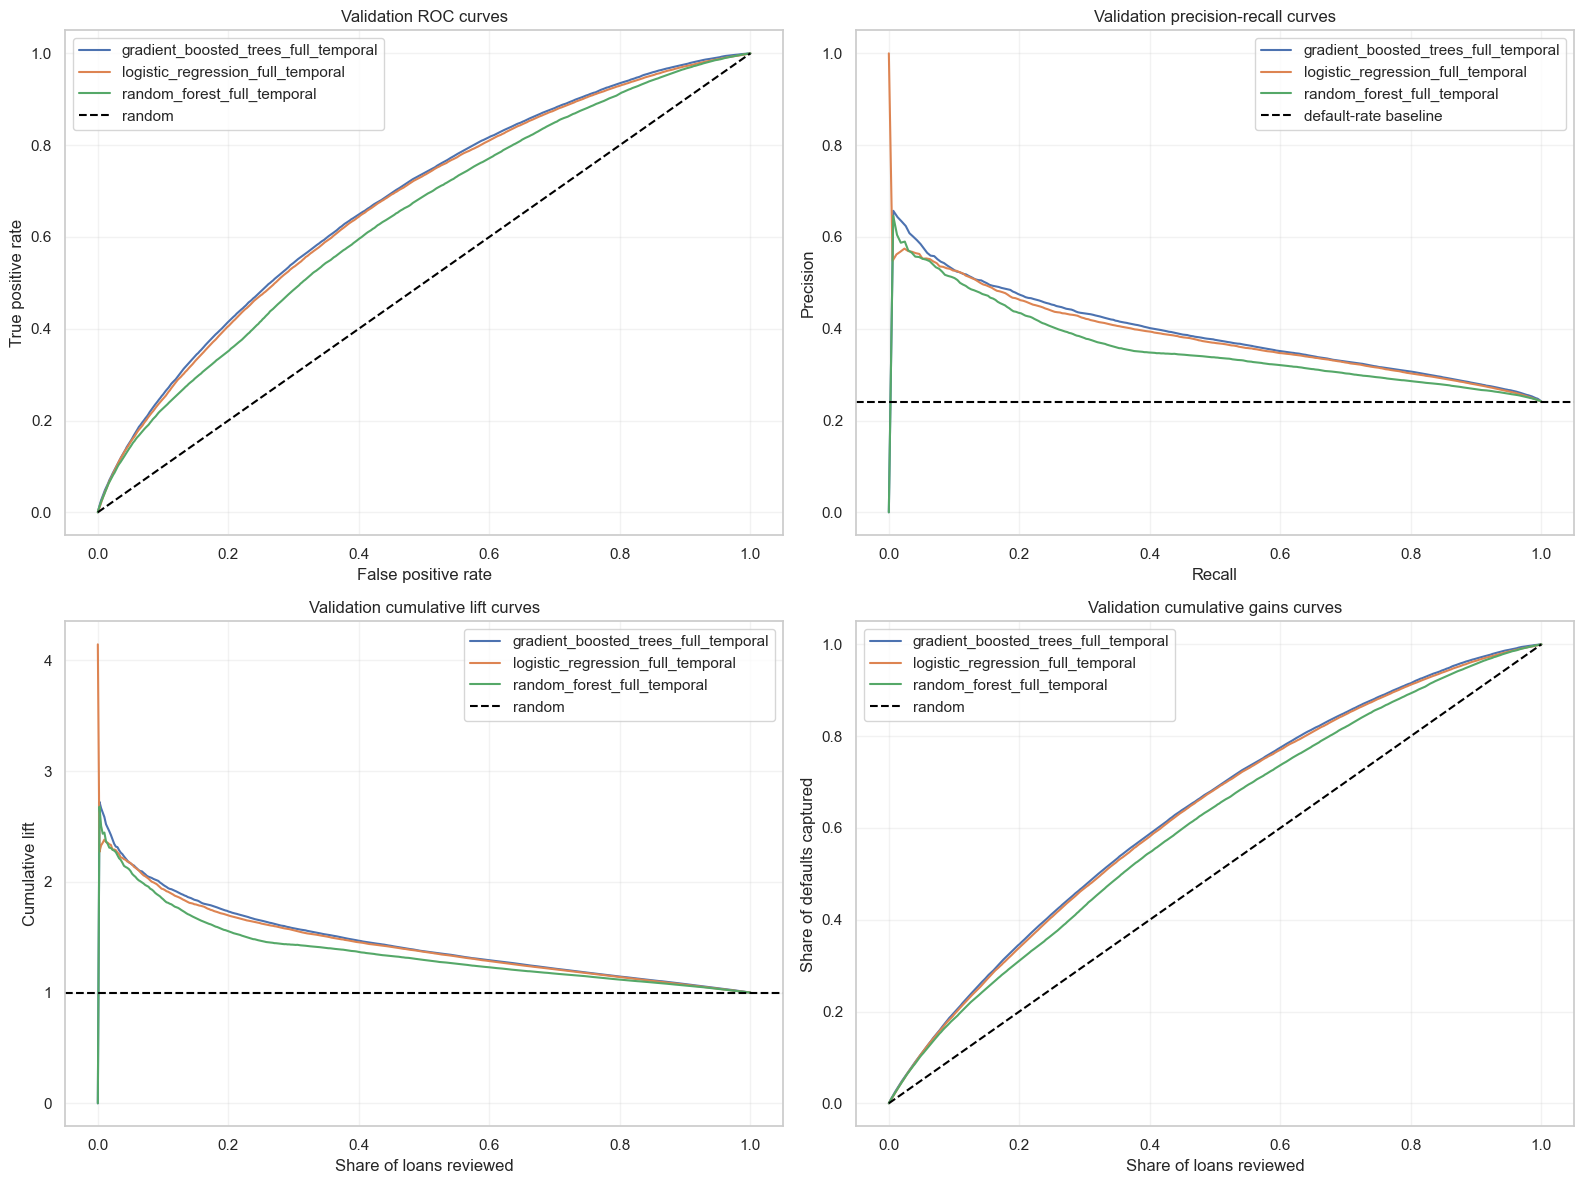

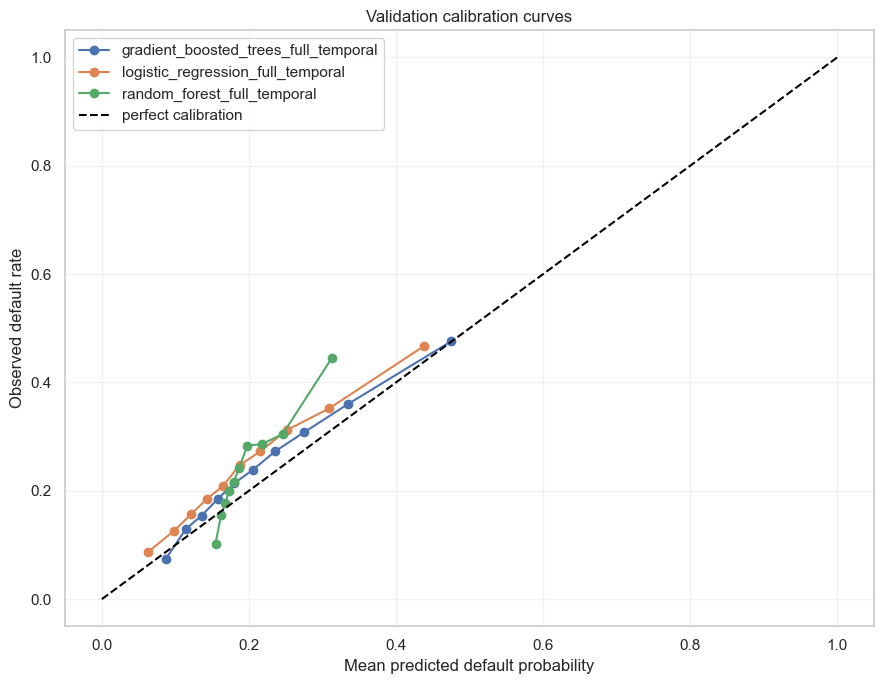

In [96]:
validation_default_rate = full_validation_metrics['default_rate'].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for model_name, model_curve in full_validation_curves.groupby('model_name'):
    axes[0, 0].plot(model_curve['fpr'], model_curve['tpr'], label=model_name)
    axes[0, 1].plot(model_curve['recall'], model_curve['precision'], label=model_name)
    axes[1, 0].plot(
        model_curve['reviewed_share'],
        model_curve['cumulative_lift'],
        label=model_name,
    )
    axes[1, 1].plot(
        model_curve['reviewed_share'],
        model_curve['cumulative_gain'],
        label=model_name,
    )

axes[0, 0].plot([0, 1], [0, 1], linestyle='--', color='black', label='random')
axes[0, 0].set_title('Validation ROC curves')
axes[0, 0].set_xlabel('False positive rate')
axes[0, 0].set_ylabel('True positive rate')

axes[0, 1].axhline(
    validation_default_rate,
    linestyle='--',
    color='black',
    label='default-rate baseline',
)
axes[0, 1].set_title('Validation precision-recall curves')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')

axes[1, 0].axhline(1.0, linestyle='--', color='black', label='random')
axes[1, 0].set_title('Validation cumulative lift curves')
axes[1, 0].set_xlabel('Share of loans reviewed')
axes[1, 0].set_ylabel('Cumulative lift')

axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='black', label='random')
axes[1, 1].set_title('Validation cumulative gains curves')
axes[1, 1].set_xlabel('Share of loans reviewed')
axes[1, 1].set_ylabel('Share of defaults captured')

for axis in axes.flat:
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
for model_name, model_calibration in full_validation_calibration.groupby('model_name'):
    plt.plot(
        model_calibration['mean_predicted_probability'],
        model_calibration['observed_default_rate'],
        marker='o',
        label=model_name,
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='perfect calibration')
plt.title('Validation calibration curves')
plt.xlabel('Mean predicted default probability')
plt.ylabel('Observed default rate')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## Step 17: Tune GBT And Select A Working Threshold On Validation

Hyperparameters are selected using validation performance only. After selecting the best GBT configuration, a working rejection/review threshold is also selected on validation. The default working policy below targets the highest-risk 10% of validation loans; change `WORKING_REJECTION_SHARE` when business review capacity or risk appetite is known.

The threshold table is a policy menu rather than a claim that one rejection rate is automatically optimal. A final economic threshold also requires expected revenue, exposure at default, loss given default, and operational review costs.


In [ ]:
full_data_gbt_tuning_specs = [
    {
        'tuning_profile': 'shallow_regularized',
        'maxDepth': 3,
        'maxIter': 100,
        'stepSize': 0.04,
        'minInstancesPerNode': 400,
        'subsamplingRate': 0.8,
    },
    {
        'tuning_profile': 'balanced_regularized',
        'maxDepth': 4,
        'maxIter': 100,
        'stepSize': 0.04,
        'minInstancesPerNode': 300,
        'subsamplingRate': 0.8,
    },
    {
        'tuning_profile': 'deeper_subsampled',
        'maxDepth': 5,
        'maxIter': 100,
        'stepSize': 0.04,
        'minInstancesPerNode': 300,
        'subsamplingRate': 0.7,
    },
    {
        'tuning_profile': 'deeper_slow',
        'maxDepth': 5,
        'maxIter': 140,
        'stepSize': 0.025,
        'minInstancesPerNode': 400,
        'subsamplingRate': 0.8,
    },
]


def full_data_gbt_estimator(spec):
    return GBTClassifier(
        featuresCol='features',
        labelCol='default_flag',
        maxDepth=int(spec['maxDepth']),
        maxIter=int(spec['maxIter']),
        stepSize=float(spec['stepSize']),
        minInstancesPerNode=int(spec['minInstancesPerNode']),
        subsamplingRate=float(spec['subsamplingRate']),
        seed=42,
    )


full_data_gbt_tuning_rows = []

for spec in full_data_gbt_tuning_specs:
    model_name = f"gbt_full_tuning_{spec['tuning_profile']}"
    print(f'Training validation tuning candidate: {model_name}')
    pipeline = build_full_data_pipeline(
        full_data_gbt_estimator(spec),
        training_selected_numeric_features,
        full_profiled_categorical_features,
    )
    fitted_model = pipeline.fit(full_model_train)
    validation_predictions = fitted_model.transform(full_model_validation)
    evaluation = full_data_metrics_from_predictions(
        validation_predictions,
        model_name,
        'validation',
    )
    full_data_gbt_tuning_rows.append({
        **evaluation['metrics'],
        **spec,
    })

full_data_gbt_tuning_metrics = (
    pd.DataFrame(full_data_gbt_tuning_rows)
    .sort_values(
        ['roc_auc', 'pr_auc', 'top_decile_lift', 'brier_score'],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

best_full_data_gbt_profile = full_data_gbt_tuning_metrics.iloc[0]['tuning_profile']
best_full_data_gbt_spec = next(
    spec for spec in full_data_gbt_tuning_specs
    if spec['tuning_profile'] == best_full_data_gbt_profile
)

display(full_data_gbt_tuning_metrics)
print(f'Selected GBT validation profile: {best_full_data_gbt_profile}')

selected_validation_pipeline = build_full_data_pipeline(
    full_data_gbt_estimator(best_full_data_gbt_spec),
    training_selected_numeric_features,
    full_profiled_categorical_features,
)
selected_validation_model = selected_validation_pipeline.fit(full_model_train)
selected_validation_predictions = selected_validation_model.transform(full_model_validation)
selected_validation_evaluation = full_data_metrics_from_predictions(
    selected_validation_predictions,
    'selected_tuned_gbt_validation',
    'validation',
)


def threshold_policy_table(scored_pd, review_shares):
    ranked = scored_pd.sort_values(
        'default_probability',
        ascending=False,
    ).reset_index(drop=True)
    total_defaults = ranked['default_flag'].sum()
    policy_rows = []

    for target_review_share in review_shares:
        cutoff_index = min(
            len(ranked) - 1,
            max(0, int(np.ceil(len(ranked) * target_review_share)) - 1),
        )
        threshold = ranked.loc[cutoff_index, 'default_probability']
        flagged = ranked['default_probability'].ge(threshold)
        flagged_defaults = ranked.loc[flagged, 'default_flag'].sum()
        approved_defaults = ranked.loc[~flagged, 'default_flag'].sum()

        policy_rows.append({
            'target_review_share': target_review_share,
            'threshold': threshold,
            'actual_review_share': flagged.mean(),
            'approval_share': (~flagged).mean(),
            'flagged_default_rate': ranked.loc[flagged, 'default_flag'].mean(),
            'approved_default_rate': ranked.loc[~flagged, 'default_flag'].mean(),
            'defaults_captured': flagged_defaults / total_defaults,
            'defaults_remaining_approved': approved_defaults,
        })

    return pd.DataFrame(policy_rows)


validation_threshold_policy = threshold_policy_table(
    selected_validation_evaluation['scores'],
    review_shares=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50],
)

WORKING_REJECTION_SHARE = 0.10
working_policy_row = validation_threshold_policy.iloc[
    (validation_threshold_policy['target_review_share'] - WORKING_REJECTION_SHARE)
    .abs()
    .argsort()[:1]
].iloc[0]
selected_business_threshold = float(working_policy_row['threshold'])

display(validation_threshold_policy)
print(f'Working rejection/review share: {WORKING_REJECTION_SHARE:.0%}')
print(f'Validation-selected probability threshold: {selected_business_threshold:.6f}')


Training validation tuning candidate: gbt_full_tuning_shallow_regularized


## Step 18: Final Untouched Test Evaluation

After model configuration and the working threshold have been selected, the final GBT is retrained using the combined training and validation periods. It is then evaluated on the untouched newest-period test split.

The threshold reported on test is the exact probability cutoff chosen from validation. It is not adjusted after seeing test results.


In [ ]:
full_model_train_validation = (
    full_model_train
    .unionByName(full_model_validation)
    .cache()
)

final_full_data_pipeline = build_full_data_pipeline(
    full_data_gbt_estimator(best_full_data_gbt_spec),
    training_selected_numeric_features,
    full_profiled_categorical_features,
)
final_full_data_model = final_full_data_pipeline.fit(full_model_train_validation)
final_test_predictions = final_full_data_model.transform(full_model_test)
final_test_evaluation = full_data_metrics_from_predictions(
    final_test_predictions,
    'tuned_gbt_full_temporal',
    'test',
)

final_test_metrics = pd.DataFrame([final_test_evaluation['metrics']])


def fixed_threshold_metrics(scored_pd, threshold):
    predicted_default = scored_pd['default_probability'].ge(threshold)
    actual_default = scored_pd['default_flag'].eq(1)
    true_positive = (predicted_default & actual_default).sum()
    false_positive = (predicted_default & ~actual_default).sum()
    false_negative = (~predicted_default & actual_default).sum()
    true_negative = (~predicted_default & ~actual_default).sum()

    return pd.DataFrame([{
        'threshold': threshold,
        'review_or_rejection_share': predicted_default.mean(),
        'approval_share': (~predicted_default).mean(),
        'precision_flagged_default_rate': safe_divide(
            true_positive,
            true_positive + false_positive,
        ),
        'recall_defaults_captured': safe_divide(
            true_positive,
            true_positive + false_negative,
        ),
        'approved_default_rate': scored_pd.loc[
            ~predicted_default,
            'default_flag',
        ].mean(),
        'true_positive': true_positive,
        'false_positive': false_positive,
        'false_negative': false_negative,
        'true_negative': true_negative,
    }])


final_test_threshold_metrics = fixed_threshold_metrics(
    final_test_evaluation['scores'],
    selected_business_threshold,
)

display(final_test_metrics)
display(final_test_threshold_metrics)

final_curve = final_test_evaluation['curve']
final_calibration = final_test_evaluation['calibration']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(final_curve['fpr'], final_curve['tpr'], label='tuned GBT test')
axes[0, 0].plot([0, 1], [0, 1], linestyle='--', color='black', label='random')
axes[0, 0].set_title('Final test ROC curve')
axes[0, 0].set_xlabel('False positive rate')
axes[0, 0].set_ylabel('True positive rate')

axes[0, 1].plot(final_curve['recall'], final_curve['precision'], label='tuned GBT test')
axes[0, 1].axhline(
    final_test_metrics['default_rate'].iloc[0],
    linestyle='--',
    color='black',
    label='default-rate baseline',
)
axes[0, 1].set_title('Final test precision-recall curve')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')

axes[1, 0].plot(
    final_curve['reviewed_share'],
    final_curve['cumulative_lift'],
    label='tuned GBT test',
)
axes[1, 0].axhline(1.0, linestyle='--', color='black', label='random')
axes[1, 0].set_title('Final test cumulative lift curve')
axes[1, 0].set_xlabel('Share of loans reviewed')
axes[1, 0].set_ylabel('Cumulative lift')

axes[1, 1].plot(
    final_curve['reviewed_share'],
    final_curve['cumulative_gain'],
    label='tuned GBT test',
)
axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='black', label='random')
axes[1, 1].set_title('Final test cumulative gains curve')
axes[1, 1].set_xlabel('Share of loans reviewed')
axes[1, 1].set_ylabel('Share of defaults captured')

for axis in axes.flat:
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
plt.plot(
    final_calibration['mean_predicted_probability'],
    final_calibration['observed_default_rate'],
    marker='o',
    label='tuned GBT test',
)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='perfect calibration')
plt.title('Final test calibration curve')
plt.xlabel('Mean predicted default probability')
plt.ylabel('Observed default rate')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


### Full-Data Decision Notes

Use the validation comparison plots to judge architecture differences. Use the final test metrics only for the selected tuned GBT and report them as the out-of-time estimate.

Before deployment:

1. Define a fixed outcome-performance window so newer resolved loans do not create maturity bias.
2. Add revenue, exposure at default, loss given default, and review-cost assumptions to the threshold table.
3. Check performance and calibration by borrower segment.
4. Save the fitted pipeline and build a repeatable scoring contract.
5. Monitor population drift, score drift, realized default rate, and calibration after deployment.


In [50]:
spark.stop()